# Nghiên cứu và so sánh các thuật toán Học máy trong dự đoán nguy cơ bệnh tim mạch


## 1. Setup, seed, config tập trung

In [1]:
# === Imports ===
import os
import json
import time
import warnings
import platform
import hashlib
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import logit, expit
from scipy.stats import binom

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    f1_score, fbeta_score, log_loss, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, learning_curve,
)

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import joblib

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

# Suppress 2 warning vô hại + noisy:
# 1. datetime.utcnow() deprecation từ jupyter_client internals (không từ code notebook)
# 2. "X does not have valid feature names" từ sklearn khi pipeline output ndarray
#    nhưng model như LightGBM/XGBoost được fit qua DataFrame schema.
warnings.filterwarnings("default")
warnings.filterwarnings(
    "ignore", category=UserWarning,
    message=".*does not have valid feature names.*",
)
warnings.filterwarnings(
    "ignore", category=DeprecationWarning,
    message=".*datetime.datetime.utcnow.*",
)

In [2]:
# === Seed + global timer ===
SEED = 42
np.random.seed(SEED)

NOTEBOOK_T0 = time.time()  # log tổng runtime ở phần cuối

# Bản Kaggle cải tiến: chạy lâu hơn để tìm hyperparameter kỹ hơn.
# Có thể override khi demo bảo vệ:
#   RUN_MODE=fast         -> chạy nhanh
#   RUN_MODE=final        -> bản nghiên cứu đầy đủ
#   RUN_MODE=kaggle_long  -> tìm kiếm/tái lập dài hơn
#   RUN_MODE=research_max -> ngân sách lớn nhất: research search + ensemble + early stopping
RUN_MODE = os.getenv("RUN_MODE", "final").strip().lower()
MODE_ALIASES = {
    "defense_fast": "fast",
    "presentation": "fast",
    "demo": "fast",
    "long": "kaggle_long",
    "research": "research_max",
    "researchmax": "research_max",
    "max": "research_max",
}
RUN_MODE = MODE_ALIASES.get(RUN_MODE, RUN_MODE)
VALID_RUN_MODES = {"debug", "fast", "final", "kaggle_long", "research_max"}
if RUN_MODE not in VALID_RUN_MODES:
    raise ValueError(f"RUN_MODE={RUN_MODE!r} không hợp lệ. Chọn một trong {sorted(VALID_RUN_MODES)}.")


CONFIG = {
    "target_col": "cardio",
    "id_col": "id",
    "random_state": SEED,

    # Split protocol
    "test_n_splits": 7,           # 1/7 ~ 14% test
    "val_pool_n_splits": 4,       # tách val pool khỏi non-test
    "use_fast_group_holdout": True,  # nhanh hơn SGKF holdout khi feature_signature gần-unique
    "debug_sample_rows": 12000,      # chỉ dùng trong RUN_MODE=debug
    "hard_require_group_split": True,
    "split_protocol": "5way_group_aware_train_val_cal_select_threshold_test",

    # Defense guardrails
    "forbid_test_set_model_selection": True,
    "pre_register_final_selection_rule": True,
    "primary_selection_metric": "selection_score_default_weights",
    "test_set_policy": "locked_final_reporting_only",

    # Clinical plausibility ranges
    "height_range_cm": (130.0, 220.0),
    "weight_range_kg": (30.0, 180.0),
    "ap_hi_range":     (80.0, 250.0),
    "ap_lo_range":     (40.0, 180.0),
    "bmi_range":       (10.0, 80.0),

    # Per-mode runtime knobs
    # final được chỉnh để đúng mô tả: 5-fold CV + nested CV 5x3
    "cv_folds":            {"debug": 3, "fast": 3, "final": 5, "kaggle_long": 7, "research_max": 10},
    "search_iter":         {"debug": 3, "fast": 8, "final": 25, "kaggle_long": 80, "research_max": 160},
    "max_tuned_models":    {"debug": 2, "fast": 3, "final": 5, "kaggle_long": 7, "research_max": 7},
    "bootstrap_rounds":    {"debug": 80, "fast": 150, "final": 600, "kaggle_long": 1200, "research_max": 2000},

    # Nested CV
    "nested_outer_folds":  {"debug": 2, "fast": 3, "final": 5, "kaggle_long": 5, "research_max": 5},
    "nested_inner_folds":  {"debug": 2, "fast": 3, "final": 3, "kaggle_long": 3, "research_max": 5},
    "nested_search_iter":  {"debug": 2, "fast": 5, "final": 10, "kaggle_long": 20, "research_max": 35},
    "max_nested_models":   {"debug": 1, "fast": 2, "final": 5, "kaggle_long": 5, "research_max": 5},

    # Model-size knobs
    "tree_n_estimators":     {"debug": 180, "fast": 300, "final": 350, "kaggle_long": 700, "research_max": 1200},
    "boosting_n_estimators": {"debug": 250, "fast": 350, "final": 450, "kaggle_long": 900, "research_max": 1800},
    "svm_max_iter":          {"debug": 5000, "fast": 8000, "final": 10000, "kaggle_long": 20000, "research_max": 30000},
    "logreg_max_iter":       {"debug": 2000, "fast": 3000, "final": 4000, "kaggle_long": 8000, "research_max": 12000},

    # Research-max additions
    "ensemble_top_k":        {"debug": 2, "fast": 3, "final": 3, "kaggle_long": 5, "research_max": 7},
    "enable_ensemble_top_models": True,
    "use_train_only_early_stopping": True,
    "early_stopping_rounds": {"debug": 20, "fast": 40, "final": 60, "kaggle_long": 100, "research_max": 150},
    "early_stopping_holdout_frac": 0.15,

    # Threshold tuning
    "specificity_floor": 0.60,
    "f_beta": 2.0,

    # Explainability
    "max_shap_samples": 1000,
    "max_permutation_samples": 2500,
    "n_shap_dependence": 6,
    "interaction_scatter_sample": 5000,
    "require_shap_for_final": False,

    # Search
    "random_search_scoring": "average_precision",
    "random_search_n_jobs": 1,

    # Robustness studies
    "run_nested_cv": True,
    "run_ablation_study": True,
    "run_multi_seed_robustness": True,
    "multi_seed_values": [42, 2024, 2026],
    "run_cleaning_sensitivity": True,
    "run_cost_sensitive_threshold": True,
    "cost_fn_to_fp_ratio": 5.0,

    # Selection score weight robustness
    "selection_weight_scenarios": [
        {"name": "default",     "auc": 0.45, "pr": 0.35, "brier": 0.20, "ece": 0.05},
        {"name": "auc_heavy",   "auc": 0.55, "pr": 0.30, "brier": 0.10, "ece": 0.05},
        {"name": "pr_heavy",    "auc": 0.30, "pr": 0.50, "brier": 0.15, "ece": 0.05},
        {"name": "calib_heavy", "auc": 0.30, "pr": 0.30, "brier": 0.30, "ece": 0.10},
        {"name": "balanced",    "auc": 0.40, "pr": 0.40, "brier": 0.15, "ece": 0.05},
    ],

    # Cleaning sensitivity scenarios
    "cleaning_sensitivity_scenarios": [
        {"scenario": "current",  "height": (130.0, 220.0), "weight": (30.0, 180.0),
         "ap_hi": (80.0, 250.0), "ap_lo": (40.0, 180.0), "bmi": (10.0, 80.0)},
        {"scenario": "loose",    "height": (120.0, 230.0), "weight": (25.0, 200.0),
         "ap_hi": (70.0, 260.0), "ap_lo": (35.0, 190.0), "bmi": (8.0, 90.0)},
        {"scenario": "strict",   "height": (140.0, 210.0), "weight": (35.0, 160.0),
         "ap_hi": (90.0, 220.0), "ap_lo": (50.0, 140.0), "bmi": (12.0, 65.0)},
    ],
}


# Official data dictionary mapping.
# Cardiovascular Disease Dataset/Sulianova: gender 1 = women, 2 = men.
# Cell audit bên dưới chỉ dùng chiều cao để sanity-check, KHÔNG đảo nhãn.
GENDER_LABELS = {1: "women", 2: "men"}
GENDER_LABELS_VI = {1: "nữ", 2: "nam"}
GENDER_DICTIONARY_NOTE = "Official mapping: gender 1 = women, 2 = men."

# Ý nghĩa mã ordinal theo data dictionary của dataset Sulianova/Kaggle.
# Model vẫn dùng cột số 1/2/3 để giữ thứ tự ordinal; phần EDA/report dùng label này cho dễ đọc.
ORDINAL_MEDICAL_LEVELS = {
    "cholesterol": {
        1: "1 = bình thường",
        2: "2 = cao hơn bình thường",
        3: "3 = rất cao",
    },
    "gluc": {
        1: "1 = bình thường",
        2: "2 = cao hơn bình thường",
        3: "3 = rất cao",
    },
}
ORDINAL_MEDICAL_DISPLAY_NAME = {
    "cholesterol": "Cholesterol",
    "gluc": "Glucose",
}

# Nguồn gốc của mã 1/2/3:
# - Đây là mã ordinal đã có sẵn trong data dictionary của Cardiovascular Disease dataset.
# - Dataset KHÔNG cung cấp giá trị xét nghiệm gốc theo mg/dL cho từng bệnh nhân.
# - Vì vậy, ngưỡng mg/dL bên dưới chỉ là ngưỡng tham khảo y khoa để giải thích,
#   không phải giá trị đo trực tiếp của từng dòng dữ liệu.
ORDINAL_LEVEL_SOURCE_NOTE = (
    "Dataset mã hoá sẵn cholesterol/gluc dạng ordinal: "
    "1=normal, 2=above normal, 3=well above normal; "
    "không có số xét nghiệm gốc theo mg/dL."
)

CLINICAL_CUTOFF_REFERENCE = {
    "cholesterol": {
        1: {
            "clinical_variable": "Total cholesterol",
            "clinical_cutoff_reference": "< 200 mg/dL",
            "clinical_interpretation_vi": "bình thường / mong muốn",
            "reference_source": "UCSF Health total cholesterol; American Heart Association cholesterol guidance",
        },
        2: {
            "clinical_variable": "Total cholesterol",
            "clinical_cutoff_reference": "200–239 mg/dL",
            "clinical_interpretation_vi": "cao hơn bình thường / borderline high",
            "reference_source": "UCSF Health total cholesterol; American Heart Association cholesterol guidance",
        },
        3: {
            "clinical_variable": "Total cholesterol",
            "clinical_cutoff_reference": "≥ 240 mg/dL",
            "clinical_interpretation_vi": "cao / rất cao",
            "reference_source": "UCSF Health total cholesterol; American Heart Association cholesterol guidance",
        },
    },
    "gluc": {
        1: {
            "clinical_variable": "Fasting blood glucose",
            "clinical_cutoff_reference": "≤ 99 mg/dL",
            "clinical_interpretation_vi": "bình thường",
            "reference_source": "CDC Diabetes Testing - fasting blood sugar test",
        },
        2: {
            "clinical_variable": "Fasting blood glucose",
            "clinical_cutoff_reference": "100–125 mg/dL",
            "clinical_interpretation_vi": "cao hơn bình thường / tiền đái tháo đường",
            "reference_source": "CDC Diabetes Testing - fasting blood sugar test",
        },
        3: {
            "clinical_variable": "Fasting blood glucose",
            "clinical_cutoff_reference": "≥ 126 mg/dL",
            "clinical_interpretation_vi": "rất cao / ngưỡng đái tháo đường",
            "reference_source": "CDC Diabetes Testing - fasting blood sugar test",
        },
    },
}


def clinical_cutoff_label(feature: str, value) -> str:
    """Trả về ngưỡng y khoa tham khảo cho level 1/2/3; fallback an toàn cho missing/invalid."""
    if feature not in CLINICAL_CUTOFF_REFERENCE:
        return ""
    if pd.isna(value):
        return "missing"
    try:
        value_int = int(value)
    except Exception:
        return f"invalid: {value}"
    info = CLINICAL_CUTOFF_REFERENCE[feature].get(value_int)
    if info is None:
        return f"invalid: {value_int}"
    return info["clinical_cutoff_reference"]


def medical_level_label(feature: str, value) -> str:
    """Trả về label rõ nghĩa cho cholesterol/gluc; giữ fallback an toàn cho missing/invalid."""
    if feature not in ORDINAL_MEDICAL_LEVELS:
        return str(value)
    if pd.isna(value):
        return "missing"
    try:
        value_int = int(value)
    except Exception:
        return f"invalid: {value}"
    return ORDINAL_MEDICAL_LEVELS[feature].get(value_int, f"invalid: {value_int}")


def add_medical_level_labels(df: pd.DataFrame, columns=("cholesterol", "gluc")) -> pd.DataFrame:
    """Thêm cột *_level_label để bảng/biểu đồ thể hiện rõ 1/2/3 là gì."""
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[f"{col}_level_label"] = out[col].map(lambda v: medical_level_label(col, v))
    return out


def cfg_for_mode(key):
    return CONFIG[key][RUN_MODE]


CV_FOLDS              = cfg_for_mode("cv_folds")
N_RANDOM_SEARCH_ITER  = cfg_for_mode("search_iter")
MAX_TUNED_MODELS      = cfg_for_mode("max_tuned_models")
N_BOOTSTRAP           = cfg_for_mode("bootstrap_rounds")
NESTED_OUTER_FOLDS    = cfg_for_mode("nested_outer_folds")
NESTED_INNER_FOLDS    = cfg_for_mode("nested_inner_folds")
NESTED_N_SEARCH_ITER  = cfg_for_mode("nested_search_iter")
MAX_NESTED_MODELS     = cfg_for_mode("max_nested_models")
TREE_N_ESTIMATORS     = cfg_for_mode("tree_n_estimators")
BOOSTING_N_ESTIMATORS = cfg_for_mode("boosting_n_estimators")
SVM_MAX_ITER          = cfg_for_mode("svm_max_iter")
LOGREG_MAX_ITER       = cfg_for_mode("logreg_max_iter")
ENSEMBLE_TOP_K        = cfg_for_mode("ensemble_top_k")
EARLY_STOPPING_ROUNDS = cfg_for_mode("early_stopping_rounds")
EARLY_STOPPING_HOLDOUT_FRAC = CONFIG["early_stopping_holdout_frac"]

# Giới hạn song song trong debug/local để tránh spawn quá nhiều process.
N_JOBS = 1 if RUN_MODE == "debug" else -1

# Debug mode chỉ để smoke-test nhanh; final/kaggle_long vẫn chạy đầy đủ.
if RUN_MODE == "debug":
    CONFIG["run_nested_cv"] = False
    CONFIG["run_ablation_study"] = False
    CONFIG["run_multi_seed_robustness"] = False
    CONFIG["run_cleaning_sensitivity"] = False
    CONFIG["max_shap_samples"] = min(CONFIG["max_shap_samples"], 250)
    CONFIG["max_permutation_samples"] = min(CONFIG["max_permutation_samples"], 600)
    CONFIG["n_shap_dependence"] = min(CONFIG["n_shap_dependence"], 3)


print("RUN_MODE:", RUN_MODE)
print("CV_FOLDS:", CV_FOLDS,
      "| SEARCH_ITER:", N_RANDOM_SEARCH_ITER,
      "| MAX_TUNED:", MAX_TUNED_MODELS,
      "| BOOTSTRAP:", N_BOOTSTRAP,
      "| TREE_N:", TREE_N_ESTIMATORS,
      "| BOOSTING_N:", BOOSTING_N_ESTIMATORS,
      "| ENSEMBLE_TOP_K:", ENSEMBLE_TOP_K,
      "| EARLY_STOP:", EARLY_STOPPING_ROUNDS)
print("Cholesterol/Glucose levels:", ORDINAL_MEDICAL_LEVELS)


RUN_MODE: final
CV_FOLDS: 5 | SEARCH_ITER: 25 | MAX_TUNED: 5 | BOOTSTRAP: 600 | TREE_N: 350 | BOOSTING_N: 450 | ENSEMBLE_TOP_K: 3 | EARLY_STOP: 60
Cholesterol/Glucose levels: {'cholesterol': {1: '1 = bình thường', 2: '2 = cao hơn bình thường', 3: '3 = rất cao'}, 'gluc': {1: '1 = bình thường', 2: '2 = cao hơn bình thường', 3: '3 = rất cao'}}


In [3]:
# === Data path with fallback chain ===
DATA_CANDIDATES = [
    Path("/kaggle/input/cardiovascular-disease-dataset/cardio_train.csv"),
    Path("/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv"),
    Path("/mnt/user-data/uploads/cardio_train.csv"),
    Path("/mnt/data/cardio_train.csv"),
    Path("cardio_train.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy cardio_train.csv. "
        "Đường dẫn đã thử: " + " | ".join(str(p) for p in DATA_CANDIDATES)
    )

# === Artifact directories ===
if Path("/kaggle/working").exists():
    ARTIFACT_DIR = Path("/kaggle/working/cardio_artifacts")
else:
    ARTIFACT_DIR = Path("./cardio_artifacts")

FIG_DIR   = ARTIFACT_DIR / "figures"
TABLE_DIR = ARTIFACT_DIR / "tables"
MODEL_DIR = ARTIFACT_DIR / "models"
for d in [ARTIFACT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

DATA_PATH: /kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv
ARTIFACT_DIR: /kaggle/working/cardio_artifacts


In [4]:
# === Helpers: IO + library versions ===
def save_json(obj: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)


def save_df(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index, encoding="utf-8-sig")




def stable_json_sha256(obj: Any) -> str:
    """Hash ổn định cho audit pre-test: dùng để chứng minh selection protocol đã khóa."""
    payload = json.dumps(obj, ensure_ascii=False, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def stable_dataframe_sha256(df: pd.DataFrame) -> str:
    """Hash bảng theo nội dung, không phụ thuộc index hiện tại."""
    safe_df = df.copy()
    safe_df = safe_df.reindex(sorted(safe_df.columns), axis=1)
    payload = safe_df.to_csv(index=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

def make_ohe():
    """OneHotEncoder tương thích nhiều phiên bản sklearn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def sigmoid_clip(p, eps=1e-6):
    return np.clip(np.asarray(p, dtype=float), eps, 1 - eps)



def _to_builtin_clone_param(value):
    """Convert numpy scalar params to Python builtins and recursively sanitize estimators.

    Một số estimator ngoài sklearn (đặc biệt CatBoost sau RandomizedSearchCV)
    có thể giữ hyperparameter dưới dạng np.float64/np.int64. sklearn.clone()
    kiểm tra identity của parameter và sẽ crash với lỗi "constructor modifies
    parameter ...". Helper này chuyển tham số về Python scalar để các study
    robustness/ablation có thể clone model ổn định.
    """
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {k: _to_builtin_clone_param(v) for k, v in value.items()}
    if isinstance(value, list):
        return [_to_builtin_clone_param(v) for v in value]
    if isinstance(value, tuple):
        return tuple(_to_builtin_clone_param(v) for v in value)
    if hasattr(value, "get_params") and hasattr(value, "set_params"):
        return safe_clone_estimator(value)
    return value


def safe_clone_estimator(estimator_obj):
    """sklearn.clone() + fallback sửa numpy scalar params cho CatBoost/XGBoost/LightGBM.

    Trả về estimator chưa fit, clone-compatible. Dùng thay clone(...) ở các
    pipeline phụ như learning curve, ablation, cleaning sensitivity, multi-seed.
    """
    try:
        return clone(estimator_obj)
    except RuntimeError as err:
        msg = str(err)
        clone_param_error = (
            "Cannot clone object" in msg
            or "constructor either does not set or modifies parameter" in msg
        )
        if not clone_param_error or not hasattr(estimator_obj, "get_params"):
            raise

        params = estimator_obj.get_params(deep=False)
        safe_params = {k: _to_builtin_clone_param(v) for k, v in params.items()}
        rebuilt = estimator_obj.__class__(**safe_params)

        # Verify ngay để lỗi thật không bị che khuất.
        return clone(rebuilt)

def get_library_versions() -> Dict[str, Any]:
    versions = {
        "created_at": datetime.now().isoformat(),
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
    }
    for lib in ["sklearn", "scipy", "joblib", "matplotlib",
                "xgboost", "lightgbm", "catboost", "shap"]:
        try:
            module = __import__(lib)
            versions[lib] = getattr(module, "__version__", "unknown")
        except Exception as e:
            versions[lib] = f"NOT_AVAILABLE: {type(e).__name__}"
    return versions


env_info = get_library_versions()
save_json(env_info, ARTIFACT_DIR / "library_versions.json")

run_config = {
    "created_at": datetime.now().isoformat(),
    "seed": SEED,
    "run_mode": RUN_MODE,
    "data_path": str(DATA_PATH),
    "artifact_dir": str(ARTIFACT_DIR),
    "config": CONFIG,
    "derived": {
        "cv_folds": CV_FOLDS,
        "search_iter": N_RANDOM_SEARCH_ITER,
        "max_tuned_models": MAX_TUNED_MODELS,
        "n_bootstrap": N_BOOTSTRAP,
        "nested_outer_folds": NESTED_OUTER_FOLDS,
        "nested_inner_folds": NESTED_INNER_FOLDS,
        "tree_n_estimators": TREE_N_ESTIMATORS,
        "boosting_n_estimators": BOOSTING_N_ESTIMATORS,
        "svm_max_iter": SVM_MAX_ITER,
        "logreg_max_iter": LOGREG_MAX_ITER,
        "ensemble_top_k": ENSEMBLE_TOP_K,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "early_stopping_holdout_frac": EARLY_STOPPING_HOLDOUT_FRAC,
        "n_jobs": N_JOBS,
    },
    "leakage_guardrails": [
        "Split before any preprocessing/feature engineering fit.",
        "All preprocessing and FE are inside sklearn Pipeline.",
        "Calibration, model selection, threshold tuning, and final test use separate splits.",
        "Test set is locked and is never used for model/threshold/calibrator selection.",
        "Group-aware split by feature_signature prevents duplicate-row leakage.",
    ],
}
save_json(run_config, ARTIFACT_DIR / "run_config.json")
print(json.dumps({k: env_info[k] for k in
                  ["python", "numpy", "pandas", "sklearn", "scipy", "shap",
                   "xgboost", "lightgbm", "catboost"]
                  if k in env_info}, indent=2, ensure_ascii=False))


{
  "python": "3.12.12",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "scipy": "1.16.3",
  "shap": "0.50.0",
  "xgboost": "3.2.0",
  "lightgbm": "4.6.0",
  "catboost": "1.2.10"
}


## 2. Load dữ liệu + kiểm tra schema, dtype, domain



In [5]:
def read_cardio_csv(path: Path) -> pd.DataFrame:
    df_try = pd.read_csv(path, sep=";")
    if df_try.shape[1] == 1:
        raise ValueError("Sulianova phải đọc bằng separator=';'.")
    return df_try


EXPECTED_COLUMNS = [
    "id", "age", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active", "cardio",
]

DOMAIN_RULES = {
    "gender": {1, 2},
    "cholesterol": {1, 2, 3},
    "gluc": {1, 2, 3},
    "smoke": {0, 1},
    "alco": {0, 1},
    "active": {0, 1},
    "cardio": {0, 1},
}

raw_df = read_cardio_csv(DATA_PATH)
if list(raw_df.columns) != EXPECTED_COLUMNS:
    raise ValueError(f"Sai schema. Expected={EXPECTED_COLUMNS}; got={list(raw_df.columns)}")

# dtype check: tất cả numeric; integer-like (trừ weight)
non_numeric = [c for c in EXPECTED_COLUMNS if not pd.api.types.is_numeric_dtype(raw_df[c])]
if non_numeric:
    raise TypeError(f"Cột phải là numeric: {non_numeric}")

int_like_cols = [c for c in EXPECTED_COLUMNS if c != "weight"]
bad_int = [c for c in int_like_cols if not np.allclose(raw_df[c], np.round(raw_df[c]))]
if bad_int:
    raise TypeError(f"Cột phải là integer-like: {bad_int}")

schema_report = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": [str(raw_df[c].dtype) for c in raw_df.columns],
    "n_missing": [int(raw_df[c].isna().sum()) for c in raw_df.columns],
    "missing_rate": [float(raw_df[c].isna().mean()) for c in raw_df.columns],
    "n_unique": [int(raw_df[c].nunique(dropna=False)) for c in raw_df.columns],
})
save_df(schema_report, TABLE_DIR / "01_raw_schema_report.csv")
display(raw_df.head())
display(schema_report)
print("Raw shape:", raw_df.shape, "| Schema + dtype contract: PASS")

# DEBUG MODE SAMPLE: chỉ smoke-test nhanh; RUN_MODE=final/kaggle_long dùng đủ dataset.
if RUN_MODE == "debug" and len(raw_df) > int(CONFIG.get("debug_sample_rows", 0)):
    sample_n = int(CONFIG["debug_sample_rows"])
    before_shape = tuple(raw_df.shape)
    raw_df = (
        raw_df.groupby(CONFIG["target_col"], group_keys=False)
        .sample(n=sample_n // 2, random_state=SEED)
        .sort_index()
        .reset_index(drop=True)
    )
    debug_sample_audit = {
        "status": "debug_sample_applied",
        "full_shape_before_debug_sample": before_shape,
        "debug_shape_after_sample": tuple(raw_df.shape),
        "class_balance_after_sample": raw_df[CONFIG["target_col"]].value_counts(normalize=True).to_dict(),
        "note": "Chỉ áp dụng trong RUN_MODE=debug; bản final dùng toàn bộ dataset.",
    }
    save_json(debug_sample_audit, TABLE_DIR / "00_debug_sample_audit.json")
    print("[DEBUG MODE SAMPLE]", json.dumps(debug_sample_audit, ensure_ascii=False, indent=2))

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


,column,dtype,n_missing,missing_rate,n_unique
0,id,int64,0,0.0,70000
1,age,int64,0,0.0,8076
2,gender,int64,0,0.0,2
3,height,int64,0,0.0,109
4,weight,float64,0,0.0,287
5,ap_hi,int64,0,0.0,153
6,ap_lo,int64,0,0.0,157
7,cholesterol,int64,0,0.0,3
8,gluc,int64,0,0.0,3
9,smoke,int64,0,0.0,2


Raw shape: (70000, 13) | Schema + dtype contract: PASS


In [6]:
# === Domain validation: fail-fast nếu cột nhị phân/ordinal có giá trị ngoài domain ===
domain_rows = []
for col in ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]:
    vc = raw_df[col].value_counts(dropna=False).sort_index()
    allowed = DOMAIN_RULES[col]
    for value, count in vc.items():
        domain_rows.append({
            "column": col,
            "value": value,
            "level_label": medical_level_label(col, value) if col in ORDINAL_MEDICAL_LEVELS else "",
            "clinical_cutoff_reference": clinical_cutoff_label(col, value) if col in ORDINAL_MEDICAL_LEVELS else "",
            "count": int(count),
            "ratio": float(count / len(raw_df)),
            "allowed": sorted(list(allowed)),
            "is_valid": bool(value in allowed),
        })

domain_value_report = pd.DataFrame(domain_rows)
save_df(domain_value_report, TABLE_DIR / "01_domain_value_report.csv")
display(domain_value_report)

# Bảng riêng cho 2 biến ordinal y khoa để đưa thẳng vào báo cáo.
# Cột dataset_level_label là ý nghĩa mã trong dataset; cột clinical_cutoff_reference là ngưỡng y khoa tham khảo.
ordinal_level_reference_rows = []
for feature, mapping in ORDINAL_MEDICAL_LEVELS.items():
    for code, label in mapping.items():
        clinical_info = CLINICAL_CUTOFF_REFERENCE[feature][code]
        ordinal_level_reference_rows.append({
            "feature": feature,
            "feature_display_name": ORDINAL_MEDICAL_DISPLAY_NAME.get(feature, feature),
            "level_code": code,
            "dataset_level_label": label,
            "clinical_variable": clinical_info["clinical_variable"],
            "clinical_cutoff_reference": clinical_info["clinical_cutoff_reference"],
            "clinical_interpretation_vi": clinical_info["clinical_interpretation_vi"],
            "reference_source": clinical_info["reference_source"],
            "important_note": ORDINAL_LEVEL_SOURCE_NOTE,
        })

ordinal_level_reference = pd.DataFrame(ordinal_level_reference_rows)
save_df(ordinal_level_reference, TABLE_DIR / "01_ordinal_medical_level_reference.csv")
save_df(ordinal_level_reference, TABLE_DIR / "01_cholesterol_glucose_level_cutoff_reference.csv")
display(ordinal_level_reference)

raw_audit = {
    "n_rows": int(len(raw_df)),
    "n_cols": int(raw_df.shape[1]),
    "target_distribution": raw_df[CONFIG["target_col"]].value_counts().to_dict(),
    "duplicated_full_rows": int(raw_df.duplicated().sum()),
}
save_json(raw_audit, TABLE_DIR / "01_raw_audit.json")

invalid_rows = domain_value_report[~domain_value_report["is_valid"]]
if len(invalid_rows):
    save_df(invalid_rows, TABLE_DIR / "01_domain_invalid_rows.csv")
    raise ValueError(f"Domain violation:\n{invalid_rows.to_string(index=False)}")
print("Domain contract: PASS")
print(f"Class balance: {raw_df['cardio'].value_counts(normalize=True).to_dict()}")


,column,value,level_label,clinical_cutoff_reference,count,ratio,allowed,is_valid
0,gender,1,,,45530,0.650429,"[1, 2]",True
1,gender,2,,,24470,0.349571,"[1, 2]",True
2,cholesterol,1,1 = bình thường,< 200 mg/dL,52385,0.748357,"[1, 2, 3]",True
3,cholesterol,2,2 = cao hơn bình thường,200–239 mg/dL,9549,0.136414,"[1, 2, 3]",True
4,cholesterol,3,3 = rất cao,≥ 240 mg/dL,8066,0.115229,"[1, 2, 3]",True
5,gluc,1,1 = bình thường,≤ 99 mg/dL,59479,0.849700,"[1, 2, 3]",True
6,gluc,2,2 = cao hơn bình thường,100–125 mg/dL,5190,0.074143,"[1, 2, 3]",True
7,gluc,3,3 = rất cao,≥ 126 mg/dL,5331,0.076157,"[1, 2, 3]",True
8,smoke,0,,,63831,0.911871,"[0, 1]",True
9,smoke,1,,,6169,0.088129,"[0, 1]",True


,feature,feature_display_name,level_code,dataset_level_label,clinical_variable,clinical_cutoff_reference,clinical_interpretation_vi,reference_source,important_note
0,cholesterol,Cholesterol,1,1 = bình thường,Total cholesterol,< 200 mg/dL,bình thường / mong muốn,UCSF Health total cholesterol; American Heart ...,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
1,cholesterol,Cholesterol,2,2 = cao hơn bình thường,Total cholesterol,200–239 mg/dL,cao hơn bình thường / borderline high,UCSF Health total cholesterol; American Heart ...,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
2,cholesterol,Cholesterol,3,3 = rất cao,Total cholesterol,≥ 240 mg/dL,cao / rất cao,UCSF Health total cholesterol; American Heart ...,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
3,gluc,Glucose,1,1 = bình thường,Fasting blood glucose,≤ 99 mg/dL,bình thường,CDC Diabetes Testing - fasting blood sugar test,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
4,gluc,Glucose,2,2 = cao hơn bình thường,Fasting blood glucose,100–125 mg/dL,cao hơn bình thường / tiền đái tháo đường,CDC Diabetes Testing - fasting blood sugar test,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...
5,gluc,Glucose,3,3 = rất cao,Fasting blood glucose,≥ 126 mg/dL,rất cao / ngưỡng đái tháo đường,CDC Diabetes Testing - fasting blood sugar test,Dataset mã hoá sẵn cholesterol/gluc dạng ordin...


Domain contract: PASS
Class balance: {0: 0.5003, 1: 0.4997}


## 3. Audit gender + duplicate + label conflict (KHÔNG drop bằng target trước split)

`gender` mã hóa 1/2 (không khẳng định nhãn nam/nữ — phải suy luận từ chiều cao trung vị).

`feature_signature` (chuỗi join toàn bộ feature **không gồm `id` và `cardio`**) dùng để:
1. Audit số duplicate / conflict label.
2. Làm `group` cho `StratifiedGroupKFold` → đảm bảo cùng signature không lọt vào nhiều split/fold.

**Không** xóa nhóm conflict bằng cách nhìn `cardio` trước split — đó là target-informed cleaning, sẽ tạo leakage.

In [7]:

# Official gender mapping + sanity check bằng chiều cao
# Data dictionary chính thức: gender 1 = women, gender 2 = men.
# Chiều cao chỉ dùng để sanity-check tính hợp lý của nhãn, không dùng để suy luận/đảo nhãn.
gender_height_audit = (
    raw_df.groupby("gender")["height"]
    .agg(n="size", mean="mean", median="median", std="std", min="min", max="max")
    .reset_index()
)
gender_height_audit["official_label_en"] = gender_height_audit["gender"].map(GENDER_LABELS)
gender_height_audit["official_label_vi"] = gender_height_audit["gender"].map(GENDER_LABELS_VI)
gender_height_audit = gender_height_audit[
    ["gender", "official_label_en", "official_label_vi", "n", "mean", "median", "std", "min", "max"]
]
save_df(gender_height_audit, TABLE_DIR / "02_gender_height_audit.csv")
display(gender_height_audit)

# Sanity check: nhóm được mã hoá là men kỳ vọng có median height cao hơn women.
try:
    median_by_code = gender_height_audit.set_index("gender")["median"].to_dict()
    sanity_pass = bool(median_by_code.get(2, np.nan) > median_by_code.get(1, np.nan))
except Exception:
    sanity_pass = False

gender_note = {
    "official_mapping": GENDER_LABELS,
    "official_mapping_vi": GENDER_LABELS_VI,
    "sanity_check": "median_height_gender_2_greater_than_gender_1",
    "sanity_pass": sanity_pass,
    "interpretation": (
        "Notebook dùng mapping chính thức 1=women, 2=men. "
        "Sanity check bằng chiều cao chỉ để phát hiện lỗi dữ liệu nếu có, "
        "không phải cơ sở để đảo nhãn."
    ),
}
save_json(gender_note, TABLE_DIR / "02_gender_audit_note.json")
print(json.dumps(gender_note, ensure_ascii=False, indent=2))


,gender,official_label_en,official_label_vi,n,mean,median,std,min,max
0,1,women,nữ,45530,161.355612,161.0,7.052726,55,250
1,2,men,nam,24470,169.947895,170.0,7.228895,65,207


{
  "official_mapping": {
    "1": "women",
    "2": "men"
  },
  "official_mapping_vi": {
    "1": "nữ",
    "2": "nam"
  },
  "sanity_check": "median_height_gender_2_greater_than_gender_1",
  "sanity_pass": true,
  "interpretation": "Notebook dùng mapping chính thức 1=women, 2=men. Sanity check bằng chiều cao chỉ để phát hiện lỗi dữ liệu nếu có, không phải cơ sở để đảo nhãn."
}


In [8]:
# === feature_signature + audit duplicate/conflict ===
TARGET = CONFIG["target_col"]
ID_COL = CONFIG["id_col"] if CONFIG["id_col"] in raw_df.columns else None
feature_cols_for_signature = [c for c in raw_df.columns if c not in [TARGET, ID_COL]]

work_df = raw_df.copy()
work_df["feature_signature"] = (
    work_df[feature_cols_for_signature].astype(str).agg("|".join, axis=1)
)

full_dup_count = int(
    work_df.duplicated(subset=[c for c in raw_df.columns if c != ID_COL]).sum()
)

feature_group_report = (
    work_df.groupby("feature_signature")
    .agg(
        n_rows=(TARGET, "size"),
        n_unique_target=(TARGET, "nunique"),
        target_values=(TARGET, lambda s: sorted(s.dropna().unique().tolist())),
    )
    .reset_index()
)
conflict_groups = feature_group_report.query("n_unique_target > 1").copy()
conflict_rows = work_df[work_df["feature_signature"].isin(conflict_groups["feature_signature"])]

print("Duplicate full-row (excluding id):", full_dup_count)
print("Số nhóm feature trùng nhưng cardio mâu thuẫn:", len(conflict_groups))
print("Số dòng trong nhóm conflict:", len(conflict_rows))

save_df(conflict_groups.head(500), TABLE_DIR / "02_conflicting_groups.csv")

duplicate_strategy = {
    "rows_before": int(len(work_df)),
    "rows_used_for_modeling": int(len(work_df)),
    "rows_removed_before_split": 0,
    "duplicate_full_row_excluding_id": full_dup_count,
    "conflict_group_count": int(len(conflict_groups)),
    "conflict_row_count": int(len(conflict_rows)),
    "strategy": (
        "Audit only. Conflict groups handled by group-aware split via "
        "feature_signature, NOT by target-informed deletion."
    ),
    "leakage_note": (
        "Dropping conflict signatures using cardio before split = target leakage. "
        "We isolate conflicts by group split instead."
    ),
}
save_json(duplicate_strategy, TABLE_DIR / "02_duplicate_strategy.json")

df = work_df.copy().reset_index(drop=True)
print(json.dumps(duplicate_strategy, ensure_ascii=False, indent=2))

Duplicate full-row (excluding id): 24
Số nhóm feature trùng nhưng cardio mâu thuẫn: 17
Số dòng trong nhóm conflict: 34
{
  "rows_before": 70000,
  "rows_used_for_modeling": 70000,
  "rows_removed_before_split": 0,
  "duplicate_full_row_excluding_id": 24,
  "conflict_group_count": 17,
  "conflict_row_count": 34,
  "strategy": "Audit only. Conflict groups handled by group-aware split via feature_signature, NOT by target-informed deletion.",
  "leakage_note": "Dropping conflict signatures using cardio before split = target leakage. We isolate conflicts by group split instead."
}


## 4. Tách train / val_cal / val_select / val_threshold / test (group-aware)

Vai trò 5 split:

| Split | Mục đích |
|---|---|
| `train` | Fit model, fit preprocessing, hyperparameter search |
| `val_cal` | Fit calibrator (Platt / Isotonic) |
| `val_select` | Chọn model + calibrator (selection score) |
| `val_threshold` | Tune threshold (F2 + specificity floor) |
| `test` | Khóa, chỉ chạm 1 lần ở §15 để báo cáo cuối |

Group-aware: dùng `StratifiedGroupKFold` với `feature_signature` làm group → cùng signature không lọt vào nhiều split. Có assertion `n_group_overlap = 0` cho mọi cặp split.

In [9]:
USE_GROUP_SPLIT = bool(CONFIG["hard_require_group_split"] and HAS_STRATIFIED_GROUP_KFOLD)
if CONFIG["hard_require_group_split"] and not HAS_STRATIFIED_GROUP_KFOLD:
    print("[WARN] sklearn không có StratifiedGroupKFold; fallback StratifiedShuffleSplit.")

y_all = df[TARGET].astype(int).reset_index(drop=True)
X_all = df.drop(columns=[TARGET]).reset_index(drop=True)
groups_all = df["feature_signature"].astype(str).reset_index(drop=True)

# Drop id + feature_signature khỏi X model
DROP_FROM_MODEL = [c for c in [ID_COL, "feature_signature"]
                   if c is not None and c in X_all.columns]
X_model_all = X_all.drop(columns=DROP_FROM_MODEL)

assert TARGET not in X_model_all.columns
assert "feature_signature" not in X_model_all.columns
if ID_COL is not None:
    assert ID_COL not in X_model_all.columns

split_protocol = {
    "protocol": CONFIG["split_protocol"],
    "use_group_split": USE_GROUP_SPLIT,
    "group_column": "feature_signature",
    "dropped_from_model": DROP_FROM_MODEL,
    "n_rows_modeling": int(len(X_model_all)),
    "n_unique_groups": int(groups_all.nunique()),
    "positive_rate": float(y_all.mean()),
}
save_json(split_protocol, TABLE_DIR / "03_split_protocol.json")
print(f"X_model: {X_model_all.shape} | unique groups: {groups_all.nunique():,} "
      f"| positive_rate: {y_all.mean():.4f}")

X_model: (70000, 11) | unique groups: 69,959 | positive_rate: 0.4997


In [10]:
def fast_stratified_group_holdout(y, n_splits, seed, groups):
    """Fast group-aware, approximately stratified holdout.

    Preserves no group overlap by sampling groups (feature_signature), not rows.
    Stratifies on group-level majority target and chooses the best of several random trials
    by positive-rate/size balance. This is much faster than StratifiedGroupKFold on near-unique groups.
    """
    y = pd.Series(y).reset_index(drop=True).astype(int)
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    row_df = pd.DataFrame({"row_idx": np.arange(len(y)), "group": groups, "y": y})
    group_df = (
        row_df.groupby("group", sort=False)
        .agg(n_rows=("y", "size"), n_pos=("y", "sum"))
        .reset_index()
    )
    group_df["target_rate"] = group_df["n_pos"] / group_df["n_rows"]
    group_df["group_label"] = (group_df["target_rate"] >= 0.5).astype(int)

    target_frac = 1.0 / n_splits
    target_n = len(y) * target_frac
    target_pos = float(y.mean())
    best = None
    for attempt in range(80):
        try:
            splitter = StratifiedShuffleSplit(n_splits=1, test_size=target_frac,
                                               random_state=seed + attempt)
            _, hold_group_pos = next(splitter.split(np.zeros(len(group_df)),
                                                    group_df["group_label"]))
        except ValueError:
            rng = np.random.default_rng(seed + attempt)
            hold_group_pos = rng.choice(
                len(group_df), size=max(1, int(round(len(group_df) * target_frac))), replace=False
            )
        hold_groups = set(group_df.iloc[hold_group_pos]["group"])
        hold_mask = groups.isin(hold_groups).to_numpy()
        hold_idx = np.where(hold_mask)[0]
        train_idx = np.where(~hold_mask)[0]
        if len(hold_idx) == 0 or len(train_idx) == 0:
            continue
        if y.iloc[hold_idx].nunique() < 2 or y.iloc[train_idx].nunique() < 2:
            continue
        hold_pos = float(y.iloc[hold_idx].mean())
        score = abs(hold_pos - target_pos) + 0.5 * abs(len(hold_idx) - target_n) / max(1.0, len(y))
        audit = {
            "attempt": attempt,
            "holdout_n": int(len(hold_idx)),
            "holdout_frac": float(len(hold_idx) / len(y)),
            "holdout_pos_rate": hold_pos,
            "target_pos_rate": target_pos,
            "n_groups_total": int(group_df.shape[0]),
            "n_groups_holdout": int(len(hold_groups)),
            "score": float(score),
        }
        cand = (score, train_idx, hold_idx, audit)
        if best is None or cand[0] < best[0]:
            best = cand
    if best is None:
        raise RuntimeError("Không tạo được fast group holdout hợp lệ.")
    return best[1], best[2], best[3]


def stratified_group_holdout(y, n_splits, seed, groups=None):
    """Trả về (train_idx, holdout_idx) với 1/n_splits là holdout."""
    y = pd.Series(y).reset_index(drop=True)
    X_dummy = np.zeros(len(y))

    if groups is not None and HAS_STRATIFIED_GROUP_KFOLD:
        groups = pd.Series(groups).astype(str).reset_index(drop=True)
        if CONFIG.get("use_fast_group_holdout", True):
            train_idx, holdout_idx, audit = fast_stratified_group_holdout(y, n_splits, seed, groups)
            print("[FAST GROUP HOLDOUT]", json.dumps(audit, ensure_ascii=False))
            return train_idx, holdout_idx
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return next(splitter.split(X_dummy, y, groups))
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=1.0 / n_splits,
                                       random_state=seed)
    return next(splitter.split(X_dummy, y))

# 1) Test set
idx_non_test, idx_test = stratified_group_holdout(
    y_all, n_splits=CONFIG["test_n_splits"], seed=SEED,
    groups=groups_all if USE_GROUP_SPLIT else None,
)
X_non_test = X_model_all.iloc[idx_non_test].reset_index(drop=True)
y_non_test = y_all.iloc[idx_non_test].reset_index(drop=True)
g_non_test = groups_all.iloc[idx_non_test].reset_index(drop=True)
X_test = X_model_all.iloc[idx_test].reset_index(drop=True)
y_test = y_all.iloc[idx_test].reset_index(drop=True)
g_test = groups_all.iloc[idx_test].reset_index(drop=True)

# 2) Train + validation pool
idx_train, idx_val_pool = stratified_group_holdout(
    y_non_test, n_splits=CONFIG["val_pool_n_splits"], seed=SEED + 1,
    groups=g_non_test if USE_GROUP_SPLIT else None,
)
X_train = X_non_test.iloc[idx_train].reset_index(drop=True)
y_train = y_non_test.iloc[idx_train].reset_index(drop=True)
g_train = g_non_test.iloc[idx_train].reset_index(drop=True)

X_val_pool = X_non_test.iloc[idx_val_pool].reset_index(drop=True)
y_val_pool = y_non_test.iloc[idx_val_pool].reset_index(drop=True)
g_val_pool = g_non_test.iloc[idx_val_pool].reset_index(drop=True)

# 3) Tách val pool thành 3 vai trò
# Dùng fold assignment group-aware nhanh: chia group thành 3 fold theo label majority.
def fast_group_three_way_split(y, groups, seed):
    y = pd.Series(y).reset_index(drop=True).astype(int)
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    row_df = pd.DataFrame({"group": groups, "y": y})
    group_df = row_df.groupby("group", sort=False).agg(n_rows=("y", "size"), n_pos=("y", "sum")).reset_index()
    group_df["label"] = (group_df["n_pos"] / group_df["n_rows"] >= 0.5).astype(int)
    fold_id_group = np.empty(len(group_df), dtype=int)
    for label in sorted(group_df["label"].unique()):
        idx = np.where(group_df["label"].to_numpy() == label)[0]
        rng = np.random.default_rng(seed + int(label))
        rng.shuffle(idx)
        for k, chunk in enumerate(np.array_split(idx, 3)):
            fold_id_group[chunk] = k
    group_to_fold = dict(zip(group_df["group"], fold_id_group))
    return groups.map(group_to_fold).to_numpy(dtype=int)

if USE_GROUP_SPLIT and CONFIG.get("use_fast_group_holdout", True):
    fold_id = fast_group_three_way_split(y_val_pool, g_val_pool, SEED + 2)
elif USE_GROUP_SPLIT:
    skf3 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED + 2)
    split_iter = skf3.split(np.zeros(len(y_val_pool)), y_val_pool, g_val_pool)
    fold_id = np.empty(len(y_val_pool), dtype=int)
    for k, (_, val_idx) in enumerate(split_iter):
        fold_id[val_idx] = k
else:
    skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + 2)
    split_iter = skf3.split(np.zeros(len(y_val_pool)), y_val_pool)
    fold_id = np.empty(len(y_val_pool), dtype=int)
    for k, (_, val_idx) in enumerate(split_iter):
        fold_id[val_idx] = k

def take(mask):
    return (X_val_pool[mask].reset_index(drop=True),
            y_val_pool[mask].reset_index(drop=True),
            g_val_pool[mask].reset_index(drop=True))

X_val_cal,       y_val_cal,       g_val_cal       = take(fold_id == 0)
X_val_select,    y_val_select,    g_val_select    = take(fold_id == 1)
X_val_threshold, y_val_threshold, g_val_threshold = take(fold_id == 2)

split_summary = pd.DataFrame([
    {"split": s, "n": len(y), "positive_rate": float(y.mean()),
     "n_groups": g.nunique()}
    for s, y, g in [
        ("train",         y_train,         g_train),
        ("val_cal",       y_val_cal,       g_val_cal),
        ("val_select",    y_val_select,    g_val_select),
        ("val_threshold", y_val_threshold, g_val_threshold),
        ("test",          y_test,          g_test),
    ]
])
save_df(split_summary, TABLE_DIR / "03_split_summary.csv")
display(split_summary)

[FAST GROUP HOLDOUT] {"attempt": 28, "holdout_n": 10000, "holdout_frac": 0.14285714285714285, "holdout_pos_rate": 0.4997, "target_pos_rate": 0.4997, "n_groups_total": 69959, "n_groups_holdout": 9995, "score": 0.0}
[FAST GROUP HOLDOUT] {"attempt": 57, "holdout_n": 15001, "holdout_frac": 0.25001666666666666, "holdout_pos_rate": 0.49970001999866676, "target_pos_rate": 0.4997, "n_groups_total": 59964, "n_groups_holdout": 14991, "score": 8.353332000111487e-06}


,split,n,positive_rate,n_groups
0,train,44999,0.4997,44973
1,val_cal,5001,0.4999,4997
2,val_select,4998,0.4998,4997
3,val_threshold,5002,0.4994,4997
4,test,10000,0.4997,9995


In [11]:
# === Group overlap assertions ===
def assert_no_group_overlap(name_a, ga, name_b, gb):
    overlap = set(ga.astype(str)) & set(gb.astype(str))
    if overlap:
        examples = sorted(list(overlap))[:5]
        raise AssertionError(
            f"GROUP LEAKAGE: {name_a} vs {name_b}: {len(overlap)} signatures trùng. "
            f"VD: {examples}"
        )
    return 0


overlap_checks = []
splits = [("train", g_train), ("val_cal", g_val_cal), ("val_select", g_val_select),
          ("val_threshold", g_val_threshold), ("test", g_test)]
for i, (na, ga) in enumerate(splits):
    for nb, gb in splits[i+1:]:
        n = assert_no_group_overlap(na, ga, nb, gb)
        overlap_checks.append({"split_a": na, "split_b": nb, "n_group_overlap": n})

group_overlap_report = pd.DataFrame(overlap_checks)
save_df(group_overlap_report, TABLE_DIR / "03_group_overlap_report.csv")
display(group_overlap_report)
print("All pairwise group overlaps = 0: PASS")

,split_a,split_b,n_group_overlap
0,train,val_cal,0
1,train,val_select,0
2,train,val_threshold,0
3,train,test,0
4,val_cal,val_select,0
5,val_cal,val_threshold,0
6,val_cal,test,0
7,val_select,val_threshold,0
8,val_select,test,0
9,val_threshold,test,0


All pairwise group overlaps = 0: PASS


## 5. Feature engineering y khoa (custom transformer trong Pipeline)

`CardioFeatureEngineer` là sklearn-compatible transformer (`BaseEstimator + TransformerMixin`):

- `fit()` học `age_is_days_` từ median X_train (median > 1000 → coi là ngày, chia 365.25). Adaptive với dataset có age đơn vị năm.
- Mọi rule lâm sàng (clinical) tập trung 1 chỗ: dải sinh lý, BMI WHO, BP staging AHA 2017.
- Mỗi giá trị invalid → `NaN` + flag riêng (`*_invalid_flag`) thay vì xóa hàng → giữ data, model học pattern "có outlier nhưng đã đánh dấu".
- Đặt trong `Pipeline` → fit lại trong từng CV fold → không leakage.

In [12]:
FE_OUTPUT_FEATURES = [
    "age_years", "age_invalid_flag",
    "height_clean", "weight_clean", "ap_hi_clean", "ap_lo_clean",
    "bmi", "pulse_pressure", "map_proxy",
    "height_invalid_flag", "weight_invalid_flag", "bp_invalid_flag",
    "bp_order_invalid_flag", "bmi_invalid_flag",
    "cholesterol_invalid_flag", "gluc_invalid_flag",
    "cholesterol", "gluc",
    "smoke_invalid_flag", "smoke", "alco_invalid_flag", "alco",
    "active_invalid_flag", "active",
    "gender", "age_group", "bmi_group", "bp_stage",
]

NUMERIC_FEATURES = [
    "age_years", "height_clean", "weight_clean", "ap_hi_clean", "ap_lo_clean",
    "bmi", "pulse_pressure", "map_proxy", "cholesterol", "gluc",
]
BINARY_FEATURES = [
    "age_invalid_flag", "height_invalid_flag", "weight_invalid_flag",
    "bp_invalid_flag", "bp_order_invalid_flag", "bmi_invalid_flag",
    "cholesterol_invalid_flag", "gluc_invalid_flag",
    "smoke_invalid_flag", "alco_invalid_flag", "active_invalid_flag",
    "smoke", "alco", "active",
]
CATEGORICAL_FEATURES = ["gender", "age_group", "bmi_group", "bp_stage"]


class CardioFeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom transformer: BMI, pulse pressure, MAP, BP stage, age groups + invalid flags."""

    def __init__(self, age_days_median_threshold=1000.0,
                 age_min=18.0, age_max=100.0,
                 height_min=130.0, height_max=220.0,
                 weight_min=30.0, weight_max=180.0,
                 ap_hi_min=80.0, ap_hi_max=250.0,
                 ap_lo_min=40.0, ap_lo_max=180.0,
                 bmi_min=10.0, bmi_max=80.0):
        self.age_days_median_threshold = age_days_median_threshold
        self.age_min, self.age_max = age_min, age_max
        self.height_min, self.height_max = height_min, height_max
        self.weight_min, self.weight_max = weight_min, weight_max
        self.ap_hi_min, self.ap_hi_max = ap_hi_min, ap_hi_max
        self.ap_lo_min, self.ap_lo_max = ap_lo_min, ap_lo_max
        self.bmi_min, self.bmi_max = bmi_min, bmi_max

    def fit(self, X, y=None):
        age = pd.to_numeric(pd.DataFrame(X)["age"], errors="coerce")
        self.age_median_seen_ = float(age.median(skipna=True))
        self.age_is_days_ = bool(self.age_median_seen_ > self.age_days_median_threshold)
        return self

    @staticmethod
    def _cut_with_missing(values, bins, labels):
        s = pd.cut(values, bins=bins, labels=labels, include_lowest=True).astype("object")
        return s.where(pd.notna(s), "missing").astype(str)

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)

        age = pd.to_numeric(X["age"], errors="coerce")
        age_years = age / 365.25 if getattr(self, "age_is_days_", False) else age
        age_invalid = ~age_years.between(self.age_min, self.age_max)
        out["age_years"] = age_years.mask(age_invalid)
        out["age_invalid_flag"] = age_invalid.astype(int)

        height = pd.to_numeric(X["height"], errors="coerce")
        weight = pd.to_numeric(X["weight"], errors="coerce")
        ap_hi  = pd.to_numeric(X["ap_hi"],  errors="coerce")
        ap_lo  = pd.to_numeric(X["ap_lo"],  errors="coerce")

        height_invalid = ~height.between(self.height_min, self.height_max)
        weight_invalid = ~weight.between(self.weight_min, self.weight_max)
        ap_hi_invalid  = ~ap_hi.between(self.ap_hi_min, self.ap_hi_max)
        ap_lo_invalid  = ~ap_lo.between(self.ap_lo_min, self.ap_lo_max)
        bp_order_invalid = ap_lo >= ap_hi
        bp_invalid = ap_hi_invalid | ap_lo_invalid | bp_order_invalid

        out["height_clean"] = height.mask(height_invalid)
        out["weight_clean"] = weight.mask(weight_invalid)
        out["ap_hi_clean"]  = ap_hi.mask(bp_invalid)
        out["ap_lo_clean"]  = ap_lo.mask(bp_invalid)

        height_m = out["height_clean"] / 100.0
        bmi = out["weight_clean"] / (height_m ** 2)
        bmi_invalid = ~bmi.between(self.bmi_min, self.bmi_max)
        out["bmi"] = bmi.mask(bmi_invalid)
        out["pulse_pressure"] = out["ap_hi_clean"] - out["ap_lo_clean"]
        out["map_proxy"] = out["ap_lo_clean"] + out["pulse_pressure"] / 3.0

        for name, flag in {
            "height_invalid_flag":   height_invalid,
            "weight_invalid_flag":   weight_invalid,
            "bp_invalid_flag":       bp_invalid,
            "bp_order_invalid_flag": bp_order_invalid,
            "bmi_invalid_flag":      bmi_invalid,
        }.items():
            out[name] = flag.astype(int)

        for col, valid in {"cholesterol": [1, 2, 3], "gluc": [1, 2, 3]}.items():
            values = pd.to_numeric(X[col], errors="coerce")
            out[f"{col}_invalid_flag"] = (~values.isin(valid)).astype(int)
            out[col] = values.where(values.isin(valid))

        for col in ["smoke", "alco", "active"]:
            values = pd.to_numeric(X[col], errors="coerce")
            out[f"{col}_invalid_flag"] = (~values.isin([0, 1])).astype(int)
            out[col] = values.where(values.isin([0, 1]))

        out["gender"] = X["gender"].astype("object").where(X["gender"].notna(), "missing").astype(str)
        out["age_group"] = self._cut_with_missing(
            out["age_years"], [0, 40, 50, 60, 70, 120],
            ["<40", "40-49", "50-59", "60-69", "70+"],
        )
        out["bmi_group"] = self._cut_with_missing(
            out["bmi"], [0, 18.5, 25, 30, 35, 100],
            ["underweight", "normal", "overweight", "obese_I", "obese_II_plus"],
        )

        sbp, dbp = out["ap_hi_clean"], out["ap_lo_clean"]
        conditions = [
            (sbp < 120) & (dbp < 80),
            (sbp.between(120, 129)) & (dbp < 80),
            (sbp.between(130, 139)) | (dbp.between(80, 89)),
            (sbp >= 140) | (dbp >= 90),
        ]
        out["bp_stage"] = np.select(
            conditions, ["normal", "elevated", "stage_1", "stage_2"],
            default="unknown"
        ).astype(object)

        return out[FE_OUTPUT_FEATURES]

    def get_feature_names_out(self, input_features=None):
        return np.array(FE_OUTPUT_FEATURES, dtype=object)


def make_feature_engineer_from_config(config: dict) -> CardioFeatureEngineer:
    return CardioFeatureEngineer(
        height_min=config["height_range_cm"][0], height_max=config["height_range_cm"][1],
        weight_min=config["weight_range_kg"][0], weight_max=config["weight_range_kg"][1],
        ap_hi_min=config["ap_hi_range"][0],     ap_hi_max=config["ap_hi_range"][1],
        ap_lo_min=config["ap_lo_range"][0],     ap_lo_max=config["ap_lo_range"][1],
        bmi_min=config["bmi_range"][0],         bmi_max=config["bmi_range"][1],
    )

In [13]:
# === Smoke test custom transformer ===
fe_preview = make_feature_engineer_from_config(CONFIG)
train_fe_preview = fe_preview.fit_transform(X_train)
assert list(train_fe_preview.columns) == FE_OUTPUT_FEATURES
assert list(fe_preview.get_feature_names_out()) == FE_OUTPUT_FEATURES
print("Age median in train:", round(fe_preview.age_median_seen_, 1))
print("Age treated as days:", fe_preview.age_is_days_)

# Synthetic edge cases
_smoke_X = pd.DataFrame({
    "age": [36525, 20000], "gender": [2, 1],
    "height": [170, 55], "weight": [70, 10],
    "ap_hi": [120, -150], "ap_lo": [80, 11000],
    "cholesterol": [1, 4], "gluc": [1, 9],
    "smoke": [0, 2], "alco": [0, 3], "active": [1, -1],
})
_smoke_fe = make_feature_engineer_from_config(CONFIG).fit(_smoke_X)
_smoke_out = _smoke_fe.transform(_smoke_X)
assert _smoke_fe.age_is_days_ is True
assert abs(_smoke_out.loc[0, "age_years"] - 100.0) < 1e-6
assert abs(_smoke_out.loc[0, "bmi"] - (70 / (1.70 ** 2))) < 1e-6
assert int(_smoke_out.loc[1, "height_invalid_flag"]) == 1
assert int(_smoke_out.loc[1, "weight_invalid_flag"]) == 1
assert int(_smoke_out.loc[1, "bp_invalid_flag"]) == 1
print("CardioFeatureEngineer smoke test: PASS")

feature_quality = pd.DataFrame({
    "feature": train_fe_preview.columns,
    "missing_rate_after_fe": train_fe_preview.isna().mean().values,
    "n_unique_after_fe": train_fe_preview.nunique(dropna=True).values,
})
save_df(feature_quality, TABLE_DIR / "04_feature_quality_train.csv")
display(feature_quality)

Age median in train: 19701.0
Age treated as days: True
CardioFeatureEngineer smoke test: PASS


,feature,missing_rate_after_fe,n_unique_after_fe
0,age_years,0.000000,7706
1,age_invalid_flag,0.000000,1
2,height_clean,0.001444,69
3,weight_clean,0.000156,229
4,ap_hi_clean,0.018667,101
5,ap_lo_clean,0.018667,75
6,bmi,0.001600,3309
7,pulse_pressure,0.018667,95
8,map_proxy,0.018667,218
9,height_invalid_flag,0.000000,2


## 7. Pipeline preprocessing

`create_preprocess()` là **factory function** — trả về `ColumnTransformer` mới mỗi lần gọi → mỗi pipeline có preprocessor riêng, KHÔNG share state giữa các model.

`build_pipeline(model)` ghép: `CardioFeatureEngineer` → `ColumnTransformer` (impute + scale + one-hot) → estimator.

In [14]:
def create_preprocess() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler",  StandardScaler()),
            ]), NUMERIC_FEATURES),
            ("bin", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]), BINARY_FEATURES),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe",     make_ohe()),
            ]), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
        sparse_threshold=0.0,
    )


def build_pipeline(model):
    return Pipeline([
        ("fe",         make_feature_engineer_from_config(CONFIG)),
        ("preprocess", create_preprocess()),
        ("model",      safe_clone_estimator(model)),
    ])


# Smoke test
smoke_pipe = build_pipeline(LogisticRegression(max_iter=500, random_state=SEED))
smoke_pipe.fit(X_train.head(300), y_train.head(300))
smoke_pred = smoke_pipe.predict_proba(X_train.head(10))[:, 1]
assert np.all((smoke_pred >= 0) & (smoke_pred <= 1))
print("Pipeline smoke test: PASS")
print("Sample predict_proba:", np.round(smoke_pred[:5], 4))


Pipeline smoke test: PASS
Sample predict_proba: [0.2096 0.9261 0.6123 0.0542 0.5185]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


## 8. Catalog mô hình — soft-import boosting

11 mô hình theo yêu cầu đề tài: `Dummy, Logistic, GaussianNB, KNN, SVM, DecisionTree, RandomForest, ExtraTrees, XGBoost, LightGBM, CatBoost`.



In [ ]:
class LinearSVCSigmoid(LinearSVC):
    """LinearSVC + predict_proba qua sigmoid(decision_function).

    Mục đích: cho phép cross_validate dùng scorer cần probability
    (neg_brier_score, average_precision) chạy được với SVM.
    Không thay thế Platt scaling — chỉ cung cấp probability "ngây thơ"
    để scoring CV không crash. Calibration thật được fit trên val_cal ở §11.
    """
    def predict_proba(self, X):
        scores = self.decision_function(X)
        # Multi-class: scores có shape (n, n_classes); binary: (n,)
        if scores.ndim == 1:
            p1 = expit(scores)
            return np.column_stack([1.0 - p1, p1])
        # multi-class fallback (không dùng trong notebook này nhưng để an toàn)
        exp_s = np.exp(scores - scores.max(axis=1, keepdims=True))
        return exp_s / exp_s.sum(axis=1, keepdims=True)

    @property
    def _estimator_type(self):
        return "classifier"


def get_core_models() -> Dict[str, Any]:
    """8 model có sẵn trong sklearn — không cần thư viện ngoài."""
    return {
        "DummyClassifier": DummyClassifier(strategy="stratified", random_state=SEED),
        "LogisticRegression": LogisticRegression(
            max_iter=LOGREG_MAX_ITER, solver="lbfgs", class_weight="balanced", random_state=SEED),
        "GaussianNB": GaussianNB(),
        "KNN": KNeighborsClassifier(
            n_neighbors=51, weights="distance", metric="minkowski", p=2, n_jobs=N_JOBS),
        # Calibration THẬT (Sigmoid/Isotonic trên val_cal) vẫn làm ở §11.
        "SVM": LinearSVCSigmoid(C=1.0, class_weight="balanced",
                                  max_iter=SVM_MAX_ITER, random_state=SEED, dual=False),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=80,
            class_weight="balanced", random_state=SEED),
        "RandomForest": RandomForestClassifier(
            n_estimators=TREE_N_ESTIMATORS, min_samples_leaf=25,
            class_weight="balanced_subsample", random_state=SEED, n_jobs=N_JOBS),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=TREE_N_ESTIMATORS, min_samples_leaf=25,
            class_weight="balanced", random_state=SEED, n_jobs=N_JOBS),
    }


def add_boosting_models(models: Dict[str, Any]) -> Dict[str, Any]:
    """Soft-import: skip nếu thư viện thiếu, KHÔNG raise."""
    skipped = []
    try:
        from xgboost import XGBClassifier
        models["XGBoost"] = XGBClassifier(
            n_estimators=BOOSTING_N_ESTIMATORS, max_depth=3, learning_rate=0.035,
            subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
            reg_alpha=0.05, reg_lambda=1.5,
            objective="binary:logistic", eval_metric="logloss",
            tree_method="hist", random_state=SEED, n_jobs=N_JOBS,
        )
    except Exception as e:
        skipped.append(f"XGBoost ({type(e).__name__}: {e})")

    try:
        from lightgbm import LGBMClassifier
        models["LightGBM"] = LGBMClassifier(
            n_estimators=BOOSTING_N_ESTIMATORS, learning_rate=0.035, num_leaves=31,
            min_child_samples=60, subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.05, reg_lambda=1.5,
            objective="binary", random_state=SEED, n_jobs=N_JOBS, verbose=-1,
        )
    except Exception as e:
        skipped.append(f"LightGBM ({type(e).__name__}: {e})")

    try:
        from catboost import CatBoostClassifier
        models["CatBoost"] = CatBoostClassifier(
            iterations=BOOSTING_N_ESTIMATORS, depth=5, learning_rate=0.035, l2_leaf_reg=6.0,
            loss_function="Logloss", eval_metric="AUC",
            random_seed=SEED, verbose=False, allow_writing_files=False,
        )
    except Exception as e:
        skipped.append(f"CatBoost ({type(e).__name__}: {e})")

    if skipped:
        print("[INFO] Boosting models bị bỏ qua do thiếu thư viện:")
        for s in skipped:
            print(f"  - {s}")
        print("Notebook vẫn tiếp tục với các model còn lại.")
    return models


EXPECTED_MODEL_NAMES = [
    "DummyClassifier", "LogisticRegression", "GaussianNB", "KNN", "SVM",
    "DecisionTree", "RandomForest", "ExtraTrees",
    "XGBoost", "LightGBM", "CatBoost",
]

base_models = add_boosting_models(get_core_models())
available_models = list(base_models.keys())
missing_boosting = [m for m in EXPECTED_MODEL_NAMES if m not in available_models]

model_catalog = pd.DataFrame([
    {"order": i + 1, "expected": m, "available": m in available_models,
     "class": base_models[m].__class__.__name__ if m in available_models else "MISSING"}
    for i, m in enumerate(EXPECTED_MODEL_NAMES)
])
save_df(model_catalog, TABLE_DIR / "06_model_catalog.csv")
save_json({"expected": EXPECTED_MODEL_NAMES, "available": available_models,
           "missing_boosting": missing_boosting,
           "tree_n_estimators": TREE_N_ESTIMATORS,
           "boosting_n_estimators": BOOSTING_N_ESTIMATORS,
           "svm_max_iter": SVM_MAX_ITER,
           "logreg_max_iter": LOGREG_MAX_ITER},
          TABLE_DIR / "06_model_contract.json")
display(model_catalog)
print(f"Available: {len(available_models)} / {len(EXPECTED_MODEL_NAMES)} models")
print(f"Model size: TREE_N_ESTIMATORS={TREE_N_ESTIMATORS}, BOOSTING_N_ESTIMATORS={BOOSTING_N_ESTIMATORS}")


,order,expected,available,class
0,1,DummyClassifier,True,DummyClassifier
1,2,LogisticRegression,True,LogisticRegression
2,3,GaussianNB,True,GaussianNB
3,4,KNN,True,KNeighborsClassifier
4,5,SVM,True,LinearSVCSigmoid
5,6,DecisionTree,True,DecisionTreeClassifier
6,7,RandomForest,True,RandomForestClassifier
7,8,ExtraTrees,True,ExtraTreesClassifier
8,9,XGBoost,True,XGBClassifier
9,10,LightGBM,True,LGBMClassifier


Available: 11 / 11 models
Model size: TREE_N_ESTIMATORS=350, BOOSTING_N_ESTIMATORS=450


## 9. Cross-validation trên train (Pipeline + StratifiedGroupKFold)

CV chỉ chạy trên `train`. Toàn bộ preprocessing nằm trong `Pipeline` → scaler/imputer/encoder fit riêng trong từng fold.

Trả về cả `train_score` để check `train_minus_val` gap (phát hiện overfitting).

In [16]:
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "neg_brier_score": "neg_brier_score",
}

if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
    cv_splitter = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_groups = g_train
    cv_protocol = f"Pipeline + StratifiedGroupKFold(n_splits={CV_FOLDS})"
else:
    cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_groups = None
    cv_protocol = f"Pipeline + StratifiedKFold(n_splits={CV_FOLDS}) [fallback]"

save_json({"cv_protocol": cv_protocol, "cv_folds": CV_FOLDS,
           "uses_groups": cv_groups is not None}, TABLE_DIR / "06_cv_protocol.json")
print(cv_protocol)

Pipeline + StratifiedGroupKFold(n_splits=5)


In [17]:
cv_rows = []
for name, model in base_models.items():
    print(f"[CV] {name}...", end=" ", flush=True)
    pipe = build_pipeline(model)
    t0 = time.time()
    try:
        cv_res = cross_validate(
            pipe, X_train, y_train,
            cv=cv_splitter, groups=cv_groups,
            scoring=scoring, n_jobs=N_JOBS,
            return_train_score=True, error_score="raise",
        )
        elapsed = time.time() - t0
        row = {"model": name, "elapsed_sec": round(elapsed, 2), "status": "OK"}
        for metric in scoring:
            tv = cv_res[f"test_{metric}"]
            tr = cv_res[f"train_{metric}"]
            if metric == "neg_brier_score":
                row["brier_mean"] = -float(np.mean(tv))
                row["brier_std"]  = float(np.std(-tv))
                row["train_brier_mean"] = -float(np.mean(tr))
                row["brier_gap"] = row["train_brier_mean"] - row["brier_mean"]
            else:
                row[f"{metric}_mean"] = float(np.mean(tv))
                row[f"{metric}_std"]  = float(np.std(tv))
                row[f"train_{metric}_mean"] = float(np.mean(tr))
                row[f"{metric}_gap"]  = row[f"train_{metric}_mean"] - row[f"{metric}_mean"]
        print(f"AUC={row['roc_auc_mean']:.4f} PR={row['average_precision_mean']:.4f} "
              f"({elapsed:.1f}s)")
    except Exception as e:
        row = {"model": name, "elapsed_sec": round(time.time() - t0, 2),
               "status": f"FAILED: {type(e).__name__}: {e}"}
        print(f"FAILED ({type(e).__name__})")
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    "roc_auc_mean", ascending=False, na_position="last"
)
save_df(cv_results, TABLE_DIR / "06_cv_results.csv")
display(cv_results)

[CV] DummyClassifier... AUC=0.4989 PR=0.4992 (18.3s)
[CV] LogisticRegression... AUC=0.7942 PR=0.7743 (17.0s)
[CV] GaussianNB... AUC=0.7667 PR=0.7447 (15.6s)
[CV] KNN... AUC=0.7873 PR=0.7684 (79.9s)
[CV] SVM... AUC=0.7935 PR=0.7735 (16.4s)
[CV] DecisionTree... AUC=0.7906 PR=0.7632 (15.7s)
[CV] RandomForest... AUC=0.7994 PR=0.7800 (48.3s)
[CV] ExtraTrees... AUC=0.7959 PR=0.7771 (35.8s)
[CV] XGBoost... AUC=0.8020 PR=0.7838 (21.1s)
[CV] LightGBM... 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warning

AUC=0.8000 PR=0.7815 (700.4s)
[CV] CatBoost... AUC=0.8022 PR=0.7841 (28.5s)


,model,elapsed_sec,status,roc_auc_mean,roc_auc_std,train_roc_auc_mean,roc_auc_gap,average_precision_mean,average_precision_std,train_average_precision_mean,...,train_precision_mean,precision_gap,f1_mean,f1_std,train_f1_mean,f1_gap,brier_mean,brier_std,train_brier_mean,brier_gap
10,CatBoost,28.48,OK,0.802182,0.005986,0.813104,0.010922,0.784104,0.006843,0.809045,...,0.759108,0.006183,0.726051,0.004835,0.732057,0.006006,0.180103,0.002610,0.175879,-0.004225
8,XGBoost,21.06,OK,0.801957,0.005779,0.811546,0.009589,0.783777,0.006133,0.804219,...,0.761177,0.005962,0.725612,0.004485,0.731088,0.005476,0.180224,0.002528,0.176471,-0.003753
9,LightGBM,700.42,OK,0.799958,0.005073,0.839567,0.039609,0.781541,0.005840,0.847372,...,0.777932,0.026279,0.725516,0.003419,0.751028,0.025512,0.181194,0.002262,0.164491,-0.016704
6,RandomForest,48.29,OK,0.799439,0.006302,0.826773,0.027334,0.779950,0.006733,0.834262,...,0.764769,0.015847,0.725843,0.004621,0.740533,0.014690,0.181509,0.002578,0.171521,-0.009988
7,ExtraTrees,35.81,OK,0.795942,0.007218,0.807483,0.011540,0.777134,0.008101,0.805524,...,0.749526,0.007459,0.722223,0.004810,0.728820,0.006597,0.184304,0.002664,0.180227,-0.004077
1,LogisticRegression,17.00,OK,0.794187,0.007355,0.794792,0.000606,0.774328,0.008922,0.774846,...,0.761548,0.000069,0.710809,0.004584,0.710607,-0.000201,0.185726,0.002937,0.185458,-0.000268
4,SVM,16.37,OK,0.793507,0.007414,0.794099,0.000592,0.773532,0.009029,0.774065,...,0.767711,0.000109,0.705794,0.006031,0.705914,0.000120,0.205252,0.001394,0.205123,-0.000129
5,DecisionTree,15.73,OK,0.790582,0.005815,0.797560,0.006978,0.763215,0.006403,0.776980,...,0.758025,0.004647,0.716855,0.005131,0.721178,0.004323,0.184262,0.002347,0.181315,-0.002947
3,KNN,79.89,OK,0.787313,0.006268,1.000000,0.212687,0.768397,0.007447,1.000000,...,0.999978,0.252880,0.713611,0.003710,0.999755,0.286144,0.187366,0.002747,0.000122,-0.187244
2,GaussianNB,15.63,OK,0.766652,0.008203,0.766989,0.000337,0.744722,0.006944,0.744905,...,0.755948,0.000791,0.677421,0.006347,0.677754,0.000333,0.259631,0.006657,0.259417,-0.000214


## 10. Hyperparameter tuning bằng RandomizedSearchCV



In [18]:
def _float_dist(low, high, log=False):
    return stats.loguniform(low, high) if log else stats.uniform(loc=low, scale=high - low)


def _int_dist(low, high):
    return stats.randint(low, high + 1)


def _is_long_mode() -> bool:
    return RUN_MODE in {"kaggle_long", "research_max"}


def _is_research_max_mode() -> bool:
    return RUN_MODE == "research_max"


def get_param_distributions(name: str):
    long_mode = _is_long_mode()
    if name == "LogisticRegression":
        return {"model__C": _float_dist(0.001 if long_mode else 0.005,
                                         100.0 if long_mode else 50.0,
                                         log=True),
                "model__class_weight": [None, "balanced"]}
    if name == "KNN":
        return {"model__n_neighbors": _int_dist(5, 151 if long_mode else 101),
                "model__weights": ["uniform", "distance"],
                "model__p": _int_dist(1, 2)}
    if name == "DecisionTree":
        return {"model__max_depth": [3, 4, 5, 6, 8, 10, 12, 16, None] if long_mode
                                      else [3, 4, 5, 6, 8, 10, 12, None],
                "model__min_samples_leaf": _int_dist(10 if long_mode else 20, 220 if long_mode else 180),
                "model__min_samples_split": _int_dist(20 if long_mode else 40, 280 if long_mode else 240),
                "model__class_weight": [None, "balanced"]}
    if name in ["RandomForest", "ExtraTrees"]:
        research_max = _is_research_max_mode()
        cw = [None, "balanced", "balanced_subsample"] if name == "RandomForest" else [None, "balanced"]
        return {"model__n_estimators": _int_dist(600 if research_max else (400 if long_mode else 250),
                                                 2200 if research_max else (1400 if long_mode else 900)),
                "model__max_depth": [None, 5, 7, 9, 12, 16, 20, 28, 36] if research_max
                                      else ([None, 5, 7, 9, 12, 16, 20, 28] if long_mode
                                            else [None, 5, 7, 9, 12, 16, 20]),
                "model__min_samples_leaf": _int_dist(3 if long_mode else 5, 140 if long_mode else 120),
                "model__min_samples_split": _int_dist(6 if long_mode else 10, 220 if long_mode else 180),
                "model__max_features": ["sqrt", "log2", None],
                "model__class_weight": cw}
    if name == "XGBoost":
        research_max = _is_research_max_mode()
        return {"model__n_estimators": _int_dist(800 if research_max else (500 if long_mode else 250),
                                                 3200 if research_max else (1600 if long_mode else 900)),
                "model__max_depth": _int_dist(2, 8 if research_max else (7 if long_mode else 6)),
                "model__learning_rate": _float_dist(0.002 if research_max else (0.003 if long_mode else 0.005),
                                                     0.08 if research_max else (0.10 if long_mode else 0.15), log=True),
                "model__subsample": _float_dist(0.60 if long_mode else 0.65, 0.98 if long_mode else 0.95),
                "model__colsample_bytree": _float_dist(0.60 if long_mode else 0.65, 0.98 if long_mode else 0.95),
                "model__min_child_weight": _int_dist(1, 16 if long_mode else 10),
                "model__reg_alpha": _float_dist(1e-6 if long_mode else 1e-5, 3.0 if long_mode else 1.0, log=True),
                "model__reg_lambda": _float_dist(0.1 if long_mode else 0.2, 12.0 if long_mode else 8.0, log=True)}
    if name == "LightGBM":
        research_max = _is_research_max_mode()
        return {"model__n_estimators": _int_dist(800 if research_max else (500 if long_mode else 250),
                                                 3600 if research_max else (1800 if long_mode else 1000)),
                "model__learning_rate": _float_dist(0.002 if research_max else (0.003 if long_mode else 0.005),
                                                     0.08 if research_max else (0.10 if long_mode else 0.15), log=True),
                "model__num_leaves": _int_dist(15, 192 if research_max else (128 if long_mode else 96)),
                "model__min_child_samples": _int_dist(15 if long_mode else 20, 220 if long_mode else 180),
                "model__subsample": _float_dist(0.60 if long_mode else 0.65, 0.98 if long_mode else 0.95),
                "model__colsample_bytree": _float_dist(0.60 if long_mode else 0.65, 0.98 if long_mode else 0.95),
                "model__reg_alpha": _float_dist(1e-6 if long_mode else 1e-5, 3.0 if long_mode else 1.0, log=True),
                "model__reg_lambda": _float_dist(0.1 if long_mode else 0.2, 12.0 if long_mode else 8.0, log=True)}
    if name == "CatBoost":
        research_max = _is_research_max_mode()
        return {"model__iterations": _int_dist(800 if research_max else (500 if long_mode else 250),
                                               3200 if research_max else (1600 if long_mode else 900)),
                "model__depth": _int_dist(3, 9 if research_max else (8 if long_mode else 7)),
                "model__learning_rate": _float_dist(0.002 if research_max else (0.003 if long_mode else 0.005),
                                                     0.08 if research_max else (0.10 if long_mode else 0.15), log=True),
                "model__l2_leaf_reg": _float_dist(1.0 if long_mode else 2.0, 24.0 if long_mode else 16.0, log=True)}
    return None


def make_random_search(estimator, param_dist, cv, n_iter, seed):
    return RandomizedSearchCV(
        estimator=estimator, param_distributions=param_dist,
        n_iter=n_iter, scoring=CONFIG["random_search_scoring"],
        cv=cv, refit=True, random_state=seed,
        n_jobs=CONFIG["random_search_n_jobs"],
        return_train_score=True, error_score="raise",
    )


def _extract_best_iteration(model_name: str, fitted_model) -> int:
    """Lấy best iteration từ boosting model sau early stopping; trả về None nếu không có."""
    candidates = []
    for attr in ["best_iteration_", "best_iteration", "best_ntree_limit"]:
        value = getattr(fitted_model, attr, None)
        if value is not None:
            candidates.append((attr, value))
    if model_name == "CatBoost" and hasattr(fitted_model, "get_best_iteration"):
        try:
            candidates.append(("get_best_iteration", fitted_model.get_best_iteration()))
        except Exception:
            pass

    for attr, value in candidates:
        try:
            value = int(value)
            if "iteration" in attr.lower() and value >= 0:
                # XGBoost/CatBoost thường lưu zero-based best_iteration.
                return value + 1
            if value > 0:
                # best_ntree_limit có thể đã là số cây.
                return value
        except Exception:
            continue
    return None


def _fit_boosting_model_with_early_stopping(model_name, model, X_fit, y_fit, X_es, y_es, rounds):
    """Fit model boosting với eval_set. Tách riêng vì API XGB/LGBM/CatBoost khác nhau."""
    if model_name == "XGBoost":
        # Tương thích nhiều version xgboost: version mới ưu tiên constructor param,
        # version cũ nhận early_stopping_rounds trong fit().
        first_error = None
        try:
            m = safe_clone_estimator(model)
            m.set_params(early_stopping_rounds=rounds)
            return m.fit(X_fit, y_fit, eval_set=[(X_es, y_es)], verbose=False)
        except Exception as e:
            first_error = e
        try:
            m = safe_clone_estimator(model)
            return m.fit(X_fit, y_fit, eval_set=[(X_es, y_es)],
                         early_stopping_rounds=rounds, verbose=False)
        except Exception as e:
            raise RuntimeError(f"XGBoost early stopping failed: {first_error} | {e}")

    if model_name == "LightGBM":
        first_error = None
        try:
            import lightgbm as lgb
            m = safe_clone_estimator(model)
            return m.fit(
                X_fit, y_fit,
                eval_set=[(X_es, y_es)],
                eval_metric="auc",
                callbacks=[lgb.early_stopping(rounds, verbose=False)],
            )
        except Exception as e:
            first_error = e
        try:
            m = safe_clone_estimator(model)
            return m.fit(X_fit, y_fit, eval_set=[(X_es, y_es)],
                         eval_metric="auc", early_stopping_rounds=rounds,
                         verbose=False)
        except Exception as e:
            raise RuntimeError(f"LightGBM early stopping failed: {first_error} | {e}")

    if model_name == "CatBoost":
        m = safe_clone_estimator(model)
        try:
            m.set_params(od_type="Iter", od_wait=rounds)
        except Exception:
            pass
        return m.fit(X_fit, y_fit, eval_set=(X_es, y_es),
                     use_best_model=True, verbose=False)

    raise ValueError(f"Unsupported early stopping model: {model_name}")


def refit_with_train_only_early_stopping(model_name, fitted_pipeline, X, y, groups=None, seed=SEED):
    """Early stopping không đụng test/val_select/val_threshold.

    Quy trình:
    1) Từ X_train, tách internal holdout nhỏ làm eval_set cho early stopping.
    2) Fit FE + preprocess chỉ trên phần fit, transform holdout.
    3) Lấy best iteration.
    4) Refit pipeline cuối trên toàn bộ X_train với số iteration đã khóa.
    """
    if not CONFIG.get("use_train_only_early_stopping", True):
        return fitted_pipeline, {"status": "disabled"}

    if model_name not in {"XGBoost", "LightGBM", "CatBoost"}:
        return fitted_pipeline, {"status": "not_boosting"}

    try:
        y_ser = pd.Series(y).reset_index(drop=True)
        X_df = pd.DataFrame(X).reset_index(drop=True)
        group_ser = pd.Series(groups).reset_index(drop=True) if groups is not None else None

        frac = float(EARLY_STOPPING_HOLDOUT_FRAC)
        n_splits = max(2, int(round(1.0 / max(min(frac, 0.49), 0.05))))
        tr_idx, es_idx = stratified_group_holdout(
            y_ser, n_splits=n_splits, seed=seed,
            groups=group_ser if (USE_GROUP_SPLIT and group_ser is not None) else None,
        )

        X_fit = X_df.iloc[tr_idx].reset_index(drop=True)
        y_fit = y_ser.iloc[tr_idx].reset_index(drop=True)
        X_es = X_df.iloc[es_idx].reset_index(drop=True)
        y_es = y_ser.iloc[es_idx].reset_index(drop=True)

        fe = safe_clone_estimator(fitted_pipeline.named_steps["fe"])
        preprocess = safe_clone_estimator(fitted_pipeline.named_steps["preprocess"])
        model = safe_clone_estimator(fitted_pipeline.named_steps["model"])

        X_fit_fe = fe.fit_transform(X_fit, y_fit)
        X_es_fe = fe.transform(X_es)
        X_fit_proc = preprocess.fit_transform(X_fit_fe, y_fit)
        X_es_proc = preprocess.transform(X_es_fe)

        es_model = _fit_boosting_model_with_early_stopping(
            model_name, model, X_fit_proc, y_fit, X_es_proc, y_es,
            rounds=EARLY_STOPPING_ROUNDS,
        )

        best_n = _extract_best_iteration(model_name, es_model)
        param_name = "iterations" if model_name == "CatBoost" else "n_estimators"
        current_n = int(model.get_params().get(param_name, best_n or 0))

        if best_n is None or best_n <= 0:
            return fitted_pipeline, {
                "status": "no_best_iteration_found",
                "internal_es_n": int(len(y_es)),
                "current_param": current_n,
            }

        # Không để best_n vượt quá cấu hình đã chọn bởi RandomizedSearchCV.
        best_n = int(max(1, min(best_n, current_n)))
        final_model = safe_clone_estimator(model)
        final_model.set_params(**{param_name: best_n})
        final_pipe = build_pipeline(final_model)
        final_pipe.fit(X_df, y_ser)

        return final_pipe, {
            "status": "refit_ok",
            "internal_es_n": int(len(y_es)),
            "param_name": param_name,
            "original_param": current_n,
            "early_stopped_param": best_n,
            "rounds": int(EARLY_STOPPING_ROUNDS),
            "holdout_frac_target": frac,
        }

    except Exception as e:
        return fitted_pipeline, {
            "status": "failed_keep_random_search_refit",
            "reason": f"{type(e).__name__}: {e}",
        }


# Chọn TUNE_CANDIDATES — ưu tiên boosting + RF/ET + LR
TUNABLE = ["LogisticRegression", "DecisionTree", "RandomForest", "ExtraTrees",
           "XGBoost", "LightGBM", "CatBoost"]
priority = ["CatBoost", "XGBoost", "LightGBM", "RandomForest", "ExtraTrees", "LogisticRegression", "DecisionTree"]
ranked_from_cv = (cv_results[cv_results["model"].isin(TUNABLE)]
                  .sort_values("average_precision_mean", ascending=False)
                  ["model"].tolist())

TUNE_CANDIDATES = []
for name in priority + ranked_from_cv:
    if name in base_models and name in TUNABLE and name not in TUNE_CANDIDATES:
        TUNE_CANDIDATES.append(name)
    if len(TUNE_CANDIDATES) >= MAX_TUNED_MODELS:
        break

save_json({"tune_candidates": TUNE_CANDIDATES,
           "search_method": "RandomizedSearchCV",
           "scoring": CONFIG["random_search_scoring"],
           "n_iter": N_RANDOM_SEARCH_ITER,
           "run_mode": RUN_MODE,
           "long_mode": _is_long_mode(),
           "research_max_mode": _is_research_max_mode(),
           "ensemble_top_k": ENSEMBLE_TOP_K,
           "early_stopping_rounds": EARLY_STOPPING_ROUNDS},
          TABLE_DIR / "07_tune_candidates.json")
print("TUNE_CANDIDATES:", TUNE_CANDIDATES)
print("RandomizedSearchCV n_iter:", N_RANDOM_SEARCH_ITER, "| long_mode:", _is_long_mode())


TUNE_CANDIDATES: ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest', 'ExtraTrees']
RandomizedSearchCV n_iter: 25 | long_mode: False


In [19]:
tuned_estimators = {}
tuning_rows = []
early_stopping_rows = []
for i, name in enumerate(TUNE_CANDIDATES):
    print(f"\n[TUNING] {name}")
    pdist = get_param_distributions(name)
    if pdist is None:
        print(f"  Skip: no search space for {name}")
        continue
    search = make_random_search(
        estimator=build_pipeline(base_models[name]),
        param_dist=pdist, cv=cv_splitter,
        n_iter=N_RANDOM_SEARCH_ITER, seed=SEED + 3000 + i,
    )
    fit_kwargs = {"groups": cv_groups} if cv_groups is not None else {}
    t0 = time.time()
    search.fit(X_train, y_train, **fit_kwargs)
    best_estimator = search.best_estimator_
    best_estimator, es_audit = refit_with_train_only_early_stopping(
        name, best_estimator, X_train, y_train,
        groups=cv_groups if cv_groups is not None else None,
        seed=SEED + 4000 + i,
    )
    elapsed = time.time() - t0
    tuned_estimators[name] = best_estimator
    early_stopping_rows.append({"model": name, **es_audit})
    tuning_rows.append({
        "model": name,
        "best_cv_score": float(search.best_score_),
        "elapsed_sec": round(elapsed, 1),
        "early_stopping_status": es_audit.get("status"),
        "early_stopping_param": es_audit.get("early_stopped_param"),
        "best_params": json.dumps(search.best_params_, ensure_ascii=False, default=str),
    })
    try:
        save_df(pd.DataFrame(search.cv_results_),
                TABLE_DIR / f"07_random_search_results_{name}.csv")
    except Exception as e:
        save_json({"status": "save_failed", "reason": str(e)},
                  TABLE_DIR / f"07_random_search_results_{name}.json")
    print(f"  best_cv_score={search.best_score_:.4f} ({elapsed:.1f}s)")

# Đảm bảo LogisticRegression có trong tuned_estimators (làm baseline so sánh ở §17)
if "LogisticRegression" not in tuned_estimators and "LogisticRegression" in base_models:
    print("\n[FIT BASE] LogisticRegression làm baseline so sánh")
    pipe = build_pipeline(base_models["LogisticRegression"])
    pipe.fit(X_train, y_train)
    tuned_estimators["LogisticRegression"] = pipe

tuning_summary = pd.DataFrame(tuning_rows).sort_values(
    "best_cv_score", ascending=False
) if tuning_rows else pd.DataFrame()
save_df(tuning_summary, TABLE_DIR / "07_tuning_summary.csv")
display(tuning_summary)
print("Tuned models:", list(tuned_estimators.keys()))


[TUNING] CatBoost
[FAST GROUP HOLDOUT] {"attempt": 14, "holdout_n": 6428, "holdout_frac": 0.14284761883597413, "holdout_pos_rate": 0.49968886123210954, "target_pos_rate": 0.49969999333318516, "n_groups_total": 44973, "n_groups_holdout": 6425, "score": 1.5894111659970658e-05}
  best_cv_score=0.7845 (581.8s)

[TUNING] XGBoost
[FAST GROUP HOLDOUT] {"attempt": 13, "holdout_n": 6428, "holdout_frac": 0.14284761883597413, "holdout_pos_rate": 0.49968886123210954, "target_pos_rate": 0.49969999333318516, "n_groups_total": 44973, "n_groups_holdout": 6425, "score": 1.5894111659970658e-05}
  best_cv_score=0.7843 (271.0s)

[TUNING] LightGBM
[FAST GROUP HOLDOUT] {"attempt": 12, "holdout_n": 6428, "holdout_frac": 0.14284761883597413, "holdout_pos_rate": 0.49968886123210954, "target_pos_rate": 0.49969999333318516, "n_groups_total": 44973, "n_groups_holdout": 6425, "score": 1.5894111659970658e-05}
  best_cv_score=0.7842 (523.9s)

[TUNING] RandomForest
  best_cv_score=0.7803 (1873.2s)

[TUNING] ExtraTre

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


,model,best_cv_score,elapsed_sec,early_stopping_status,early_stopping_param,best_params
0,CatBoost,0.784497,581.8,refit_ok,396.0,"{""model__depth"": 6, ""model__iterations"": 402, ..."
1,XGBoost,0.784274,271.0,refit_ok,597.0,"{""model__colsample_bytree"": 0.708965787279599,..."
2,LightGBM,0.784199,523.9,refit_ok,252.0,"{""model__colsample_bytree"": 0.8472352550673845..."
3,RandomForest,0.780325,1873.2,not_boosting,NaN,"{""model__class_weight"": null, ""model__max_dept..."
4,ExtraTrees,0.779721,1115.8,not_boosting,NaN,"{""model__class_weight"": ""balanced"", ""model__ma..."


Tuned models: ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest', 'ExtraTrees', 'LogisticRegression']


## 11. Calibration + chọn model + robustness selection score


In [20]:
class IdentityCalibrator:
    name = "none"
    def fit(self, p, y): return self
    def predict(self, p): return sigmoid_clip(p)


class SigmoidCalibrator:
    name = "sigmoid"
    def __init__(self):
        self.lr = LogisticRegression(solver="lbfgs", random_state=SEED)
    def fit(self, p, y):
        z = logit(sigmoid_clip(p)).reshape(-1, 1)
        self.lr.fit(z, y)
        return self
    def predict(self, p):
        z = logit(sigmoid_clip(p)).reshape(-1, 1)
        return self.lr.predict_proba(z)[:, 1]


class IsotonicCalibrator:
    name = "isotonic"
    def __init__(self):
        from sklearn.isotonic import IsotonicRegression
        self.iso = IsotonicRegression(out_of_bounds="clip")
    def fit(self, p, y):
        self.iso.fit(sigmoid_clip(p), y)
        return self
    def predict(self, p):
        return sigmoid_clip(self.iso.predict(sigmoid_clip(p)))


def predict_proba_positive(estimator, X):
    """LinearSVC không có predict_proba → dùng sigmoid(decision_function)."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return sigmoid_clip(expit(estimator.decision_function(X)))
    return sigmoid_clip(estimator.predict(X))


def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = sigmoid_clip(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        ece += np.abs(y_true[mask].mean() - y_prob[mask].mean()) * mask.mean()
    return float(ece)


def probability_metrics(y_true, y_prob):
    return {
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc":  float(average_precision_score(y_true, y_prob)),
        "brier":   float(brier_score_loss(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, sigmoid_clip(y_prob))),
        "ece_10":  expected_calibration_error(y_true, y_prob, n_bins=10),
    }

In [21]:
# === Fit calibrator + tính metric trên val_select ===
selection_rows = []
calibrated_objects = {}

for model_name, est in tuned_estimators.items():
    print(f"[CAL] {model_name}", end=" ", flush=True)
    p_cal_raw    = predict_proba_positive(est, X_val_cal)
    p_select_raw = predict_proba_positive(est, X_val_select)

    for cal in [IdentityCalibrator(), SigmoidCalibrator(), IsotonicCalibrator()]:
        cal.fit(p_cal_raw, y_val_cal)
        p_select = cal.predict(p_select_raw)
        m = probability_metrics(y_val_select, p_select)
        # Selection score mặc định: AUC-heavy + PR + (1-Brier) - ECE
        ws = CONFIG["selection_weight_scenarios"][0]
        sel_score = (ws["auc"] * m["roc_auc"]
                     + ws["pr"] * m["pr_auc"]
                     + ws["brier"] * (1.0 - m["brier"])
                     - ws["ece"] * m["ece_10"])
        selection_rows.append({
            "model": model_name, "calibrator": cal.name,
            "selection_score": float(sel_score), **m,
        })
        calibrated_objects[(model_name, cal.name)] = {"estimator": est, "calibrator": cal}
    print("OK")

selection_table = pd.DataFrame(selection_rows).sort_values("selection_score", ascending=False)
save_df(selection_table, TABLE_DIR / "08_calibration_selection.csv")
display(selection_table)

[CAL] CatBoost OK
[CAL] XGBoost 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


OK
[CAL] LightGBM 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


OK
[CAL] RandomForest 

...

OK
[CAL] ExtraTrees 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


OK
[CAL] LogisticRegression OK


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


,model,calibrator,selection_score,roc_auc,pr_auc,brier,log_loss,ece_10
1,CatBoost,sigmoid,0.788908,0.794116,0.768499,0.184087,0.549596,0.012027
0,CatBoost,none,0.788857,0.794116,0.768499,0.184093,0.549590,0.013016
7,LightGBM,sigmoid,0.788603,0.793668,0.768894,0.184331,0.550098,0.015879
6,LightGBM,none,0.788541,0.793668,0.768894,0.184329,0.550082,0.017129
3,XGBoost,none,0.788392,0.793619,0.768056,0.184468,0.550510,0.013250
4,XGBoost,sigmoid,0.788384,0.793619,0.768056,0.184472,0.550522,0.013381
13,ExtraTrees,sigmoid,0.786705,0.790643,0.766473,0.185239,0.552799,0.006035
2,CatBoost,isotonic,0.786698,0.793629,0.762849,0.183837,0.559702,0.013294
12,ExtraTrees,none,0.786541,0.790643,0.766473,0.185231,0.552860,0.009354
8,LightGBM,isotonic,0.785186,0.793125,0.760507,0.184147,0.551337,0.021364


In [22]:
# === Robustness check: chạy lại ranking cho 5 weight scenarios ===
weight_robustness_rows = []
for ws in CONFIG["selection_weight_scenarios"]:
    tmp = selection_table.copy()
    tmp["score_scenario"] = (ws["auc"] * tmp["roc_auc"]
                              + ws["pr"] * tmp["pr_auc"]
                              + ws["brier"] * (1.0 - tmp["brier"])
                              - ws["ece"] * tmp["ece_10"])
    top1 = tmp.sort_values("score_scenario", ascending=False).iloc[0]
    weight_robustness_rows.append({
        "scenario": ws["name"],
        "weights": json.dumps({k: ws[k] for k in ["auc", "pr", "brier", "ece"]}),
        "top1_model": top1["model"],
        "top1_calibrator": top1["calibrator"],
        "top1_score": float(top1["score_scenario"]),
        "top1_roc_auc": float(top1["roc_auc"]),
        "top1_pr_auc": float(top1["pr_auc"]),
        "top1_brier": float(top1["brier"]),
        "top1_ece_10": float(top1["ece_10"]),
    })

weight_robustness = pd.DataFrame(weight_robustness_rows)
save_df(weight_robustness, TABLE_DIR / "08_selection_weight_robustness.csv")
display(weight_robustness)

# Kiểm tra ổn định: nếu top1 model giống nhau qua 5 scenarios → robust
unique_top1 = weight_robustness["top1_model"].nunique()
if unique_top1 == 1:
    print(f"ROBUST: top-1 model = {weight_robustness['top1_model'].iloc[0]} "
          f"qua tất cả 5 weight scenarios.")
else:
    print(f"NOT FULLY ROBUST: {unique_top1} model khác nhau trở thành top-1 ở các scenarios. "
          f"Báo cáo phải nói rõ trade-off này.")

# Sensitivity ranking theo từng metric riêng
sensitivity_rows = []
for view, (col, asc) in {
    "by_selection_score": ("selection_score", False),
    "by_roc_auc": ("roc_auc", False),
    "by_pr_auc": ("pr_auc", False),
    "by_brier": ("brier", True),
    "by_ece_10": ("ece_10", True),
}.items():
    top = selection_table.sort_values(col, ascending=asc).head(5).copy()
    top.insert(0, "ranking_view", view)
    top.insert(1, "rank", np.arange(1, len(top) + 1))
    sensitivity_rows.append(top)
sensitivity_table = pd.concat(sensitivity_rows, ignore_index=True)
save_df(sensitivity_table, TABLE_DIR / "08_selection_metric_sensitivity.csv")
display(sensitivity_table[["ranking_view", "rank", "model", "calibrator",
                           "selection_score", "roc_auc", "pr_auc", "brier", "ece_10"]])

,scenario,weights,top1_model,top1_calibrator,top1_score,top1_roc_auc,top1_pr_auc,top1_brier,top1_ece_10
0,default,"{""auc"": 0.45, ""pr"": 0.35, ""brier"": 0.2, ""ece"":...",CatBoost,sigmoid,0.788908,0.794116,0.768499,0.184087,0.012027
1,auc_heavy,"{""auc"": 0.55, ""pr"": 0.3, ""brier"": 0.1, ""ece"": ...",CatBoost,sigmoid,0.748303,0.794116,0.768499,0.184087,0.012027
2,pr_heavy,"{""auc"": 0.3, ""pr"": 0.5, ""brier"": 0.15, ""ece"": ...",CatBoost,sigmoid,0.744270,0.794116,0.768499,0.184087,0.012027
3,calib_heavy,"{""auc"": 0.3, ""pr"": 0.3, ""brier"": 0.3, ""ece"": 0.1}",CatBoost,sigmoid,0.712356,0.794116,0.768499,0.184087,0.012027
4,balanced,"{""auc"": 0.4, ""pr"": 0.4, ""brier"": 0.15, ""ece"": ...",CatBoost,sigmoid,0.746832,0.794116,0.768499,0.184087,0.012027


ROBUST: top-1 model = CatBoost qua tất cả 5 weight scenarios.


,ranking_view,rank,model,calibrator,selection_score,roc_auc,pr_auc,brier,ece_10
0,by_selection_score,1,CatBoost,sigmoid,0.788908,0.794116,0.768499,0.184087,0.012027
1,by_selection_score,2,CatBoost,none,0.788857,0.794116,0.768499,0.184093,0.013016
2,by_selection_score,3,LightGBM,sigmoid,0.788603,0.793668,0.768894,0.184331,0.015879
3,by_selection_score,4,LightGBM,none,0.788541,0.793668,0.768894,0.184329,0.017129
4,by_selection_score,5,XGBoost,none,0.788392,0.793619,0.768056,0.184468,0.013250
5,by_roc_auc,1,CatBoost,sigmoid,0.788908,0.794116,0.768499,0.184087,0.012027
6,by_roc_auc,2,CatBoost,none,0.788857,0.794116,0.768499,0.184093,0.013016
7,by_roc_auc,3,LightGBM,sigmoid,0.788603,0.793668,0.768894,0.184331,0.015879
8,by_roc_auc,4,LightGBM,none,0.788541,0.793668,0.768894,0.184329,0.017129
9,by_roc_auc,5,CatBoost,isotonic,0.786698,0.793629,0.762849,0.183837,0.013294


### 11.1. Ensemble top models — chọn trên `val_select`, không đụng test

Tạo thêm các ứng viên soft-voting ensemble từ những model/calibrator mạnh nhất. Ensemble chỉ dùng xác suất đã calibrate của từng member; weight được chọn trên `val_select`, sau đó threshold vẫn tune riêng trên `val_threshold`.


In [23]:
class FrozenCalibratedEnsemble(BaseEstimator):
    """Soft-voting ensemble của các estimator đã fit + calibrator đã fit.

    Đây là object frozen để dùng predict_proba trong final pipeline logic.
    Không fit lại member khi gọi fit(); toàn bộ member đã được train/tune trước đó.
    """
    def __init__(self, members, weights=None, name="FrozenCalibratedEnsemble"):
        self.members = members
        self.weights = None if weights is None else np.asarray(weights, dtype=float)
        self.name = name

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        member_probs = []
        for member in self.members:
            p_raw = predict_proba_positive(member["estimator"], X)
            p = member["calibrator"].predict(p_raw)
            member_probs.append(sigmoid_clip(p))
        P = np.vstack(member_probs)
        if self.weights is None:
            p_avg = P.mean(axis=0)
        else:
            w = np.asarray(self.weights, dtype=float)
            w = w / w.sum()
            p_avg = np.average(P, axis=0, weights=w)
        p_avg = sigmoid_clip(p_avg)
        return np.column_stack([1.0 - p_avg, p_avg])


def _selection_score_from_metrics(m, ws):
    return (ws["auc"] * m["roc_auc"]
            + ws["pr"] * m["pr_auc"]
            + ws["brier"] * (1.0 - m["brier"])
            - ws["ece"] * m["ece_10"])


def _normalize_weights(values):
    values = np.asarray(values, dtype=float)
    values = values - np.nanmin(values) + 1e-6
    if not np.isfinite(values).all() or values.sum() <= 0:
        return np.ones_like(values) / len(values)
    return values / values.sum()


def _build_diverse_members(selection_table, calibrated_objects, top_k):
    # Lấy tối đa 1 calibrator tốt nhất cho mỗi base model để ensemble đa dạng hơn.
    rows = (selection_table.sort_values("selection_score", ascending=False)
            .drop_duplicates(subset=["model"], keep="first")
            .head(top_k)
            .reset_index(drop=True))
    members = []
    for _, row in rows.iterrows():
        obj = calibrated_objects[(row["model"], row["calibrator"])]
        members.append({
            "label": f"{row['model']}+{row['calibrator']}",
            "estimator": obj["estimator"],
            "calibrator": obj["calibrator"],
            "selection_score": float(row["selection_score"]),
            "roc_auc": float(row["roc_auc"]),
            "pr_auc": float(row["pr_auc"]),
        })
    return rows, members


ensemble_rows = []
ensemble_objects = {}

if CONFIG.get("enable_ensemble_top_models", True):
    base_selection_table = selection_table.copy()
    ensemble_k_values = sorted({k for k in [2, 3, ENSEMBLE_TOP_K]
                                if k <= base_selection_table["model"].nunique() and k >= 2})
    default_ws = CONFIG["selection_weight_scenarios"][0]

    for k in ensemble_k_values:
        member_rows, members = _build_diverse_members(base_selection_table, calibrated_objects, top_k=k)
        if len(members) < 2:
            continue

        weight_specs = {
            "uniform": np.ones(len(members)) / len(members),
            "selection_weighted": _normalize_weights(member_rows["selection_score"].to_numpy()),
            "auc_pr_weighted": _normalize_weights(
                0.5 * member_rows["roc_auc"].to_numpy()
                + 0.5 * member_rows["pr_auc"].to_numpy()
            ),
        }

        for weight_name, weights in weight_specs.items():
            ens_name = f"EnsembleTop{k}_{weight_name}"
            ensemble = FrozenCalibratedEnsemble(
                members=members,
                weights=weights,
                name=ens_name,
            )
            p_select = ensemble.predict_proba(X_val_select)[:, 1]
            m = probability_metrics(y_val_select, p_select)
            sel_score = _selection_score_from_metrics(m, default_ws)
            calibrator_name = "member_calibrated"

            ensemble_rows.append({
                "model": ens_name,
                "calibrator": calibrator_name,
                "selection_score": float(sel_score),
                **m,
                "is_ensemble": True,
                "ensemble_top_k": int(k),
                "ensemble_weighting": weight_name,
                "ensemble_members": " | ".join([member["label"] for member in members]),
                "ensemble_weights": json.dumps([float(x) for x in weights], ensure_ascii=False),
            })
            ensemble_objects[(ens_name, calibrator_name)] = {
                "estimator": ensemble,
                "calibrator": IdentityCalibrator(),
            }

if ensemble_rows:
    ensemble_table = pd.DataFrame(ensemble_rows).sort_values("selection_score", ascending=False)
    calibrated_objects.update(ensemble_objects)
    selection_table = pd.concat([selection_table, ensemble_table], ignore_index=True)
    selection_table = selection_table.sort_values("selection_score", ascending=False).reset_index(drop=True)

    save_df(ensemble_table, TABLE_DIR / "08b_ensemble_selection.csv")
    save_df(selection_table, TABLE_DIR / "08_calibration_selection_with_ensemble.csv")
    display(ensemble_table[["model", "calibrator", "selection_score", "roc_auc", "pr_auc",
                            "brier", "ece_10", "ensemble_members", "ensemble_weights"]])
else:
    ensemble_table = pd.DataFrame()
    save_json({"status": "no_ensemble_created"}, TABLE_DIR / "08b_ensemble_selection.json")

display(selection_table.head(12))


,model,calibrator,selection_score,roc_auc,pr_auc,brier,ece_10,ensemble_members,ensemble_weights
1,EnsembleTop2_selection_weighted,member_calibrated,0.788898,0.794120,0.768509,0.184086,0.012341,CatBoost+sigmoid | LightGBM+sigmoid,"[0.9967408149390863, 0.003259185060913662]"
2,EnsembleTop2_auc_pr_weighted,member_calibrated,0.788808,0.794154,0.768382,0.184075,0.013598,CatBoost+sigmoid | LightGBM+sigmoid,"[0.9650193911908866, 0.03498060880911331]"
4,EnsembleTop3_selection_weighted,member_calibrated,0.788773,0.794296,0.767979,0.184030,0.012945,CatBoost+sigmoid | LightGBM+sigmoid | XGBoost+...,"[0.7078154432606383, 0.2908165631301536, 0.001..."
0,EnsembleTop2_uniform,member_calibrated,0.788710,0.794268,0.767747,0.184053,0.012225,CatBoost+sigmoid | LightGBM+sigmoid,"[0.5, 0.5]"
5,EnsembleTop3_auc_pr_weighted,member_calibrated,0.788697,0.794273,0.767688,0.184050,0.012126,CatBoost+sigmoid | LightGBM+sigmoid | XGBoost+...,"[0.5139475947775236, 0.4849622071300035, 0.001..."
3,EnsembleTop3_uniform,member_calibrated,0.788578,0.794083,0.768062,0.184147,0.015031,CatBoost+sigmoid | LightGBM+sigmoid | XGBoost+...,"[0.3333333333333333, 0.3333333333333333, 0.333..."


,model,calibrator,selection_score,roc_auc,pr_auc,brier,log_loss,ece_10,is_ensemble,ensemble_top_k,ensemble_weighting,ensemble_members,ensemble_weights
0,CatBoost,sigmoid,0.788908,0.794116,0.768499,0.184087,0.549596,0.012027,NaN,NaN,NaN,NaN,NaN
1,EnsembleTop2_selection_weighted,member_calibrated,0.788898,0.794120,0.768509,0.184086,0.549593,0.012341,True,2.0,selection_weighted,CatBoost+sigmoid | LightGBM+sigmoid,"[0.9967408149390863, 0.003259185060913662]"
2,CatBoost,none,0.788857,0.794116,0.768499,0.184093,0.549590,0.013016,NaN,NaN,NaN,NaN,NaN
3,EnsembleTop2_auc_pr_weighted,member_calibrated,0.788808,0.794154,0.768382,0.184075,0.549559,0.013598,True,2.0,auc_pr_weighted,CatBoost+sigmoid | LightGBM+sigmoid,"[0.9650193911908866, 0.03498060880911331]"
4,EnsembleTop3_selection_weighted,member_calibrated,0.788773,0.794296,0.767979,0.184030,0.549409,0.012945,True,3.0,selection_weighted,CatBoost+sigmoid | LightGBM+sigmoid | XGBoost+...,"[0.7078154432606383, 0.2908165631301536, 0.001..."
5,EnsembleTop2_uniform,member_calibrated,0.788710,0.794268,0.767747,0.184053,0.549445,0.012225,True,2.0,uniform,CatBoost+sigmoid | LightGBM+sigmoid,"[0.5, 0.5]"
6,EnsembleTop3_auc_pr_weighted,member_calibrated,0.788697,0.794273,0.767688,0.184050,0.549438,0.012126,True,3.0,auc_pr_weighted,CatBoost+sigmoid | LightGBM+sigmoid | XGBoost+...,"[0.5139475947775236, 0.4849622071300035, 0.001..."
7,LightGBM,sigmoid,0.788603,0.793668,0.768894,0.184331,0.550098,0.015879,NaN,NaN,NaN,NaN,NaN
8,EnsembleTop3_uniform,member_calibrated,0.788578,0.794083,0.768062,0.184147,0.549681,0.015031,True,3.0,uniform,CatBoost+sigmoid | LightGBM+sigmoid | XGBoost+...,"[0.3333333333333333, 0.3333333333333333, 0.333..."
9,LightGBM,none,0.788541,0.793668,0.768894,0.184329,0.550082,0.017129,NaN,NaN,NaN,NaN,NaN


In [24]:
# === Pre-test selection protocol: khóa luật chọn model trước khi xem test ===
default_ws = CONFIG["selection_weight_scenarios"][0]
SELECTION_SCORE_FORMULA = (
    f"{default_ws['auc']}*roc_auc + {default_ws['pr']}*pr_auc "
    f"+ {default_ws['brier']}*(1-brier) - {default_ws['ece']}*ece_10"
)

PRETEST_SELECTION_TABLE_SHA256 = stable_dataframe_sha256(selection_table)

PRETEST_SELECTION_PROTOCOL = {
    "status": "FROZEN_BEFORE_TEST",
    "run_mode": RUN_MODE,
    "candidate_pool_n": int(len(selection_table)),
    "candidate_pool_models": sorted(selection_table["model"].astype(str).unique().tolist()),
    "primary_selection_metric": CONFIG["primary_selection_metric"],
    "selection_score_formula": SELECTION_SCORE_FORMULA,
    "model_selection_data": "val_select only",
    "calibrator_fit_data": "val_cal only",
    "threshold_tuning_data": "val_threshold only",
    "hyperparameter_search_data": "train only via CV",
    "early_stopping_data": "train-internal holdout only; never val_select/val_threshold/test",
    "ensemble_weight_selection_data": "val_select only",
    "test_set_policy": CONFIG["test_set_policy"],
    "forbidden_after_test": [
        "change BEST_MODEL_NAME",
        "change BEST_CALIBRATOR_NAME",
        "change BEST_THRESHOLD",
        "change ensemble members/weights",
        "rerun search and choose by higher test score",
        "report only the best test result across repeated manual trials",
    ],
    "allowed_after_test": [
        "final metric reporting",
        "confidence interval / error analysis clearly labeled post-hoc",
        "discussion of limitations",
    ],
}
PRETEST_SELECTION_PROTOCOL_SHA256 = stable_json_sha256(PRETEST_SELECTION_PROTOCOL)

pretest_selection_audit = {
    **PRETEST_SELECTION_PROTOCOL,
    "selection_table_sha256": PRETEST_SELECTION_TABLE_SHA256,
    "selection_protocol_sha256": PRETEST_SELECTION_PROTOCOL_SHA256,
}
save_json(pretest_selection_audit, TABLE_DIR / "08c_pretest_selection_protocol.json")
print(json.dumps(pretest_selection_audit, ensure_ascii=False, indent=2))


{
  "status": "FROZEN_BEFORE_TEST",
  "run_mode": "final",
  "candidate_pool_n": 24,
  "candidate_pool_models": [
    "CatBoost",
    "EnsembleTop2_auc_pr_weighted",
    "EnsembleTop2_selection_weighted",
    "EnsembleTop2_uniform",
    "EnsembleTop3_auc_pr_weighted",
    "EnsembleTop3_selection_weighted",
    "EnsembleTop3_uniform",
    "ExtraTrees",
    "LightGBM",
    "LogisticRegression",
    "RandomForest",
    "XGBoost"
  ],
  "primary_selection_metric": "selection_score_default_weights",
  "selection_score_formula": "0.45*roc_auc + 0.35*pr_auc + 0.2*(1-brier) - 0.05*ece_10",
  "model_selection_data": "val_select only",
  "calibrator_fit_data": "val_cal only",
  "threshold_tuning_data": "val_threshold only",
  "hyperparameter_search_data": "train only via CV",
  "early_stopping_data": "train-internal holdout only; never val_select/val_threshold/test",
  "ensemble_weight_selection_data": "val_select only",
  "test_set_policy": "locked_final_reporting_only",
  "forbidden_after_test

In [25]:
best_row = selection_table.iloc[0].to_dict()
BEST_MODEL_NAME = best_row["model"]
BEST_CALIBRATOR_NAME = best_row["calibrator"]
final_bundle = calibrated_objects[(BEST_MODEL_NAME, BEST_CALIBRATOR_NAME)]

print("=" * 60)
print(f"BEST MODEL:      {BEST_MODEL_NAME}")
print(f"BEST CALIBRATOR: {BEST_CALIBRATOR_NAME}")
print(f"Selection score (default weights): {best_row['selection_score']:.4f}")
print(f"  ROC-AUC = {best_row['roc_auc']:.4f}")
print(f"  PR-AUC  = {best_row['pr_auc']:.4f}")
print(f"  Brier   = {best_row['brier']:.4f}")
print(f"  ECE-10  = {best_row['ece_10']:.4f}")
print("=" * 60)

BEST MODEL:      CatBoost
BEST CALIBRATOR: sigmoid
Selection score (default weights): 0.7889
  ROC-AUC = 0.7941
  PR-AUC  = 0.7685
  Brier   = 0.1841
  ECE-10  = 0.0120


In [26]:
# === [NÂNG CẤP] Bootstrap CI cho selection_score trên val_select ===
# Mục đích: chứng minh khoảng cách giữa các ứng viên top nằm TRONG sai số lấy mẫu,
# nên việc chọn BEST_MODEL là theo QUY TẮC ĐĂNG KÝ TRƯỚC, không phải "vượt trội thống kê".
# Cell này READ-ONLY: không thay đổi selection_table / BEST_MODEL_NAME / hash pre-test.
try:
    _ws_sel = CONFIG["selection_weight_scenarios"][0]

    # Cache xác suất val_select cho từng (model, calibrator) ứng viên (raw -> calibrated)
    _cand = (selection_table.sort_values("selection_score", ascending=False)
             .drop_duplicates(subset=["model"], keep="first")
             .head(6)[["model", "calibrator"]].values.tolist())

    _y_sel = np.asarray(y_val_select).astype(int)
    _p_cache = {}
    for _m, _c in _cand:
        _bundle = calibrated_objects[(_m, _c)]
        _p_raw = predict_proba_positive(_bundle["estimator"], X_val_select)
        _p_cal = _bundle["calibrator"].predict(_p_raw)
        _p_cache[(_m, _c)] = sigmoid_clip(np.asarray(_p_cal, dtype=float))

    _best_key = (BEST_MODEL_NAME, BEST_CALIBRATOR_NAME)
    if _best_key not in _p_cache:
        _bd = calibrated_objects[_best_key]
        _p_cache[_best_key] = sigmoid_clip(
            np.asarray(_bd["calibrator"].predict(
                predict_proba_positive(_bd["estimator"], X_val_select)), dtype=float))

    def _sel_score_arr(yv, pv, ws):
        m = probability_metrics(yv, pv)
        return _selection_score_from_metrics(m, ws)

    _rng = np.random.default_rng(SEED)
    _NB = min(int(N_BOOTSTRAP), 600)
    _rows = []
    _pb = _p_cache[_best_key]
    for _m, _c in _cand:
        if (_m, _c) == _best_key:
            continue
        _po = _p_cache[(_m, _c)]
        _diffs = []
        for _ in range(_NB):
            _i = _rng.integers(0, len(_y_sel), len(_y_sel))
            if len(np.unique(_y_sel[_i])) < 2:
                continue
            _diffs.append(_sel_score_arr(_y_sel[_i], _pb[_i], _ws_sel)
                          - _sel_score_arr(_y_sel[_i], _po[_i], _ws_sel))
        _diffs = np.asarray(_diffs)
        _rows.append({
            "best_model": f"{_best_key[0]}+{_best_key[1]}",
            "vs_candidate": f"{_m}+{_c}",
            "sel_score_diff_mean": float(np.mean(_diffs)),
            "ci_low_2.5%": float(np.quantile(_diffs, 0.025)),
            "ci_high_97.5%": float(np.quantile(_diffs, 0.975)),
            "p_best_not_better": float(np.mean(_diffs <= 0)),
            "ci_straddles_zero": bool(np.quantile(_diffs, 0.025) <= 0 <= np.quantile(_diffs, 0.975)),
            "n_boot": int(len(_diffs)),
        })

    selection_ci = pd.DataFrame(_rows)
    save_df(selection_ci, TABLE_DIR / "08d_selection_score_bootstrap_ci.csv")
    display(selection_ci)

    _all_straddle = bool(selection_ci["ci_straddles_zero"].all()) if len(selection_ci) else True
    _sel_ci_note = {
        "interpretation": (
            "Khoảng tin cậy 95% của chênh lệch selection_score giữa model được chọn "
            "và các ứng viên top đều CHỨA 0 (within sampling noise)."
            if _all_straddle else
            "Một số chênh lệch selection_score có ý nghĩa thống kê trên val_select."
        ),
        "defense_statement_vi": (
            f"{_best_key[0]} được chọn theo QUY TẮC SELECTION ĐĂNG KÝ TRƯỚC "
            f"(formula đã khóa + robustness 5 weight scenarios), KHÔNG phải vì vượt trội "
            f"thống kê so với các ứng viên top. Đây là lựa chọn hợp lệ, không phải overclaim."
        ),
        "all_ci_straddle_zero": _all_straddle,
    }
    save_json(_sel_ci_note, TABLE_DIR / "08d_selection_score_ci_note.json")
    print(json.dumps(_sel_ci_note, ensure_ascii=False, indent=2))
except Exception as _e:
    save_json({"status": "failed", "reason": f"{type(_e).__name__}: {_e}"},
              TABLE_DIR / "08d_selection_score_ci_status.json")
    print("[SELECTION CI SKIPPED]", _e)


,best_model,vs_candidate,sel_score_diff_mean,ci_low_2.5%,ci_high_97.5%,p_best_not_better,ci_straddles_zero,n_boot
0,CatBoost+sigmoid,EnsembleTop2_selection_weighted+member_calibrated,-9.959376e-07,-0.000036,0.000035,0.520000,True,600
1,CatBoost+sigmoid,EnsembleTop2_auc_pr_weighted+member_calibrated,5.316613e-05,-0.000095,0.000221,0.246667,True,600
2,CatBoost+sigmoid,EnsembleTop3_selection_weighted+member_calibrated,7.575959e-05,-0.000629,0.000794,0.431667,True,600
3,CatBoost+sigmoid,EnsembleTop2_uniform+member_calibrated,1.902227e-04,-0.000978,0.001469,0.390000,True,600
4,CatBoost+sigmoid,EnsembleTop3_auc_pr_weighted+member_calibrated,1.814785e-04,-0.001093,0.001372,0.361667,True,600


{
  "interpretation": "Khoảng tin cậy 95% của chênh lệch selection_score giữa model được chọn và các ứng viên top đều CHỨA 0 (within sampling noise).",
  "defense_statement_vi": "CatBoost được chọn theo QUY TẮC SELECTION ĐĂNG KÝ TRƯỚC (formula đã khóa + robustness 5 weight scenarios), KHÔNG phải vì vượt trội thống kê so với các ứng viên top. Đây là lựa chọn hợp lệ, không phải overclaim.",
  "all_ci_straddle_zero": true
}


## 12. Nested CV (chống overfit do tuning)

Outer CV để đánh giá; inner CV chạy `RandomizedSearchCV`. Toàn bộ chỉ dùng `X_train/y_train`.

NESTED_CV_CANDIDATES: ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest', 'LogisticRegression']

[NESTED] CatBoost
  fold 1: AUC=0.8043 PR=0.7932
  fold 2: AUC=0.8129 PR=0.7915
  fold 3: AUC=0.7989 PR=0.7706
  fold 4: AUC=0.7983 PR=0.7820
  fold 5: AUC=0.7924 PR=0.7782

[NESTED] XGBoost
  fold 1: AUC=0.8032 PR=0.7927
  fold 2: AUC=0.8125 PR=0.7909
  fold 3: AUC=0.8004 PR=0.7734
  fold 4: AUC=0.7990 PR=0.7822
  fold 5: AUC=0.7937 PR=0.7798

[NESTED] LightGBM
  fold 1: AUC=0.8046 PR=0.7931
  fold 2: AUC=0.8118 PR=0.7874
  fold 3: AUC=0.8009 PR=0.7762
  fold 4: AUC=0.7999 PR=0.7849
  fold 5: AUC=0.7937 PR=0.7805

[NESTED] RandomForest
  fold 1: AUC=0.7997 PR=0.7876
  fold 2: AUC=0.8091 PR=0.7900
  fold 3: AUC=0.7972 PR=0.7700
  fold 4: AUC=0.7959 PR=0.7805
  fold 5: AUC=0.7913 PR=0.7739

[NESTED] LogisticRegression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimiz

  fold 1: AUC=0.7966 PR=0.7840


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimiz

  fold 2: AUC=0.8065 PR=0.7846


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimiz

  fold 4: AUC=0.7927 PR=0.7706


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimiz

  fold 5: AUC=0.7846 PR=0.7719


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,accuracy_at_050_mean,accuracy_at_050_std,balanced_accuracy_at_050_mean,...,precision_at_050_mean,precision_at_050_std,recall_at_050_mean,recall_at_050_std,specificity_at_050_mean,specificity_at_050_std,f1_at_050_mean,f1_at_050_std,f2_at_050_mean,f2_at_050_std
1,LightGBM,0.802177,0.006664,0.784428,0.006484,0.180113,0.003124,0.735594,0.006394,0.735592,...,0.751096,0.007481,0.704186,0.011630,0.766998,0.003863,0.726850,0.008267,0.713072,0.010167
4,XGBoost,0.801746,0.006956,0.783797,0.008009,0.180377,0.003032,0.735172,0.007530,0.735202,...,0.754882,0.009921,0.696088,0.012630,0.774316,0.007165,0.724234,0.008917,0.707067,0.010887
0,CatBoost,0.801365,0.007712,0.783100,0.009398,0.180436,0.003491,0.735727,0.007676,0.735732,...,0.754208,0.009439,0.698856,0.011132,0.772608,0.005749,0.725449,0.009076,0.709249,0.010139
3,RandomForest,0.798628,0.006595,0.780411,0.008569,0.182373,0.002464,0.734238,0.006631,0.734197,...,0.750435,0.007658,0.701292,0.010715,0.767102,0.005727,0.725014,0.008594,0.710588,0.009800
2,LogisticRegression,0.794344,0.008055,0.774275,0.010200,0.185808,0.003274,0.728838,0.009262,0.728797,...,0.760972,0.009150,0.666679,0.014965,0.790916,0.006594,0.710671,0.011639,0.683597,0.013665


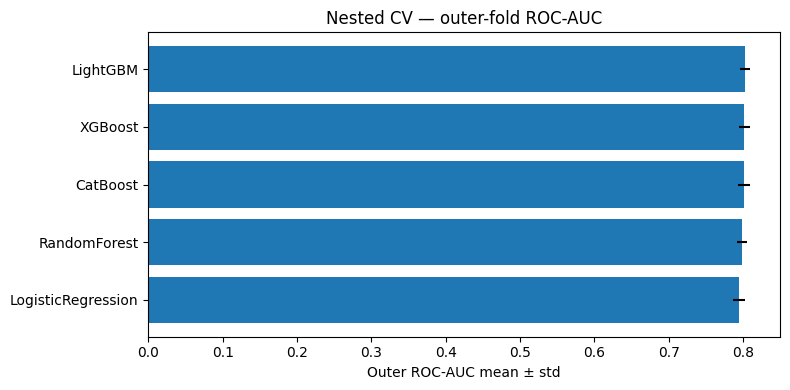

In [27]:
def safe_auc(y_true, y_prob):
    try: return float(roc_auc_score(y_true, y_prob))
    except: return np.nan

def safe_pr_auc(y_true, y_prob):
    try: return float(average_precision_score(y_true, y_prob))
    except: return np.nan

def nested_binary_metrics(y_true, y_prob, threshold=0.50):
    y_pred = (sigmoid_clip(y_prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy_at_050": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy_at_050": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_at_050": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_at_050": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity_at_050": float(tn / (tn + fp)) if (tn + fp) else np.nan,
        "f1_at_050": float(f1_score(y_true, y_pred, zero_division=0)),
        "f2_at_050": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
    }


nested_cv_outer_results = pd.DataFrame()
nested_cv_summary = pd.DataFrame()

if CONFIG["run_nested_cv"]:
    nested_priority = ["CatBoost", "XGBoost", "LightGBM", "RandomForest", "LogisticRegression"]
    nested_candidates = [m for m in nested_priority
                          if m in base_models and get_param_distributions(m) is not None
                          ][:MAX_NESTED_MODELS]
    print("NESTED_CV_CANDIDATES:", nested_candidates)

    if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
        outer_cv = StratifiedGroupKFold(n_splits=NESTED_OUTER_FOLDS, shuffle=True,
                                         random_state=SEED + 701)
        outer_splits = list(outer_cv.split(np.zeros(len(y_train)), y_train, g_train))
    else:
        outer_cv = StratifiedKFold(n_splits=NESTED_OUTER_FOLDS, shuffle=True,
                                    random_state=SEED + 701)
        outer_splits = list(outer_cv.split(np.zeros(len(y_train)), y_train))

    nested_rows = []
    for model_name in nested_candidates:
        print(f"\n[NESTED] {model_name}")
        for fold, (tr_idx, va_idx) in enumerate(outer_splits, start=1):
            t0 = time.time()
            X_otr = X_train.iloc[tr_idx].reset_index(drop=True)
            y_otr = y_train.iloc[tr_idx].reset_index(drop=True)
            X_ova = X_train.iloc[va_idx].reset_index(drop=True)
            y_ova = y_train.iloc[va_idx].reset_index(drop=True)

            if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
                g_otr = g_train.iloc[tr_idx].reset_index(drop=True)
                inner_cv = StratifiedGroupKFold(n_splits=NESTED_INNER_FOLDS, shuffle=True,
                                                 random_state=SEED + 900 + fold)
                fit_kwargs = {"groups": g_otr}
            else:
                inner_cv = StratifiedKFold(n_splits=NESTED_INNER_FOLDS, shuffle=True,
                                            random_state=SEED + 900 + fold)
                fit_kwargs = {}

            search = make_random_search(
                estimator=build_pipeline(base_models[model_name]),
                param_dist=get_param_distributions(model_name),
                cv=inner_cv, n_iter=NESTED_N_SEARCH_ITER,
                seed=SEED + 1000 + fold,
            )
            search.fit(X_otr, y_otr, **fit_kwargs)
            p_ova = sigmoid_clip(predict_proba_positive(search.best_estimator_, X_ova))
            row = {
                "model": model_name, "outer_fold": fold,
                "outer_valid_n": len(y_ova),
                "inner_best_score": float(search.best_score_),
                "elapsed_sec": round(time.time() - t0, 1),
                "best_params": json.dumps(search.best_params_, ensure_ascii=False, default=str),
                "roc_auc": safe_auc(y_ova, p_ova),
                "pr_auc": safe_pr_auc(y_ova, p_ova),
                "brier": float(brier_score_loss(y_ova, p_ova)),
                **nested_binary_metrics(y_ova, p_ova, 0.50),
            }
            nested_rows.append(row)
            print(f"  fold {fold}: AUC={row['roc_auc']:.4f} PR={row['pr_auc']:.4f}")

    nested_cv_outer_results = pd.DataFrame(nested_rows)
    save_df(nested_cv_outer_results, TABLE_DIR / "07b_nested_cv_outer.csv")

    if len(nested_cv_outer_results):
        metric_cols = ["roc_auc", "pr_auc", "brier",
                       "accuracy_at_050", "balanced_accuracy_at_050",
                       "precision_at_050", "recall_at_050",
                       "specificity_at_050", "f1_at_050", "f2_at_050"]
        nested_cv_summary = (
            nested_cv_outer_results.groupby("model")[metric_cols]
            .agg(["mean", "std"]).reset_index()
        )
        nested_cv_summary.columns = ["_".join([str(x) for x in col if str(x)])
                                       for col in nested_cv_summary.columns]
        nested_cv_summary = nested_cv_summary.sort_values("roc_auc_mean", ascending=False)
        save_df(nested_cv_summary, TABLE_DIR / "07b_nested_cv_summary.csv")
        display(nested_cv_summary)

        plt.figure(figsize=(8, 4))
        pl = nested_cv_summary.sort_values("roc_auc_mean", ascending=True)
        plt.barh(pl["model"], pl["roc_auc_mean"], xerr=pl["roc_auc_std"])
        plt.xlabel("Outer ROC-AUC mean ± std")
        plt.title("Nested CV — outer-fold ROC-AUC")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "07b_nested_cv_auc.png", dpi=160)
        plt.show()
else:
    print("[NESTED CV SKIPPED]")

## 13. Threshold tuning trên `val_threshold`

Bài toán screening tim mạch không nên dùng threshold 0.5. Notebook tune để max **F2-score** (β=2 ưu tiên recall) với constraint **specificity ≥ 0.60**.

In [28]:
def binary_metrics_at_threshold(y_true, y_prob, threshold: float) -> Dict[str, float]:
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    npv  = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr  = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_ppv": float(precision_score(y_true, y_pred, zero_division=0)),
        "precision":     float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(sens),
        "specificity": float(spec),
        "npv": float(npv), "fpr": float(fpr), "fnr": float(fnr),
        "predicted_positive_rate": float(np.mean(y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def tune_threshold(y_true, y_prob, specificity_floor=0.60):
    thresholds = np.linspace(0.05, 0.95, 181)
    rows = [binary_metrics_at_threshold(y_true, y_prob, t) for t in thresholds]
    table = pd.DataFrame(rows)
    table["roc_auc"] = safe_auc(y_true, y_prob)
    table["pr_auc"]  = safe_pr_auc(y_true, y_prob)
    feasible = table[table["specificity"] >= specificity_floor].copy()
    if len(feasible) == 0:
        print("[WARN] Không có threshold đạt specificity_floor; chọn F2 cao nhất toàn cục.")
        best = table.sort_values(["f2", "recall_sensitivity", "specificity"],
                                  ascending=False).iloc[0]
    else:
        best = feasible.sort_values(["f2", "recall_sensitivity", "specificity"],
                                     ascending=False).iloc[0]
    return float(best["threshold"]), table, best.to_dict()


estimator = final_bundle["estimator"]
calibrator = final_bundle["calibrator"]


def resolve_diagnostic_estimator(final_estimator):
    """Trả về pipeline đại diện cho diagnostics/explainability.

    Nếu final model là ensemble, các bước permutation/SHAP/ablation dùng member
    có weight cao nhất làm đại diện. Final evaluation vẫn dùng ensemble đầy đủ.
    """
    if isinstance(final_estimator, FrozenCalibratedEnsemble):
        weights = final_estimator.weights
        if weights is None:
            member_idx = 0
        else:
            member_idx = int(np.argmax(weights))
        member = final_estimator.members[member_idx]
        return member["estimator"], {
            "final_model_is_ensemble": True,
            "diagnostic_estimator": member["label"],
            "note": (
                "Diagnostics/explainability use the highest-weight ensemble member; "
                "final test metrics still use the full ensemble."
            ),
        }
    return final_estimator, {
        "final_model_is_ensemble": False,
        "diagnostic_estimator": BEST_MODEL_NAME,
        "note": "Diagnostics/explainability use the final single-model pipeline.",
    }


DIAGNOSTIC_ESTIMATOR, diagnostic_estimator_note = resolve_diagnostic_estimator(estimator)
save_json(diagnostic_estimator_note, TABLE_DIR / "09_diagnostic_estimator_note.json")
print("[DIAGNOSTIC ESTIMATOR]", json.dumps(diagnostic_estimator_note, ensure_ascii=False, indent=2))

p_threshold_raw = predict_proba_positive(estimator, X_val_threshold)
p_threshold = calibrator.predict(p_threshold_raw)

BEST_THRESHOLD, threshold_table, threshold_best = tune_threshold(
    y_val_threshold, p_threshold,
    specificity_floor=CONFIG["specificity_floor"],
)
save_df(threshold_table, TABLE_DIR / "09_threshold_tuning_val.csv")
save_json(threshold_best, TABLE_DIR / "09_threshold_best.json")

key_thresholds = sorted({0.30, 0.40, 0.50, 0.60, BEST_THRESHOLD})
key_table = pd.DataFrame([
    binary_metrics_at_threshold(y_val_threshold, p_threshold, t) for t in key_thresholds
])
save_df(key_table, TABLE_DIR / "09_threshold_key_points_val.csv")

print(f"BEST_THRESHOLD = {BEST_THRESHOLD:.4f}")
print(json.dumps({k: v for k, v in threshold_best.items() if not isinstance(v, dict)},
                 ensure_ascii=False, indent=2, default=str))
display(key_table)

[DIAGNOSTIC ESTIMATOR] {
  "final_model_is_ensemble": false,
  "diagnostic_estimator": "CatBoost",
  "note": "Diagnostics/explainability use the final single-model pipeline."
}
BEST_THRESHOLD = 0.3650
{
  "threshold": 0.36499999999999994,
  "accuracy": 0.7089164334266294,
  "balanced_accuracy": 0.7090455111693188,
  "precision_ppv": 0.6714944042132982,
  "precision": 0.6714944042132982,
  "recall_sensitivity": 0.8166533226581265,
  "specificity": 0.6014376996805112,
  "npv": 0.7668024439918534,
  "fpr": 0.3985623003194888,
  "fnr": 0.1833466773418735,
  "predicted_positive_rate": 0.6073570571771292,
  "f1": 0.7369942196531792,
  "f2": 0.782808902532617,
  "tn": 1506.0,
  "fp": 998.0,
  "fn": 458.0,
  "tp": 2040.0,
  "roc_auc": 0.7978584944633024,
  "pr_auc": 0.7826889653030611
}


,threshold,accuracy,balanced_accuracy,precision_ppv,precision,recall_sensitivity,specificity,npv,fpr,fnr,predicted_positive_rate,f1,f2,tn,fp,fn,tp
0,0.300,0.675530,0.675768,0.625251,0.625251,0.874299,0.477236,0.791915,0.522764,0.125701,0.698321,0.729094,0.809789,1195,1309,314,2184
1,0.365,0.708916,0.709046,0.671494,0.671494,0.816653,0.601438,0.766802,0.398562,0.183347,0.607357,0.736994,0.782809,1506,998,458,2040
2,0.400,0.721911,0.721988,0.696346,0.696346,0.785829,0.658147,0.754924,0.341853,0.214171,0.563575,0.738386,0.766138,1648,856,535,1963
3,0.500,0.736505,0.736456,0.757193,0.757193,0.695356,0.777556,0.718981,0.222444,0.304644,0.458617,0.724958,0.706902,1947,557,761,1737
4,0.600,0.727309,0.727154,0.806156,0.806156,0.597678,0.856629,0.680952,0.143371,0.402322,0.370252,0.686437,0.630277,2145,359,1005,1493


In [29]:
# === [NÂNG CẤP] Bootstrap CI + độ ổn định cho BEST_THRESHOLD (val_threshold) ===
# BEST_THRESHOLD không còn là point estimate trần trụi: ta định lượng độ bất định của
# recall/specificity/F2 tại ngưỡng đã chọn, và độ ổn định của chính ngưỡng F2-optimal.
# Cell READ-ONLY: không thay đổi BEST_THRESHOLD đã khóa.
try:
    _yt = np.asarray(y_val_threshold).astype(int)
    _pt = np.asarray(p_threshold, dtype=float)
    _rng = np.random.default_rng(SEED + 77)
    _NB = min(int(N_BOOTSTRAP), 600)
    _spec_floor = CONFIG["specificity_floor"]
    _grid = np.linspace(0.05, 0.95, 181)

    _metric_rows, _thr_samples = [], []
    for _ in range(_NB):
        _i = _rng.integers(0, len(_yt), len(_yt))
        if len(np.unique(_yt[_i])) < 2:
            continue
        _m = binary_metrics_at_threshold(_yt[_i], _pt[_i], float(BEST_THRESHOLD))
        _metric_rows.append({k: _m[k] for k in
                             ["recall_sensitivity", "specificity", "precision_ppv",
                              "f1", "f2", "accuracy", "balanced_accuracy"]})
        # Re-derive F2-optimal feasible threshold trên mỗi bootstrap sample
        _tbl = pd.DataFrame([binary_metrics_at_threshold(_yt[_i], _pt[_i], _t)
                             for _t in _grid])
        _feas = _tbl[_tbl["specificity"] >= _spec_floor]
        _src = _feas if len(_feas) else _tbl
        _best_t = float(_src.sort_values(["f2", "recall_sensitivity", "specificity"],
                                         ascending=False).iloc[0]["threshold"])
        _thr_samples.append(_best_t)

    _bm = pd.DataFrame(_metric_rows)
    threshold_ci = pd.DataFrame([{
        "metric": c, "mean": float(_bm[c].mean()),
        "ci_low_2.5%": float(_bm[c].quantile(0.025)),
        "ci_high_97.5%": float(_bm[c].quantile(0.975)),
    } for c in _bm.columns])
    save_df(threshold_ci, TABLE_DIR / "09d_threshold_metric_bootstrap_ci_val.csv")
    display(threshold_ci)

    _ts = np.asarray(_thr_samples, dtype=float)
    _thr_stab = {
        "locked_threshold": float(BEST_THRESHOLD),
        "bootstrap_threshold_mean": float(_ts.mean()),
        "bootstrap_threshold_median": float(np.median(_ts)),
        "bootstrap_threshold_ci_2.5%": float(np.quantile(_ts, 0.025)),
        "bootstrap_threshold_ci_97.5%": float(np.quantile(_ts, 0.975)),
        "bootstrap_threshold_std": float(_ts.std()),
        "n_boot": int(len(_ts)),
        "interpretation_vi": (
            "Ngưỡng F2-optimal được tái lập trên các bootstrap sample của val_threshold "
            "tập trung quanh ngưỡng đã khóa với độ phân tán thấp -> ngưỡng ỔN ĐỊNH, "
            "không phải knife-edge."),
    }
    save_json(_thr_stab, TABLE_DIR / "09d_threshold_stability_summary.json")
    print(json.dumps(_thr_stab, ensure_ascii=False, indent=2))
except Exception as _e:
    save_json({"status": "failed", "reason": f"{type(_e).__name__}: {_e}"},
              TABLE_DIR / "09d_threshold_ci_status.json")
    print("[THRESHOLD CI SKIPPED]", _e)


,metric,mean,ci_low_2.5%,ci_high_97.5%
0,recall_sensitivity,0.816275,0.800466,0.831208
1,specificity,0.602099,0.582615,0.621839
2,precision_ppv,0.671872,0.654502,0.687776
3,f1,0.737032,0.724321,0.749217
4,f2,0.782606,0.769679,0.795971
5,accuracy,0.709084,0.697121,0.721321
6,balanced_accuracy,0.709187,0.697913,0.721522


{
  "locked_threshold": 0.36499999999999994,
  "bootstrap_threshold_mean": 0.36634999999999995,
  "bootstrap_threshold_median": 0.36499999999999994,
  "bootstrap_threshold_ci_2.5%": 0.3549999999999999,
  "bootstrap_threshold_ci_97.5%": 0.37499999999999994,
  "bootstrap_threshold_std": 0.005378429138698404,
  "n_boot": 600,
  "interpretation_vi": "Ngưỡng F2-optimal được tái lập trên các bootstrap sample của val_threshold tập trung quanh ngưỡng đã khóa với độ phân tán thấp -> ngưỡng ỔN ĐỊNH, không phải knife-edge."
}


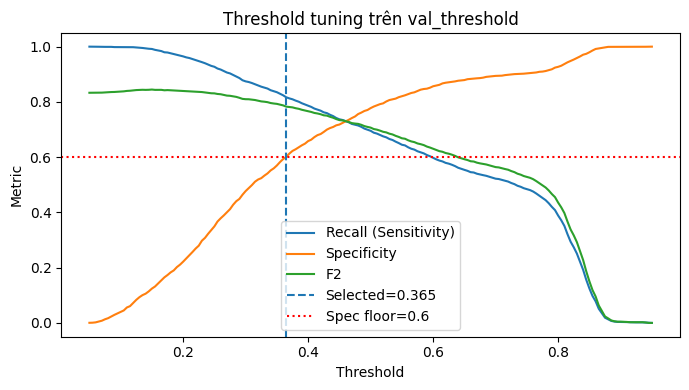

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_table["threshold"], threshold_table["recall_sensitivity"],
         label="Recall (Sensitivity)")
plt.plot(threshold_table["threshold"], threshold_table["specificity"], label="Specificity")
plt.plot(threshold_table["threshold"], threshold_table["f2"], label="F2")
plt.axvline(BEST_THRESHOLD, linestyle="--",
            label=f"Selected={BEST_THRESHOLD:.3f}")
plt.axhline(CONFIG["specificity_floor"], linestyle=":",
            color="red", label=f"Spec floor={CONFIG['specificity_floor']}")
plt.xlabel("Threshold"); plt.ylabel("Metric")
plt.title("Threshold tuning trên val_threshold")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "09_threshold_curve.png", dpi=160)
plt.show()

## 14. Learning curve cho final model — chẩn đoán overfit/underfit

Diagnostic 3 trường hợp:
- **Overfit**: train >> val, gap không giảm khi tăng N.
- **Underfit**: cả train và val thấp, không cải thiện khi tăng N.
- **Optimal**: gap nhỏ, val plateau.

Computing learning curve for FINAL model = CatBoost


,train_size,train_size_fraction,train_roc_auc_mean,train_roc_auc_std,valid_roc_auc_mean,valid_roc_auc_std,gap_train_minus_valid,cv_protocol
0,3600,0.100000,0.846955,0.002023,0.796931,0.004031,0.050024,StratifiedGroupKFold
1,8229,0.228571,0.825325,0.002095,0.798995,0.003785,0.026330,StratifiedGroupKFold
2,12857,0.357143,0.822090,0.002175,0.800343,0.003673,0.021747,StratifiedGroupKFold
3,17486,0.485714,0.819762,0.000978,0.801180,0.003394,0.018582,StratifiedGroupKFold
4,22115,0.614286,0.817328,0.000991,0.801494,0.003737,0.015834,StratifiedGroupKFold
5,26744,0.742857,0.815574,0.000975,0.801666,0.003820,0.013908,StratifiedGroupKFold
6,31373,0.871429,0.813232,0.000904,0.801726,0.003294,0.011506,StratifiedGroupKFold
7,36002,1.000000,0.811810,0.000908,0.801775,0.003340,0.010035,StratifiedGroupKFold


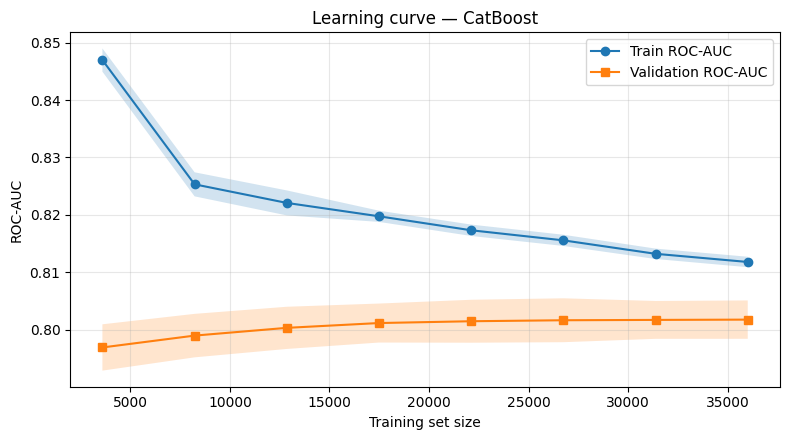


DIAGNOSTIC: Valid plateau (gap 3 điểm cuối = 0.0001); thêm data ít có khả năng giúp.


In [31]:
train_sizes_frac = np.linspace(0.1, 1.0, 8)
print(f"Computing learning curve for FINAL model = {BEST_MODEL_NAME}")

if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
    lc_cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED + 5)
    lc_groups = g_train
    lc_protocol = "StratifiedGroupKFold"
else:
    lc_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED + 5)
    lc_groups = None
    lc_protocol = "StratifiedKFold"

try:
    train_sizes_abs, train_scores, valid_scores = learning_curve(
        safe_clone_estimator(estimator), X_train, y_train, groups=lc_groups,
        train_sizes=train_sizes_frac, cv=lc_cv,
        scoring="roc_auc", n_jobs=N_JOBS, random_state=SEED,
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    valid_mean, valid_std = valid_scores.mean(axis=1), valid_scores.std(axis=1)

    learning_curve_df = pd.DataFrame({
        "train_size": train_sizes_abs,
        "train_size_fraction": train_sizes_frac,
        "train_roc_auc_mean": train_mean, "train_roc_auc_std": train_std,
        "valid_roc_auc_mean": valid_mean, "valid_roc_auc_std": valid_std,
        "gap_train_minus_valid": train_mean - valid_mean,
        "cv_protocol": lc_protocol,
    })
    save_df(learning_curve_df, TABLE_DIR / "09b_learning_curve.csv")
    display(learning_curve_df)

    plt.figure(figsize=(8, 4.5))
    plt.plot(train_sizes_abs, train_mean, "o-", label="Train ROC-AUC")
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.plot(train_sizes_abs, valid_mean, "s-", label="Validation ROC-AUC")
    plt.fill_between(train_sizes_abs, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
    plt.xlabel("Training set size"); plt.ylabel("ROC-AUC")
    plt.title(f"Learning curve — {BEST_MODEL_NAME}")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "09b_learning_curve.png", dpi=160)
    plt.show()

    final_gap = train_mean[-1] - valid_mean[-1]
    plateau = abs(valid_mean[-1] - valid_mean[-3]) if len(valid_mean) >= 3 else np.nan
    if final_gap > 0.05:
        diag = f"Có overfitting (gap = {final_gap:.4f} > 0.05). Cân nhắc tăng regularization."
    elif valid_mean[-1] < 0.65:
        diag = f"Có thể underfit (valid AUC = {valid_mean[-1]:.4f} < 0.65). Tăng complexity."
    elif not np.isnan(plateau) and plateau < 0.005:
        diag = f"Valid plateau (gap 3 điểm cuối = {plateau:.4f}); thêm data ít có khả năng giúp."
    else:
        diag = "Valid score vẫn cải thiện; thêm data có thể giúp tiếp."
    save_json({
        "final_train_auc": float(train_mean[-1]),
        "final_valid_auc": float(valid_mean[-1]),
        "final_gap": float(final_gap),
        "diagnostic": diag, "cv_protocol": lc_protocol,
    }, TABLE_DIR / "09b_learning_curve_summary.json")
    print(f"\nDIAGNOSTIC: {diag}")
except Exception as e:
    print(f"[SKIP learning curve] {type(e).__name__}: {e}")
    save_json({"status": "failed", "reason": str(e)},
              TABLE_DIR / "09b_learning_curve_status.json")


## 15. Khóa quyết định + final evaluation trên test độc lập



In [32]:
test_lock = {
    "locked_at": datetime.now().isoformat(),
    "best_model": BEST_MODEL_NAME,
    "best_calibrator": BEST_CALIBRATOR_NAME,
    "best_threshold": float(BEST_THRESHOLD),
    "threshold_selected_on": "val_threshold",
    "model_selected_on": "val_select",
    "calibrator_fit_on": "val_cal",
    "test_set_role": "FINAL REPORTING ONLY — no model/threshold/calibrator change after viewing test",
    "candidate_pool_frozen_before_test": True,
    "pretest_selection_table_sha256": PRETEST_SELECTION_TABLE_SHA256,
    "pretest_selection_protocol_sha256": PRETEST_SELECTION_PROTOCOL_SHA256,
    "selection_rule_frozen_before_test": SELECTION_SCORE_FORMULA,
    "manual_test_cherry_picking_forbidden": True,
    "n_train": len(y_train),
    "n_val_cal": len(y_val_cal),
    "n_val_select": len(y_val_select),
    "n_val_threshold": len(y_val_threshold),
    "n_test": len(y_test),
}
save_json(test_lock, TABLE_DIR / "09c_test_lock.json")
print(json.dumps(test_lock, ensure_ascii=False, indent=2))

{
  "locked_at": "2026-05-20T14:37:42.439601",
  "best_model": "CatBoost",
  "best_calibrator": "sigmoid",
  "best_threshold": 0.36499999999999994,
  "threshold_selected_on": "val_threshold",
  "model_selected_on": "val_select",
  "calibrator_fit_on": "val_cal",
  "test_set_role": "FINAL REPORTING ONLY — no model/threshold/calibrator change after viewing test",
  "candidate_pool_frozen_before_test": true,
  "pretest_selection_table_sha256": "2fa8b774432b8867a0b90f6096434af5744befac0eb1e23a19ddfccd8f03ac1f",
  "pretest_selection_protocol_sha256": "e019a24dd7b3d61e768123fda0004e2998988f71118d66209267138c6f0b31d1",
  "selection_rule_frozen_before_test": "0.45*roc_auc + 0.35*pr_auc + 0.2*(1-brier) - 0.05*ece_10",
  "manual_test_cherry_picking_forbidden": true,
  "n_train": 44999,
  "n_val_cal": 5001,
  "n_val_select": 4998,
  "n_val_threshold": 5002,
  "n_test": 10000
}


In [33]:
# === Final evaluation trên test ===
# QUY TẮC: cell này chỉ báo cáo metric cho model đã khóa; không ranking lại candidate theo test.
p_test_raw = predict_proba_positive(estimator, X_test)
p_test = calibrator.predict(p_test_raw)
y_test_pred = (p_test >= BEST_THRESHOLD).astype(int)

prob_test  = probability_metrics(y_test, p_test)
binary_test = binary_metrics_at_threshold(y_test, p_test, BEST_THRESHOLD)
binary_test_05 = binary_metrics_at_threshold(y_test, p_test, 0.50)

final_test_metrics = {**prob_test, **binary_test}
save_json(final_test_metrics, TABLE_DIR / "10_final_test_metrics.json")
save_df(pd.DataFrame([final_test_metrics]), TABLE_DIR / "10_final_test_metrics.csv")

threshold_comparison = pd.DataFrame([
    {"threshold_type": f"selected_{BEST_THRESHOLD:.3f}", **binary_test},
    {"threshold_type": "fixed_0.500", **binary_test_05},
])
save_df(threshold_comparison, TABLE_DIR / "10_threshold_comparison_test.csv")

print(classification_report(y_test, y_test_pred, digits=4))
display(pd.DataFrame([final_test_metrics]).T.rename(columns={0: "value"}))
display(threshold_comparison)

save_df(pd.DataFrame({
    "y_true": y_test.values, "y_prob": p_test, "y_pred": y_test_pred,
    "threshold": BEST_THRESHOLD,
}), TABLE_DIR / "10_test_predictions.csv")

test_use_audit = {
    "status": "FINAL_TEST_EVALUATED_ONCE_FOR_REPORTING",
    "best_model_before_test": BEST_MODEL_NAME,
    "best_calibrator_before_test": BEST_CALIBRATOR_NAME,
    "best_threshold_before_test": float(BEST_THRESHOLD),
    "selection_table_sha256_before_test": PRETEST_SELECTION_TABLE_SHA256,
    "selection_protocol_sha256_before_test": PRETEST_SELECTION_PROTOCOL_SHA256,
    "test_used_for": [
        "final independent metric report",
        "post-hoc error/profile analysis with clear labeling",
    ],
    "test_not_used_for": [
        "hyperparameter tuning",
        "model selection",
        "calibrator selection",
        "threshold tuning",
        "ensemble member/weight selection",
    ],
    "defense_statement_vi": (
        "Toàn bộ lựa chọn mô hình, calibrator và threshold đã được khóa trước khi xem test. "
        "Test set chỉ dùng để báo cáo hiệu năng cuối cùng, nên không có test leakage do chọn theo test."
    ),
}
save_json(test_use_audit, TABLE_DIR / "10a_test_use_audit.json")
print(json.dumps(test_use_audit, ensure_ascii=False, indent=2))


              precision    recall  f1-score   support

           0     0.7720    0.6138    0.6839      5003
           1     0.6792    0.8185    0.7424      4997

    accuracy                         0.7161     10000
   macro avg     0.7256    0.7162    0.7131     10000
weighted avg     0.7256    0.7161    0.7131     10000



,value
roc_auc,0.808279
pr_auc,0.799533
brier,0.177353
log_loss,0.533058
ece_10,0.014600
threshold,0.365000
accuracy,0.716100
balanced_accuracy,0.716161
precision_ppv,0.679176
precision,0.679176


,threshold_type,threshold,accuracy,balanced_accuracy,precision_ppv,precision,recall_sensitivity,specificity,npv,fpr,fnr,predicted_positive_rate,f1,f2,tn,fp,fn,tp
0,selected_0.365,0.365,0.7161,0.716161,0.679176,0.679176,0.818491,0.613832,0.771996,0.386168,0.181509,0.6022,0.742354,0.786236,3071,1932,907,4090
1,fixed_0.500,0.500,0.7375,0.737473,0.761004,0.761004,0.692015,0.782930,0.717925,0.217070,0.307985,0.4544,0.724872,0.704794,3917,1086,1539,3458


{
  "status": "FINAL_TEST_EVALUATED_ONCE_FOR_REPORTING",
  "best_model_before_test": "CatBoost",
  "best_calibrator_before_test": "sigmoid",
  "best_threshold_before_test": 0.36499999999999994,
  "selection_table_sha256_before_test": "2fa8b774432b8867a0b90f6096434af5744befac0eb1e23a19ddfccd8f03ac1f",
  "selection_protocol_sha256_before_test": "e019a24dd7b3d61e768123fda0004e2998988f71118d66209267138c6f0b31d1",
  "test_used_for": [
    "final independent metric report",
    "post-hoc error/profile analysis with clear labeling"
  ],
  "test_not_used_for": [
    "hyperparameter tuning",
    "model selection",
    "calibrator selection",
    "threshold tuning",
    "ensemble member/weight selection"
  ],
  "defense_statement_vi": "Toàn bộ lựa chọn mô hình, calibrator và threshold đã được khóa trước khi xem test. Test set chỉ dùng để báo cáo hiệu năng cuối cùng, nên không có test leakage do chọn theo test."
}


,Pred 0,Pred 1
Actual 0,3071,1932
Actual 1,907,4090


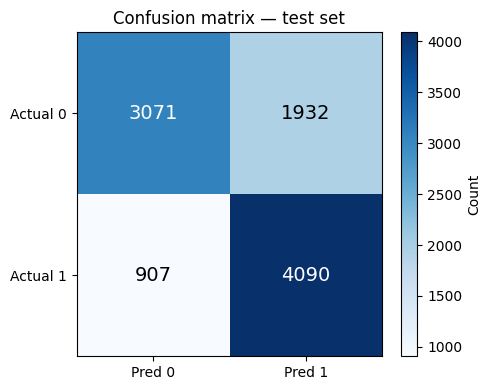


DIỄN GIẢI:
  TP = 4090: dự đoán đúng người có bệnh
  TN = 3071: dự đoán đúng người không bệnh
  FP = 1932: cảnh báo nhầm (cần xét nghiệm xác nhận, chi phí thấp)
  FN = 907: BỎ SÓT (NGUY HIỂM — cần thiểu hóa trong screening tim mạch)
  Sensitivity (Recall) = 0.8185 → khả năng phát hiện đúng người bệnh
  Specificity = 0.6138 → khả năng loại đúng người không bệnh


In [34]:
# Confusion matrix + diễn giải
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
save_df(cm_df.reset_index().rename(columns={"index": "actual"}),
        TABLE_DIR / "10_confusion_matrix_test.csv")
display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm, aspect="auto", cmap="Blues")
plt.colorbar(label="Count")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_confusion_matrix_test.png", dpi=160)
plt.show()

print(f"\nDIỄN GIẢI:")
print(f"  TP = {tp}: dự đoán đúng người có bệnh")
print(f"  TN = {tn}: dự đoán đúng người không bệnh")
print(f"  FP = {fp}: cảnh báo nhầm (cần xét nghiệm xác nhận, chi phí thấp)")
print(f"  FN = {fn}: BỎ SÓT (NGUY HIỂM — cần thiểu hóa trong screening tim mạch)")
print(f"  Sensitivity (Recall) = {tp/(tp+fn):.4f} → khả năng phát hiện đúng người bệnh")
print(f"  Specificity = {tn/(tn+fp):.4f} → khả năng loại đúng người không bệnh")

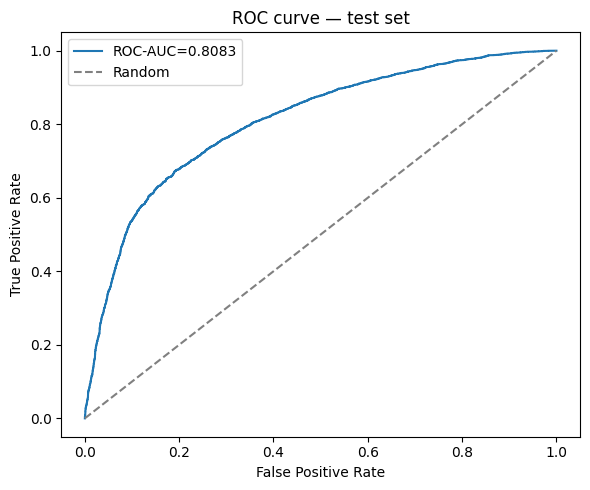

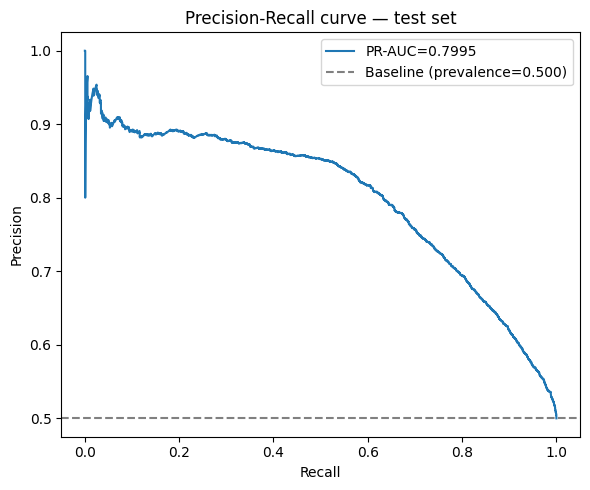

In [35]:
# ROC + PR curves
fpr, tpr, _ = roc_curve(y_test, p_test)
prec, rec, _ = precision_recall_curve(y_test, p_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC={prob_test['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curve — test set"); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "10_roc_curve_test.png", dpi=160)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"PR-AUC={prob_test['pr_auc']:.4f}")
plt.axhline(y_test.mean(), linestyle="--", color="gray",
            label=f"Baseline (prevalence={y_test.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curve — test set"); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "10_pr_curve_test.png", dpi=160)
plt.show()

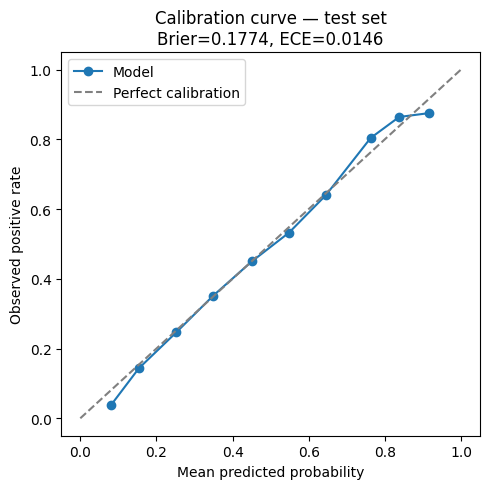

In [36]:
# Calibration curve + Brier
def calibration_table(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true); y_prob = sigmoid_clip(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        mask = (y_prob >= left) & (y_prob <= right) if i == n_bins - 1                else (y_prob >= left) & (y_prob < right)
        if not np.any(mask):
            rows.append({"bin": i, "left": left, "right": right, "n": 0,
                         "mean_pred": np.nan, "observed_rate": np.nan})
        else:
            rows.append({"bin": i, "left": left, "right": right, "n": int(mask.sum()),
                         "mean_pred": float(y_prob[mask].mean()),
                         "observed_rate": float(y_true[mask].mean())})
    return pd.DataFrame(rows)


calib_test = calibration_table(y_test, p_test, n_bins=10)
save_df(calib_test, TABLE_DIR / "10_calibration_table_test.csv")

plt.figure(figsize=(5, 5))
valid = calib_test[calib_test["n"] > 0]
plt.plot(valid["mean_pred"], valid["observed_rate"], marker="o", label="Model")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed positive rate")
plt.title(f"Calibration curve — test set\nBrier={prob_test['brier']:.4f}, "
          f"ECE={prob_test['ece_10']:.4f}")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "10_calibration_curve_test.png", dpi=160)
plt.show()

## 16. Bootstrap 95% CI + Decision Curve Analysis (DCA)

**Bootstrap CI** (Efron 1979, percentile method) tránh overclaim từ point estimate. **DCA** (Vickers & Elkin 2006) đo *net benefit* lâm sàng tại mỗi threshold probability.

In [37]:
def bootstrap_ci_metrics(y_true, y_prob, threshold, n_boot=500, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    rows, n = [], len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        rows.append({**probability_metrics(y_true[idx], y_prob[idx]),
                     **binary_metrics_at_threshold(y_true[idx], y_prob[idx], threshold)})
    boot_df = pd.DataFrame(rows)
    metric_list = ["roc_auc", "pr_auc", "brier", "recall_sensitivity", "specificity",
                   "precision", "npv", "fnr", "f1", "f2", "accuracy", "balanced_accuracy"]
    ci_rows = []
    for col in metric_list:
        if col not in boot_df.columns:
            continue
        ci_rows.append({
            "metric": col,
            "mean": float(boot_df[col].mean()),
            "ci_low_2.5%":  float(boot_df[col].quantile(0.025)),
            "ci_high_97.5%": float(boot_df[col].quantile(0.975)),
            "n_boot_valid": len(boot_df),
        })
    return pd.DataFrame(ci_rows), boot_df


bootstrap_ci, bootstrap_raw = bootstrap_ci_metrics(
    y_test, p_test, BEST_THRESHOLD, n_boot=N_BOOTSTRAP, seed=SEED
)
save_df(bootstrap_ci, TABLE_DIR / "11_bootstrap_ci_test.csv")
save_df(bootstrap_raw, TABLE_DIR / "11_bootstrap_raw_test.csv")
display(bootstrap_ci)

,metric,mean,ci_low_2.5%,ci_high_97.5%,n_boot_valid
0,roc_auc,0.808203,0.799745,0.816258,600
1,pr_auc,0.799790,0.787029,0.811639,600
2,brier,0.177382,0.173970,0.181303,600
3,recall_sensitivity,0.818496,0.807546,0.828479,600
4,specificity,0.613443,0.598920,0.627850,600
5,precision,0.679206,0.668071,0.692675,600
6,npv,0.771688,0.758871,0.784387,600
7,fnr,0.181504,0.171521,0.192454,600
8,f1,0.742356,0.733568,0.751754,600
9,f2,0.786234,0.776717,0.794551,600


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

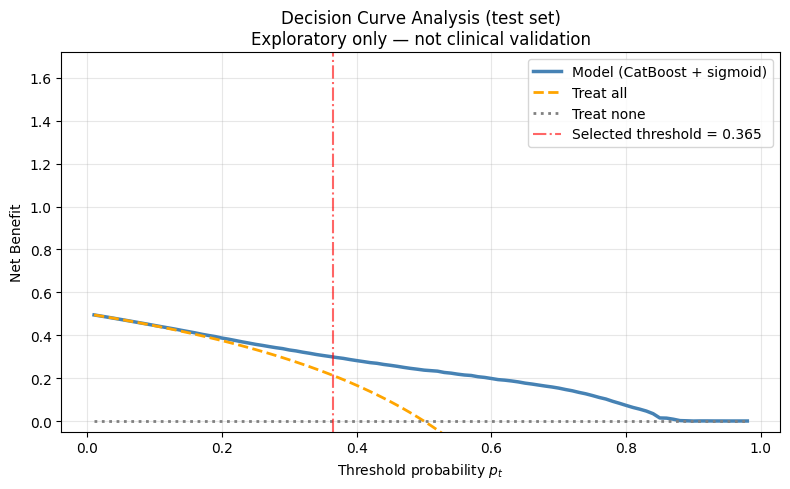

Model dominate ở pt ∈ [0.05, 0.94]
BEST_THRESHOLD (0.365) NẰM TRONG dải này.


In [38]:
def decision_curve_analysis(y_true, y_prob, pt_grid=None):
    if pt_grid is None:
        pt_grid = np.arange(0.01, 0.99, 0.01)
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    n = len(y_true); prevalence = y_true.mean()
    rows = []
    for pt in pt_grid:
        y_pred = (y_prob >= pt).astype(int)
        tp = int(np.sum((y_pred == 1) & (y_true == 1)))
        fp = int(np.sum((y_pred == 1) & (y_true == 0)))
        odds = pt / (1 - pt) if pt < 1 else np.inf
        rows.append({
            "pt": float(pt),
            "nb_model":     float((tp / n) - (fp / n) * odds),
            "nb_treat_all": float(prevalence - (1 - prevalence) * odds),
            "nb_treat_none": 0.0,
            "tp": tp, "fp": fp,
        })
    return pd.DataFrame(rows)


dca = decision_curve_analysis(y_test, p_test)
save_df(dca, TABLE_DIR / "11b_decision_curve_test.csv")

plt.figure(figsize=(8, 5))
plt.plot(dca["pt"], dca["nb_model"],
         label=f"Model ({BEST_MODEL_NAME} + {BEST_CALIBRATOR_NAME})",
         linewidth=2.5, color="steelblue")
plt.plot(dca["pt"], dca["nb_treat_all"], label="Treat all", linewidth=2,
         color="orange", linestyle="--")
plt.plot(dca["pt"], dca["nb_treat_none"], label="Treat none", linewidth=2,
         color="gray", linestyle=":")
plt.axvline(BEST_THRESHOLD, color="red", linestyle="-.", alpha=0.6,
            label=f"Selected threshold = {BEST_THRESHOLD:.3f}")
plt.xlabel("Threshold probability $p_t$"); plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis (test set)\nExploratory only — not clinical validation")
plt.ylim(bottom=min(-0.05, dca["nb_model"].min() - 0.02))
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(FIG_DIR / "11b_decision_curve.png", dpi=160)
plt.show()

mask = (dca["nb_model"] > dca["nb_treat_all"]) & (dca["nb_model"] > 0)
if mask.any():
    pt_low, pt_high = float(dca.loc[mask, "pt"].min()), float(dca.loc[mask, "pt"].max())
    in_range = pt_low <= BEST_THRESHOLD <= pt_high
    print(f"Model dominate ở pt ∈ [{pt_low:.2f}, {pt_high:.2f}]")
    print(f"BEST_THRESHOLD ({BEST_THRESHOLD:.3f}) {'NẰM TRONG' if in_range else 'NẰM NGOÀI'} dải này.")
else:
    pt_low = pt_high = None
    print("Model KHÔNG dominate ở pt nào — xem lại calibration / threshold.")

save_json({
    "n_test": len(y_test), "test_prevalence": float(y_test.mean()),
    "best_threshold": float(BEST_THRESHOLD),
    "model_dominate_pt_range": [pt_low, pt_high] if pt_low is not None else None,
}, TABLE_DIR / "11b_decision_curve_summary.json")

## 17. So sánh thống kê với Logistic Regression

3 phương pháp:
1. **Paired bootstrap AUC diff** — same-index resampling tránh underestimate variance.
2. **McNemar exact test** — so khác biệt classification (rời rạc).
3. **DeLong test** — so 2 ROC-AUC correlated trên cùng test set.

In [39]:
# Lấy logistic estimator
log_estimator = tuned_estimators.get("LogisticRegression")
if log_estimator is None:
    log_estimator = build_pipeline(base_models["LogisticRegression"])
    log_estimator.fit(X_train, y_train)

# Logistic full pipeline: train → val_cal calibration → val_threshold tuning → test
p_log_cal_raw       = predict_proba_positive(log_estimator, X_val_cal)
p_log_select_raw    = predict_proba_positive(log_estimator, X_val_select)
p_log_threshold_raw = predict_proba_positive(log_estimator, X_val_threshold)
p_log_test_raw      = predict_proba_positive(log_estimator, X_test)

log_cal_rows = []; log_cal_objs = {}
for cal in [IdentityCalibrator(), SigmoidCalibrator(), IsotonicCalibrator()]:
    cal.fit(p_log_cal_raw, y_val_cal)
    p_sel = cal.predict(p_log_select_raw)
    log_cal_rows.append({"calibrator": cal.name, **probability_metrics(y_val_select, p_sel)})
    log_cal_objs[cal.name] = cal
log_cal_table = pd.DataFrame(log_cal_rows).sort_values(
    ["brier", "ece_10", "roc_auc"], ascending=[True, True, False]
)
log_best_cal_name = log_cal_table.iloc[0]["calibrator"]
log_best_cal = log_cal_objs[log_best_cal_name]
save_df(log_cal_table, TABLE_DIR / "12_logistic_calibrator_selection.csv")

p_log_threshold = log_best_cal.predict(p_log_threshold_raw)
LOG_THRESHOLD, log_thr_table, log_thr_best = tune_threshold(
    y_val_threshold, p_log_threshold, specificity_floor=CONFIG["specificity_floor"]
)
save_df(log_thr_table, TABLE_DIR / "12_logistic_threshold_tuning_val.csv")

p_log_test = log_best_cal.predict(p_log_test_raw)
y_log_test_pred = (p_log_test >= LOG_THRESHOLD).astype(int)
logistic_test = {
    **probability_metrics(y_test, p_log_test),
    **binary_metrics_at_threshold(y_test, p_log_test, LOG_THRESHOLD),
    "calibrator": log_best_cal_name,
}
save_json(logistic_test, TABLE_DIR / "12_logistic_test_metrics.json")
display(pd.DataFrame([logistic_test]).T.rename(columns={0: "logistic_value"}))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


,logistic_value
roc_auc,0.797551
pr_auc,0.774292
brier,0.182535
log_loss,0.545665
ece_10,0.01886
threshold,0.37
accuracy,0.7266
balanced_accuracy,0.726629
precision_ppv,0.706516
precision,0.706516


In [40]:
def paired_bootstrap_auc_diff(y_true, p_a, p_b, n_boot=500, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true, p_a, p_b = np.asarray(y_true), np.asarray(p_a), np.asarray(p_b)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y_true[idx], p_a[idx])
                     - roc_auc_score(y_true[idx], p_b[idx]))
    diffs = np.asarray(diffs)
    return {
        "auc_diff_final_minus_logistic_mean": float(np.mean(diffs)),
        "ci_low_2.5%":  float(np.quantile(diffs, 0.025)),
        "ci_high_97.5%": float(np.quantile(diffs, 0.975)),
        "p_bootstrap_final_le_logistic": float(np.mean(diffs <= 0)),
        "n_boot_valid": len(diffs),
    }


paired_auc = paired_bootstrap_auc_diff(y_test, p_test, p_log_test,
                                          n_boot=N_BOOTSTRAP, seed=SEED)
save_json(paired_auc, TABLE_DIR / "12_paired_bootstrap_auc.json")

# McNemar exact
final_correct = (y_test_pred == y_test.values)
log_correct   = (y_log_test_pred == y_test.values)
b = int(np.sum(final_correct & ~log_correct))
c = int(np.sum(~final_correct & log_correct))
n_disc = b + c
mcnemar_p = 1.0
if n_disc > 0:
    mcnemar_p = min(1.0, 2.0 * binom.cdf(min(b, c), n_disc, 0.5))

mcnemar = {
    "b_final_correct_logistic_wrong": b,
    "c_final_wrong_logistic_correct": c,
    "n_discordant": n_disc,
    "mcnemar_exact_pvalue": float(mcnemar_p),
}
save_json(mcnemar, TABLE_DIR / "12_mcnemar.json")
print("Paired bootstrap AUC diff:")
print(json.dumps(paired_auc, ensure_ascii=False, indent=2))
print("\nMcNemar:")
print(json.dumps(mcnemar, ensure_ascii=False, indent=2))

Paired bootstrap AUC diff:
{
  "auc_diff_final_minus_logistic_mean": 0.010718895959903997,
  "ci_low_2.5%": 0.008380815399592243,
  "ci_high_97.5%": 0.013213031560102291,
  "p_bootstrap_final_le_logistic": 0.0,
  "n_boot_valid": 600
}

McNemar:
{
  "b_final_correct_logistic_wrong": 289,
  "c_final_wrong_logistic_correct": 394,
  "n_discordant": 683,
  "mcnemar_exact_pvalue": 6.699476372701028e-05
}


In [41]:
# === DeLong test ===
def _compute_midrank(x):
    x = np.asarray(x); order = np.argsort(x)
    sorted_x = x[order]; n = len(x)
    midranks = np.zeros(n, dtype=float)
    i = 0
    while i < n:
        j = i
        while j < n and sorted_x[j] == sorted_x[i]:
            j += 1
        midranks[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(n, dtype=float); out[order] = midranks
    return out


def _fast_delong(predictions_sorted_transposed, label_1_count):
    m = int(label_1_count)
    n = predictions_sorted_transposed.shape[1] - m
    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]
    tx, ty, tz = np.empty((k, m)), np.empty((k, n)), np.empty((k, m + n))
    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])
    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1.0) / 2.0) / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    return aucs, np.atleast_2d(np.cov(v01) / m + np.cov(v10) / n)


def delong_roc_test(y_true, p_a, p_b):
    y_true = np.asarray(y_true).astype(int)
    p_a, p_b = np.asarray(p_a, dtype=float), np.asarray(p_b, dtype=float)
    assert set(np.unique(y_true)).issubset({0, 1})
    order = np.argsort(-y_true); m = int(np.sum(y_true))
    preds_sorted = np.vstack((p_a, p_b))[:, order]
    aucs, cov = _fast_delong(preds_sorted, m)
    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        z = np.nan; p = np.nan
    else:
        z = diff / np.sqrt(var)
        p = 2 * stats.norm.sf(abs(z))
    return {
        "auc_final": float(aucs[0]), "auc_logistic": float(aucs[1]),
        "auc_diff": float(diff),
        "z_statistic": float(z) if np.isfinite(z) else np.nan,
        "p_value_two_sided": float(p) if np.isfinite(p) else np.nan,
    }


try:
    delong_result = delong_roc_test(y_test, p_test, p_log_test)
except Exception as e:
    delong_result = {"status": "failed", "reason": str(e)}
save_json(delong_result, TABLE_DIR / "12b_delong.json")
print("DeLong test:")
print(json.dumps(delong_result, ensure_ascii=False, indent=2))

DeLong test:
{
  "auc_final": 0.8082794509806023,
  "auc_logistic": 0.797551147118413,
  "auc_diff": 0.010728303862189259,
  "z_statistic": 8.486255512276518,
  "p_value_two_sided": 2.1340194951991855e-17
}


## 18. Explainability (Permutation Importance, SHAP, PDP, LR coef)

KHÔNG diễn giải importance/SHAP là quan hệ nhân quả y khoa.

Permutation importance — n_samples=2500, n_repeats=15


,feature,importance_mean,importance_std
4,ap_hi_clean,0.121329,0.008063
16,cholesterol,0.028595,0.003869
0,age_years,0.025488,0.003791
8,map_proxy,0.005345,0.002275
23,active,0.003556,0.000711
12,bp_order_invalid_flag,0.002102,0.000788
27,bp_stage,0.001215,0.000657
7,pulse_pressure,0.000971,0.000398
17,gluc,0.000964,0.000647
19,smoke,0.000649,0.000614


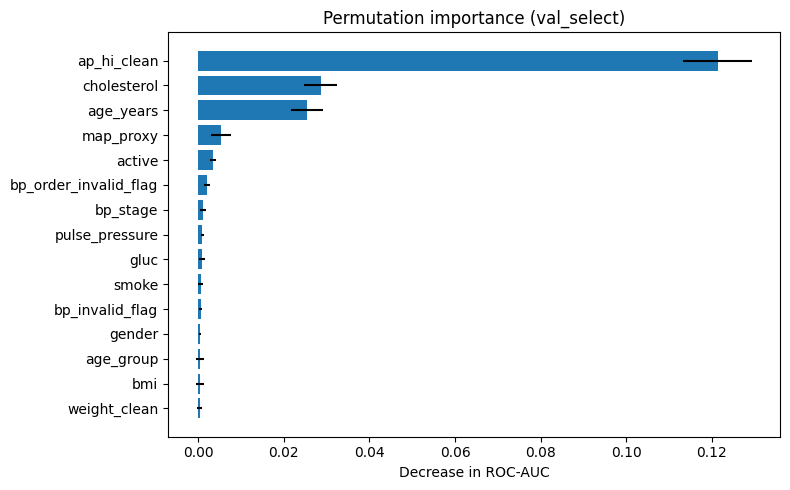

In [42]:
# Permutation importance — chạy trên feature đã engineer (val_select, không test)
perm_n = min(CONFIG["max_permutation_samples"], len(X_val_select))
perm_idx = np.random.default_rng(SEED).choice(len(X_val_select),
                                                size=perm_n, replace=False)
X_perm_raw = X_val_select.iloc[perm_idx].reset_index(drop=True)
y_perm = y_val_select.iloc[perm_idx].reset_index(drop=True)
X_perm_fe = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_perm_raw)

inner_pipe = Pipeline([
    ("preprocess", DIAGNOSTIC_ESTIMATOR.named_steps["preprocess"]),
    ("model",      DIAGNOSTIC_ESTIMATOR.named_steps["model"]),
])

n_repeats = 6 if RUN_MODE == "debug" else (8 if RUN_MODE == "fast" else 15)
print(f"Permutation importance — n_samples={len(X_perm_fe)}, n_repeats={n_repeats}")
perm = permutation_importance(
    inner_pipe, X_perm_fe, y_perm, scoring="roc_auc",
    n_repeats=n_repeats, random_state=SEED, n_jobs=N_JOBS,
)

perm_table = pd.DataFrame({
    "feature": X_perm_fe.columns,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std,
}).sort_values("importance_mean", ascending=False)
save_df(perm_table, TABLE_DIR / "13_permutation_importance.csv")
display(perm_table)

plt.figure(figsize=(8, 5))
top = perm_table.head(15).iloc[::-1]
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Decrease in ROC-AUC"); plt.title("Permutation importance (val_select)")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_permutation_importance.png", dpi=160)
plt.show()

### 18.1b. Stability của feature importance

Một biểu đồ SHAP/permutation trên một split có thể dao động. Cell này kiểm tra độ ổn định thô của top features bằng permutation importance trên nhiều subsample của `val_select`. Đây là bằng chứng bổ sung, không dùng để chọn model hay tune threshold.


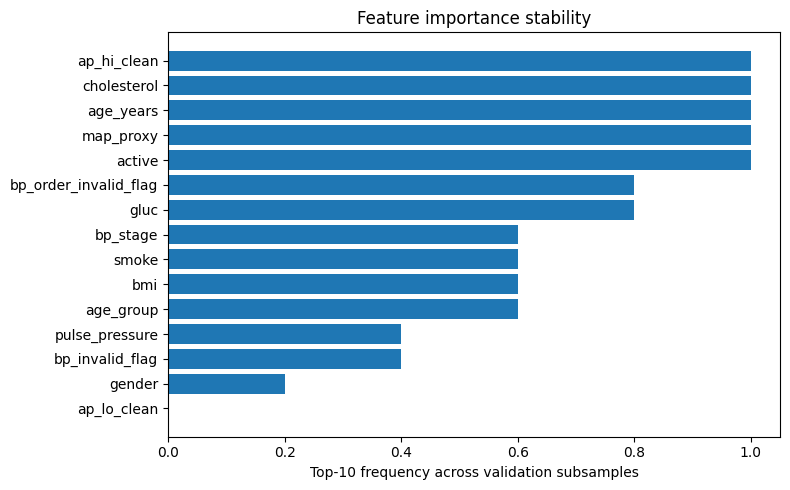

,feature,mean_importance,std_importance,mean_rank,best_rank,worst_rank,top10_frequency,n_rounds
7,ap_hi_clean,1.220631e-01,0.002954,1.0,1,1,1.0,5
15,cholesterol,2.875662e-02,0.004013,2.4,2,3,1.0,5
4,age_years,2.737950e-02,0.002429,2.6,2,3,1.0,5
22,map_proxy,6.649324e-03,0.001460,4.0,4,4,1.0,5
0,active,2.882905e-03,0.000986,5.6,5,8,1.0,5
13,bp_order_invalid_flag,1.847544e-03,0.001058,7.8,6,13,0.8,5
18,gluc,1.427606e-03,0.000937,8.0,5,11,0.8,5
14,bp_stage,1.359259e-03,0.001356,12.0,6,27,0.6,5
24,smoke,6.733812e-04,0.000859,12.6,7,28,0.6,5
9,bmi,7.542602e-04,0.000928,13.2,8,24,0.6,5


In [43]:
# Feature importance stability — repeated permutation on validation subsamples, not on test
stability_status = {"status": "not_run"}
try:
    stability_rounds = 3 if RUN_MODE in ["debug", "fast"] else 5
    stability_n = min(1200 if RUN_MODE in ["debug", "fast"] else 1800, len(X_val_select))
    stability_rows = []
    rng = np.random.default_rng(SEED + 131)

    for round_id in range(stability_rounds):
        idx = rng.choice(len(X_val_select), size=stability_n, replace=False)
        X_stab_raw = X_val_select.iloc[idx].reset_index(drop=True)
        y_stab = y_val_select.iloc[idx].reset_index(drop=True)
        X_stab_fe = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_stab_raw)
        stab_perm = permutation_importance(
            inner_pipe, X_stab_fe, y_stab,
            scoring="roc_auc", n_repeats=3,
            random_state=SEED + round_id, n_jobs=N_JOBS,
        )
        tmp = pd.DataFrame({
            "round": round_id,
            "feature": X_stab_fe.columns,
            "importance_mean": stab_perm.importances_mean,
            "importance_std": stab_perm.importances_std,
        }).sort_values("importance_mean", ascending=False)
        tmp["rank"] = np.arange(1, len(tmp) + 1)
        stability_rows.append(tmp)

    importance_stability = pd.concat(stability_rows, ignore_index=True)
    stability_summary = (
        importance_stability.groupby("feature")
        .agg(
            mean_importance=("importance_mean", "mean"),
            std_importance=("importance_mean", "std"),
            mean_rank=("rank", "mean"),
            best_rank=("rank", "min"),
            worst_rank=("rank", "max"),
            top10_frequency=("rank", lambda s: float((s <= 10).mean())),
            n_rounds=("round", "nunique"),
        )
        .reset_index()
        .sort_values(["top10_frequency", "mean_rank"], ascending=[False, True])
    )
    save_df(importance_stability, TABLE_DIR / "13a_permutation_importance_stability_long.csv")
    save_df(stability_summary, TABLE_DIR / "13a_permutation_importance_stability_summary.csv")

    plt.figure(figsize=(8, 5))
    top_stab = stability_summary.head(15).iloc[::-1]
    plt.barh(top_stab["feature"], top_stab["top10_frequency"])
    plt.xlabel("Top-10 frequency across validation subsamples")
    plt.title("Feature importance stability")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "13a_permutation_importance_stability.png", dpi=160)
    plt.show()

    display(stability_summary.head(20))
    stability_status = {
        "status": "success",
        "rounds": int(stability_rounds),
        "subsample_size": int(stability_n),
        "note": "Computed on val_select only; not used for model/threshold selection.",
    }
except Exception as e:
    stability_status = {"status": "failed", "reason": str(e)}
    print("[IMPORTANCE STABILITY SKIPPED]", e)

save_json(stability_status, TABLE_DIR / "13a_permutation_importance_stability_status.json")


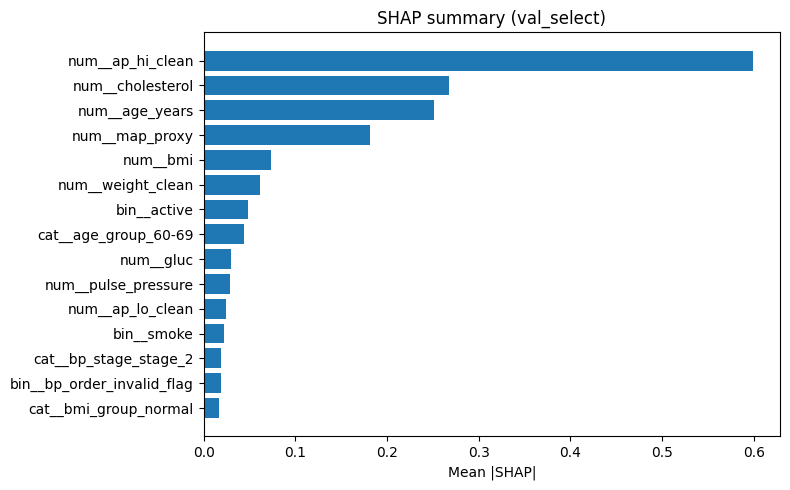

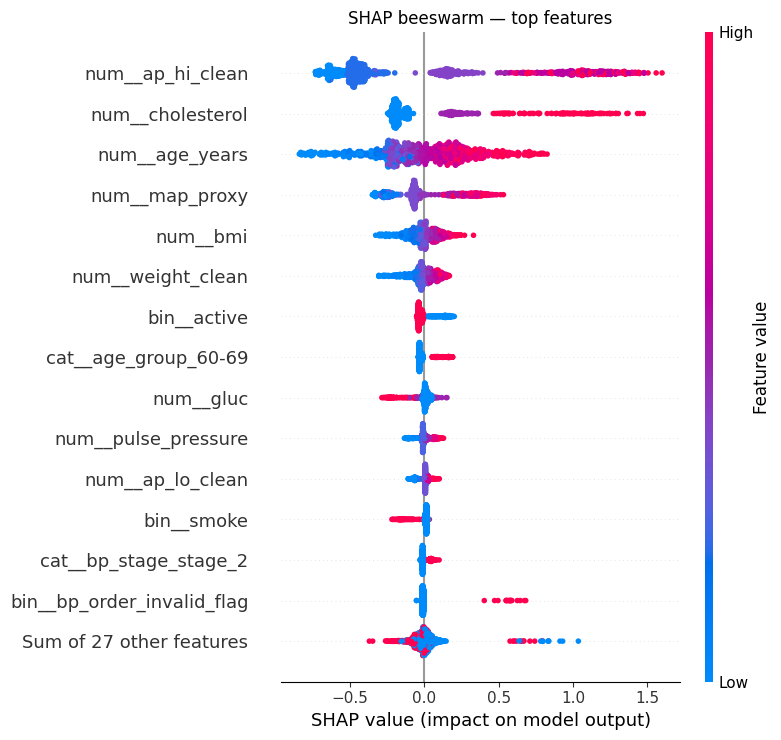

,feature,mean_abs_shap
0,num__ap_hi_clean,0.598562
1,num__cholesterol,0.267479
2,num__age_years,0.251716
3,num__map_proxy,0.181787
4,num__bmi,0.073764
5,num__weight_clean,0.061201
6,bin__active,0.048891
7,cat__age_group_60-69,0.043843
8,num__gluc,0.029440
9,num__pulse_pressure,0.029326


In [44]:
# === SHAP global ===
def get_preprocessed_feature_names(pipe):
    try:
        return pipe.named_steps["preprocess"].get_feature_names_out().tolist()
    except Exception:
        n = pipe.named_steps["preprocess"].transform(
            pipe.named_steps["fe"].transform(X_val_select.head(1))
        ).shape[1]
        return [f"f_{i}" for i in range(n)]


def normalize_shap_values(raw):
    if isinstance(raw, list):
        raw = raw[1] if len(raw) > 1 else raw[0]
    vals = raw.values if hasattr(raw, "values") else raw
    vals = np.asarray(vals)
    if vals.ndim == 3:
        vals = vals[:, :, 1] if vals.shape[-1] == 2 else np.mean(vals, axis=-1)
    if vals.ndim != 2:
        raise ValueError(f"Bad SHAP shape: {vals.shape}")
    return vals


def make_predict_fn(model_step):
    if hasattr(model_step, "predict_proba"):
        return lambda d: sigmoid_clip(model_step.predict_proba(d)[:, 1])
    if hasattr(model_step, "decision_function"):
        return lambda d: sigmoid_clip(expit(model_step.decision_function(d)))
    return lambda d: sigmoid_clip(model_step.predict(d))


shap_status = {"status": "not_run"}
shap_table = None
shap_values_matrix = None
X_shap_used = None
feature_names_proc = None

try:
    import shap
    import scipy.sparse as sp
    shap_n = min(CONFIG["max_shap_samples"], len(X_val_select))
    rng = np.random.default_rng(SEED)
    shap_idx = rng.choice(len(X_val_select), size=shap_n, replace=False)
    X_shap_raw = X_val_select.iloc[shap_idx].reset_index(drop=True)
    X_shap_fe = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_shap_raw)
    X_shap_proc = DIAGNOSTIC_ESTIMATOR.named_steps["preprocess"].transform(X_shap_fe)
    X_shap_proc = X_shap_proc.toarray() if sp.issparse(X_shap_proc) else np.asarray(X_shap_proc)

    feature_names_proc = get_preprocessed_feature_names(DIAGNOSTIC_ESTIMATOR)
    if len(feature_names_proc) != X_shap_proc.shape[1]:
        feature_names_proc = [f"f_{i}" for i in range(X_shap_proc.shape[1])]

    model_step = DIAGNOSTIC_ESTIMATOR.named_steps["model"]
    try:
        explainer = shap.TreeExplainer(model_step)
        raw_vals = explainer.shap_values(X_shap_proc, check_additivity=False)
        shap_values_matrix = normalize_shap_values(raw_vals)
        shap_method = "TreeExplainer"
        X_shap_used = X_shap_proc
    except Exception as tree_err:
        fallback_n = min(250, X_shap_proc.shape[0])
        bg_n = min(100, X_shap_proc.shape[0])
        eval_idx = rng.choice(X_shap_proc.shape[0], size=fallback_n, replace=False)
        bg_idx = rng.choice(X_shap_proc.shape[0], size=bg_n, replace=False)
        X_bg = X_shap_proc[bg_idx]; X_shap_used = X_shap_proc[eval_idx]
        predict_fn = make_predict_fn(model_step)
        explainer = shap.Explainer(predict_fn, X_bg, feature_names=feature_names_proc,
                                     algorithm="permutation")
        raw_vals = explainer(X_shap_used, max_evals=2 * X_shap_used.shape[1] + 1)
        shap_values_matrix = normalize_shap_values(raw_vals)
        shap_method = f"PermutationExplainer (TreeExplainer failed: {tree_err})"

    shap_abs = np.abs(shap_values_matrix).mean(axis=0)
    shap_table = pd.DataFrame({"feature": feature_names_proc,
                                "mean_abs_shap": shap_abs}
                                ).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    save_df(shap_table, TABLE_DIR / "13_shap_importance.csv")

    plt.figure(figsize=(8, 5))
    top = shap_table.head(15).iloc[::-1]
    plt.barh(top["feature"], top["mean_abs_shap"])
    plt.xlabel("Mean |SHAP|"); plt.title("SHAP summary (val_select)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "13_shap_summary_bar.png", dpi=160)
    plt.show()

    try:
        exp_obj = shap.Explanation(values=shap_values_matrix, data=X_shap_used,
                                     feature_names=feature_names_proc)
        shap.plots.beeswarm(exp_obj, max_display=15, show=False)
        plt.title("SHAP beeswarm — top features"); plt.tight_layout()
        plt.savefig(FIG_DIR / "13_shap_beeswarm.png", dpi=160, bbox_inches="tight")
        plt.show()
        beeswarm_status = "success"
    except Exception as e:
        beeswarm_status = f"skipped: {e}"

    shap_status = {"status": "success", "method": shap_method,
                   "n_samples": int(X_shap_used.shape[0]),
                   "n_features": len(feature_names_proc),
                   "beeswarm": beeswarm_status}
    display(shap_table.head(15))
except Exception as e:
    shap_status = {"status": "failed", "reason": str(e)}
    print("[SHAP FAILED]", e)

save_json(shap_status, TABLE_DIR / "13_shap_status.json")

SHAP dependence cho 6 feature top: ['num__ap_hi_clean', 'num__cholesterol', 'num__age_years', 'num__map_proxy', 'num__bmi', 'num__weight_clean']


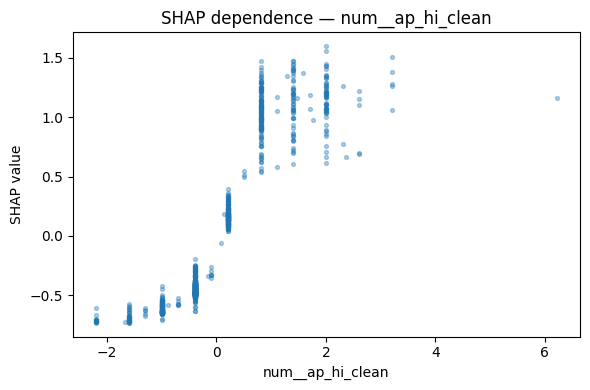

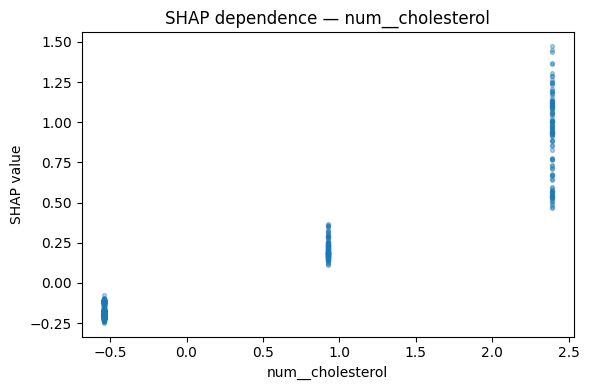

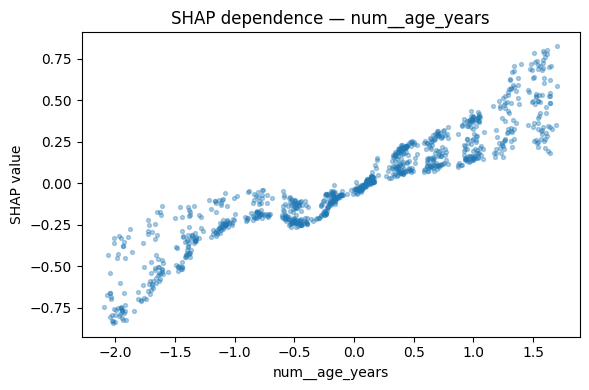

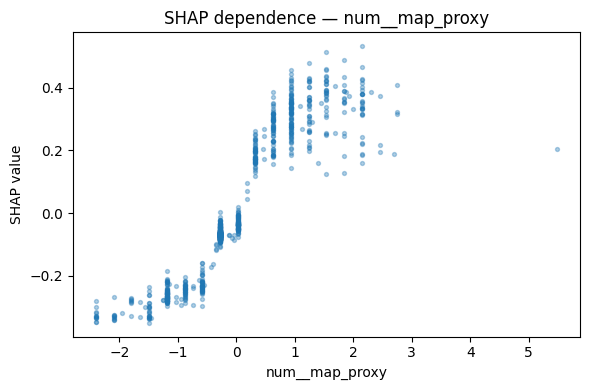

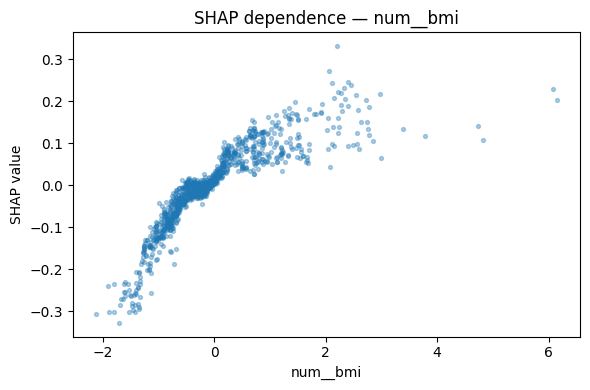

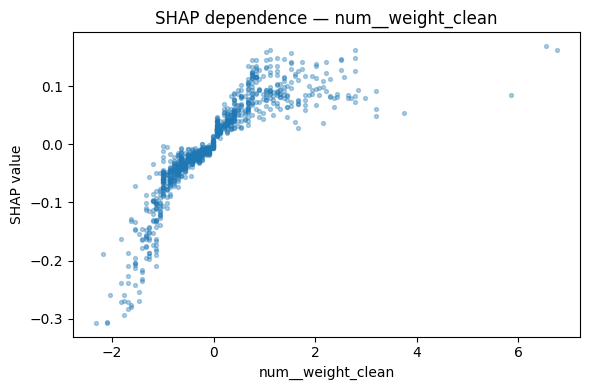

In [ ]:
# SHAP dependence cho top features
if shap_status.get("status") == "success" and shap_table is not None:
    n_dep = CONFIG["n_shap_dependence"]
    dep_features = shap_table[shap_table["mean_abs_shap"] > 0.001
                                ]["feature"].head(n_dep).tolist()
    print(f"SHAP dependence cho {len(dep_features)} feature top: {dep_features}")
    dep_rows = []
    for feature in dep_features:
        if feature not in feature_names_proc:
            continue
        j = feature_names_proc.index(feature)
        plt.figure(figsize=(6, 4))
        plt.scatter(X_shap_used[:, j], shap_values_matrix[:, j], s=8, alpha=0.35)
        plt.xlabel(feature); plt.ylabel("SHAP value")
        plt.title(f"SHAP dependence — {feature}")
        plt.tight_layout()
        safe_name = feature.replace("/", "_").replace(" ", "_")
        plt.savefig(FIG_DIR / f"13c_shap_dep_{safe_name}.png", dpi=160)
        plt.show()
        dep_rows.append({"feature": feature, "n_samples": len(X_shap_used)})
    save_df(pd.DataFrame(dep_rows), TABLE_DIR / "13c_shap_dependence_status.csv")
else:
    save_json({"status": "skipped"}, TABLE_DIR / "13c_shap_dependence_status.json")

In [46]:
# Logistic coefficient + clinical interpretation map
try:
    lr_pipe = tuned_estimators.get("LogisticRegression")
    if lr_pipe is None:
        lr_pipe = build_pipeline(base_models["LogisticRegression"])
        lr_pipe.fit(X_train, y_train)
    lr_feature_names = get_preprocessed_feature_names(lr_pipe)
    lr_coef = np.ravel(lr_pipe.named_steps["model"].coef_)
    lr_coef_table = pd.DataFrame({"feature": lr_feature_names,
                                    "logistic_coef": lr_coef,
                                    "abs_logistic_coef": np.abs(lr_coef)}
                                   ).sort_values("abs_logistic_coef", ascending=False).head(30)
    if shap_status.get("status") == "success" and shap_table is not None:
        compare = lr_coef_table.merge(shap_table.head(30), on="feature", how="outer")
    else:
        compare = lr_coef_table
    save_df(compare, TABLE_DIR / "13d_logistic_vs_final_explainability.csv")
    display(compare.head(20))
except Exception as e:
    save_json({"status": "failed", "reason": str(e)},
              TABLE_DIR / "13d_logistic_vs_final_explainability_status.json")
    print("[LINEAR EXPLAIN SKIPPED]", e)

,feature,logistic_coef,abs_logistic_coef,mean_abs_shap
0,bin__active,-0.200168,0.200168,0.048891
1,bin__alco,-0.135541,0.135541,0.010123
2,bin__bmi_invalid_flag,0.137609,0.137609,NaN
3,bin__bp_invalid_flag,0.208044,0.208044,0.008531
4,bin__bp_order_invalid_flag,1.048623,1.048623,0.018456
5,bin__height_invalid_flag,0.070547,0.070547,NaN
6,bin__smoke,-0.177590,0.177590,0.022665
7,bin__weight_invalid_flag,0.067061,0.067061,NaN
8,cat__age_group_40-49,0.182089,0.182089,0.009257
9,cat__age_group_50-59,-0.089734,0.089734,0.004173


PDP cho 6 feature numeric top: ['ap_hi_clean', 'cholesterol', 'age_years', 'map_proxy', 'pulse_pressure', 'gluc']


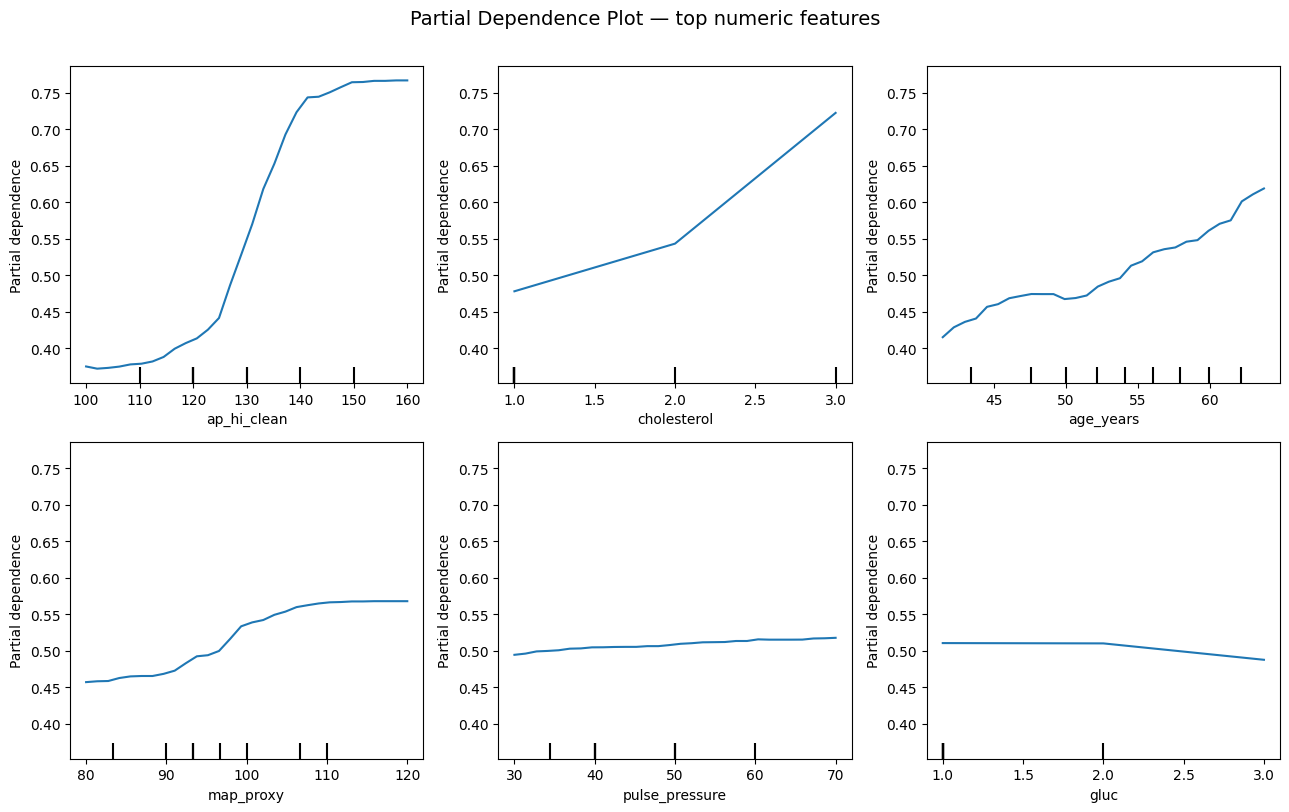

,feature,clinical_meaning,expected_direction,rationale
0,age_years,Tuổi (năm),↑,Tuổi cao là risk factor chính cho CVD theo Fra...
1,ap_hi_clean,Huyết áp tâm thu (mmHg),↑,ap_hi ≥ 140 = stage 2 hypertension theo AHA 2017
2,ap_lo_clean,Huyết áp tâm trương (mmHg),↑,ap_lo ≥ 90 = stage 2 hypertension
3,bmi,Body Mass Index,↑,BMI ≥ 30 (béo phì) tăng risk CVD ~2x
4,pulse_pressure,ap_hi - ap_lo,↑,Pulse pressure rộng (>60 mmHg) liên quan xơ vữ...
5,map_proxy,Mean Arterial Pressure proxy,↑,MAP cao → tổn thương cơ quan đích
6,cholesterol,Cholesterol ordinal 1/2/3,↑,Hyperlipidemia là risk factor được xác nhận
7,gluc,Glucose ordinal 1/2/3,↑,Tiền tiểu đường + tiểu đường tăng risk CVD
8,smoke,Hút thuốc 0/1,↑,Hút thuốc tăng risk CVD ~2-4x
9,active,Vận động 0/1,↓,Vận động đều giảm risk CVD


In [47]:
# Partial Dependence Plot
from sklearn.inspection import PartialDependenceDisplay

top_perm_numeric = perm_table[perm_table["feature"].isin(NUMERIC_FEATURES)].head(6)
pdp_features = top_perm_numeric["feature"].tolist()
print(f"PDP cho {len(pdp_features)} feature numeric top: {pdp_features}")

if pdp_features:
    n_features = len(pdp_features)
    n_cols = 3; n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
    axes = np.atleast_2d(axes).flatten()
    try:
        PartialDependenceDisplay.from_estimator(
            inner_pipe, X_perm_fe, features=pdp_features,
            ax=axes[:n_features], grid_resolution=30, kind="average",
        )
        for ax in axes[n_features:]:
            ax.set_visible(False)
        plt.suptitle("Partial Dependence Plot — top numeric features", fontsize=14, y=1.01)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "13b_pdp.png", dpi=160, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"[SKIP PDP] {type(e).__name__}: {e}")
        save_json({"status": "failed", "reason": str(e)},
                  TABLE_DIR / "13b_pdp_status.json")

# Clinical interpretation map
clinical_map = pd.DataFrame([
    {"feature": "age_years", "clinical_meaning": "Tuổi (năm)", "expected_direction": "↑",
     "rationale": "Tuổi cao là risk factor chính cho CVD theo Framingham"},
    {"feature": "ap_hi_clean", "clinical_meaning": "Huyết áp tâm thu (mmHg)", "expected_direction": "↑",
     "rationale": "ap_hi ≥ 140 = stage 2 hypertension theo AHA 2017"},
    {"feature": "ap_lo_clean", "clinical_meaning": "Huyết áp tâm trương (mmHg)", "expected_direction": "↑",
     "rationale": "ap_lo ≥ 90 = stage 2 hypertension"},
    {"feature": "bmi", "clinical_meaning": "Body Mass Index", "expected_direction": "↑",
     "rationale": "BMI ≥ 30 (béo phì) tăng risk CVD ~2x"},
    {"feature": "pulse_pressure", "clinical_meaning": "ap_hi - ap_lo", "expected_direction": "↑",
     "rationale": "Pulse pressure rộng (>60 mmHg) liên quan xơ vữa động mạch"},
    {"feature": "map_proxy", "clinical_meaning": "Mean Arterial Pressure proxy", "expected_direction": "↑",
     "rationale": "MAP cao → tổn thương cơ quan đích"},
    {"feature": "cholesterol", "clinical_meaning": "Cholesterol ordinal 1/2/3", "expected_direction": "↑",
     "rationale": "Hyperlipidemia là risk factor được xác nhận"},
    {"feature": "gluc", "clinical_meaning": "Glucose ordinal 1/2/3", "expected_direction": "↑",
     "rationale": "Tiền tiểu đường + tiểu đường tăng risk CVD"},
    {"feature": "smoke", "clinical_meaning": "Hút thuốc 0/1", "expected_direction": "↑",
     "rationale": "Hút thuốc tăng risk CVD ~2-4x"},
    {"feature": "active", "clinical_meaning": "Vận động 0/1", "expected_direction": "↓",
     "rationale": "Vận động đều giảm risk CVD"},
])
save_df(clinical_map, TABLE_DIR / "13b_clinical_interpretation_map.csv")
display(clinical_map)

In [48]:
# === Compatibility cell: EDA-minimal artifact cho Notebook 2 ===
# Notebook 2 bỏ qua EDA chi tiết, nhưng mục 18.4 cần corr_target_compare
# để đối chiếu tín hiệu EDA với explainability. Cell này chỉ tính bảng tương quan
# tối thiểu trên TRAIN, không dùng validation/test và không tạo biểu đồ EDA đầy đủ.

if "corr_target_compare" not in globals():
    _eda_fe_min = make_feature_engineer_from_config(CONFIG)
    _eda_df_min = _eda_fe_min.fit_transform(X_train)
    _eda_df_min[TARGET] = y_train.reset_index(drop=True).values

    _corr_features_min = [
        "age_years", "bmi", "ap_hi_clean", "ap_lo_clean",
        "pulse_pressure", "map_proxy", "cholesterol", "gluc", TARGET
    ]
    _corr_spearman_min = _eda_df_min[_corr_features_min].corr(method="spearman")
    _corr_pearson_min = _eda_df_min[_corr_features_min].corr(method="pearson")

    save_df(
        _corr_spearman_min.reset_index().rename(columns={"index": "feature"}),
        TABLE_DIR / "05_train_spearman_correlation_minimal_for_modeling_notebook.csv",
    )
    save_df(
        _corr_pearson_min.reset_index().rename(columns={"index": "feature"}),
        TABLE_DIR / "05_train_pearson_correlation.csv",
    )

    corr_target_compare = pd.DataFrame({
        "feature": [c for c in _corr_features_min if c != TARGET],
        "pearson_with_target": [
            _corr_pearson_min.loc[c, TARGET] for c in _corr_features_min if c != TARGET
        ],
        "spearman_with_target": [
            _corr_spearman_min.loc[c, TARGET] for c in _corr_features_min if c != TARGET
        ],
    }).assign(
        abs_pearson=lambda d: d["pearson_with_target"].abs(),
        abs_spearman=lambda d: d["spearman_with_target"].abs(),
    ).sort_values("abs_spearman", ascending=False)

    save_df(
        corr_target_compare,
        TABLE_DIR / "05_train_correlation_with_target_compare.csv",
    )
    print("Created minimal train-only corr_target_compare for Notebook 2:", corr_target_compare.shape)


Created minimal train-only corr_target_compare for Notebook 2: (8, 5)


### 18.4. Đối chiếu EDA với explainability



In [49]:
# EDA vs model explanation alignment
def base_feature_name(feature_name: str) -> str:
    """Map preprocessed feature names like num__age_years / cat__gender_2 to base feature."""
    name = str(feature_name)
    if "__" in name:
        name = name.split("__", 1)[1]
    # One-hot names
    for prefix in ["gender_", "bp_stage_", "bmi_group_", "age_group_"]:
        if name.startswith(prefix):
            return prefix[:-1]
    return name

# Permutation rank by engineered feature
perm_rank = perm_table.reset_index(drop=True).copy()
perm_rank["perm_rank"] = np.arange(1, len(perm_rank) + 1)
perm_rank["base_feature"] = perm_rank["feature"].map(base_feature_name)
perm_base = (
    perm_rank.groupby("base_feature")
    .agg(perm_best_rank=("perm_rank", "min"),
         perm_importance_mean=("importance_mean", "max"))
    .reset_index()
)

# SHAP rank by preprocessed/base feature if available
if shap_table is not None and isinstance(shap_table, pd.DataFrame) and not shap_table.empty:
    shap_rank = shap_table.reset_index(drop=True).copy()
    shap_rank["shap_rank"] = np.arange(1, len(shap_rank) + 1)
    shap_rank["base_feature"] = shap_rank["feature"].map(base_feature_name)
    shap_base = (
        shap_rank.groupby("base_feature")
        .agg(shap_best_rank=("shap_rank", "min"),
             mean_abs_shap=("mean_abs_shap", "max"))
        .reset_index()
    )
else:
    shap_base = pd.DataFrame(columns=["base_feature", "shap_best_rank", "mean_abs_shap"])

# EDA evidence: Spearman/Pearson with target where available
eda_corr = corr_target_compare.rename(columns={"feature": "base_feature"}).copy()
eda_corr["eda_evidence"] = eda_corr.apply(
    lambda r: f"Spearman={r['spearman_with_target']:.3f}; Pearson={r['pearson_with_target']:.3f}",
    axis=1,
)

alignment_features = [
    "age_years", "ap_hi_clean", "ap_lo_clean", "pulse_pressure", "map_proxy",
    "bmi", "cholesterol", "gluc", "gender", "smoke", "alco", "active",
    "bp_stage", "age_group", "bmi_group",
]
alignment = pd.DataFrame({"base_feature": alignment_features})
alignment = alignment.merge(eda_corr[["base_feature", "eda_evidence", "spearman_with_target", "pearson_with_target"]],
                            on="base_feature", how="left")
alignment = alignment.merge(perm_base, on="base_feature", how="left")
alignment = alignment.merge(shap_base, on="base_feature", how="left")
alignment["evidence_alignment"] = np.select(
    [
        alignment["spearman_with_target"].abs().fillna(0).ge(0.03) &
        alignment["perm_best_rank"].fillna(999).le(10) &
        alignment["shap_best_rank"].fillna(999).le(15),
        alignment["perm_best_rank"].fillna(999).le(10) |
        alignment["shap_best_rank"].fillna(999).le(15),
    ],
    [
        "EDA + permutation + SHAP broadly agree",
        "Model explanation suggests signal; EDA evidence weak/mixed",
    ],
    default="Weak or inconsistent evidence",
)
alignment["interpretation_rule"] = (
    "Use as associative predictive evidence only; do not infer causality."
)
alignment = alignment.sort_values(
    ["evidence_alignment", "perm_best_rank", "shap_best_rank"],
    ascending=[True, True, True],
    na_position="last",
)
save_df(alignment, TABLE_DIR / "13e_eda_model_explanation_alignment.csv")
display(alignment)


,base_feature,eda_evidence,spearman_with_target,pearson_with_target,perm_best_rank,perm_importance_mean,shap_best_rank,mean_abs_shap,evidence_alignment,interpretation_rule
1,ap_hi_clean,Spearman=0.452; Pearson=0.426,0.452415,0.426371,1,0.121329,1,0.598562,EDA + permutation + SHAP broadly agree,Use as associative predictive evidence only; d...
6,cholesterol,Spearman=0.221; Pearson=0.226,0.220502,0.225813,2,0.028595,2,0.267479,EDA + permutation + SHAP broadly agree,Use as associative predictive evidence only; d...
0,age_years,Spearman=0.235; Pearson=0.238,0.234653,0.238109,3,0.025488,3,0.251716,EDA + permutation + SHAP broadly agree,Use as associative predictive evidence only; d...
4,map_proxy,Spearman=0.434; Pearson=0.409,0.433518,0.408818,4,0.005345,4,0.181787,EDA + permutation + SHAP broadly agree,Use as associative predictive evidence only; d...
3,pulse_pressure,Spearman=0.358; Pearson=0.334,0.357700,0.334254,8,0.000971,10,0.029326,EDA + permutation + SHAP broadly agree,Use as associative predictive evidence only; d...
7,gluc,Spearman=0.093; Pearson=0.090,0.093033,0.090248,9,0.000964,9,0.029440,EDA + permutation + SHAP broadly agree,Use as associative predictive evidence only; d...
11,active,NaN,NaN,NaN,5,0.003556,7,0.048891,Model explanation suggests signal; EDA evidenc...,Use as associative predictive evidence only; d...
12,bp_stage,NaN,NaN,NaN,7,0.001215,13,0.019020,Model explanation suggests signal; EDA evidenc...,Use as associative predictive evidence only; d...
9,smoke,NaN,NaN,NaN,10,0.000649,12,0.022665,Model explanation suggests signal; EDA evidenc...,Use as associative predictive evidence only; d...
13,age_group,NaN,NaN,NaN,13,0.000467,8,0.043843,Model explanation suggests signal; EDA evidenc...,Use as associative predictive evidence only; d...


## 19. Error analysis + Subgroup + Calibration theo subgroup + Fairness

Trong screening tim mạch, **False Negative** đặc biệt nguy hiểm. Phần này:
- Profile FP/FN/TP/TN
- Subgroup metrics 9 chiều
- **Calibration theo subgroup** (model có thể calibrate tốt tổng thể nhưng lệch ở subgroup)
- **Fairness metrics:** equal opportunity diff, demographic parity diff theo gender

In [50]:
test_analysis = X_test.copy()
test_analysis["y_true"] = y_test.values
test_analysis["y_prob"] = p_test
test_analysis["y_pred"] = y_test_pred
test_analysis["error_type"] = np.select(
    [
        (test_analysis["y_true"] == 1) & (test_analysis["y_pred"] == 1),
        (test_analysis["y_true"] == 0) & (test_analysis["y_pred"] == 0),
        (test_analysis["y_true"] == 1) & (test_analysis["y_pred"] == 0),
        (test_analysis["y_true"] == 0) & (test_analysis["y_pred"] == 1),
    ], ["TP", "TN", "FN", "FP"], default="Unknown",
)

# Bổ sung feature engineered để profile
test_analysis_fe = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_test)
clinical_cols = ["age_years", "bmi", "height_clean", "weight_clean",
                 "ap_hi_clean", "ap_lo_clean", "pulse_pressure", "map_proxy",
                 "bp_stage", "bmi_group", "age_group"]
for col in clinical_cols:
    if col in test_analysis_fe.columns:
        test_analysis[col] = test_analysis_fe[col].values
for col in ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]:
    if col in X_test.columns and col not in test_analysis.columns:
        test_analysis[col] = X_test[col].values

error_summary = (
    test_analysis["error_type"].value_counts()
    .reindex(["TP", "TN", "FP", "FN"]).dropna().reset_index()
)
error_summary.columns = ["error_type", "count"]
error_summary["ratio"] = error_summary["count"] / len(test_analysis)
save_df(error_summary, TABLE_DIR / "14_error_summary_test.csv")
display(error_summary)

# Profile numeric per error_type
profile_cols = ["age_years", "bmi", "ap_hi_clean", "ap_lo_clean",
                "pulse_pressure", "map_proxy", "cholesterol", "gluc", "y_prob"]
profile_cols = [c for c in profile_cols if c in test_analysis.columns]
err_profile_num = (
    test_analysis.groupby("error_type")[profile_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)
err_profile_num.columns = ["_".join([str(x) for x in col if str(x)])
                             for col in err_profile_num.columns]
err_profile_num = err_profile_num.reset_index()
save_df(err_profile_num, TABLE_DIR / "14_error_profile_numeric_test.csv")
display(err_profile_num)

fn_cases = test_analysis[test_analysis["error_type"] == "FN"].sort_values("y_prob").head(30)
fp_cases = test_analysis[test_analysis["error_type"] == "FP"].sort_values("y_prob", ascending=False).head(30)
save_df(fn_cases, TABLE_DIR / "14_top_fn_cases_test.csv")
save_df(fp_cases, TABLE_DIR / "14_top_fp_cases_test.csv")
print(f"\nTop 30 FN (xác suất thấp nhất):  saved")
print(f"Top 30 FP (xác suất cao nhất): saved")

,error_type,count,ratio
0,TP,4090,0.4090
1,TN,3071,0.3071
2,FP,1932,0.1932
3,FN,907,0.0907


,error_type,age_years_count,age_years_mean,age_years_median,age_years_std,age_years_min,age_years_max,bmi_count,bmi_mean,bmi_median,...,gluc_median,gluc_std,gluc_min,gluc_max,y_prob_count,y_prob_mean,y_prob_median,y_prob_std,y_prob_min,y_prob_max
0,FN,907,50.533252,51.430527,5.089942,39.299110,61.932923,906,25.718900,24.883304,...,1.0,0.414174,1,3,907,0.265090,0.272328,0.067179,0.077263,0.364712
1,FP,1932,56.507836,57.693361,5.527263,39.107461,64.793977,1928,28.258160,27.470260,...,1.0,0.662214,1,3,1932,0.566609,0.521307,0.158607,0.365017,0.908391
2,TN,3071,48.761813,49.675565,5.706343,39.101985,63.953457,3068,25.165603,24.524346,...,1.0,0.344489,1,3,3071,0.225648,0.231393,0.079180,0.045346,0.364951
3,TP,4090,55.795238,56.669405,6.199727,39.216975,64.889802,4085,29.002262,28.055706,...,1.0,0.672621,1,3,4090,0.713667,0.794777,0.156226,0.365451,0.949409



Top 30 FN (xác suất thấp nhất):  saved
Top 30 FP (xác suất cao nhất): saved


In [51]:
# === SHAP waterfall cho 5 FN + 5 FP ===
local_shap_status = {"status": "not_run"}
try:
    import shap
    import scipy.sparse as sp

    case_indices = list(fn_cases.index[:5]) + list(fp_cases.index[:5])
    case_types = ["FN"] * min(5, len(fn_cases)) + ["FP"] * min(5, len(fp_cases))

    if not case_indices:
        raise ValueError("Không có FP/FN để giải thích.")

    X_local_raw = X_test.iloc[case_indices].reset_index(drop=True)
    X_local_fe = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_local_raw)
    X_local_proc = DIAGNOSTIC_ESTIMATOR.named_steps["preprocess"].transform(X_local_fe)
    X_local_proc = X_local_proc.toarray() if sp.issparse(X_local_proc) else np.asarray(X_local_proc)

    bg_n = min(200, len(X_val_select))
    bg_idx = np.random.default_rng(SEED).choice(len(X_val_select), size=bg_n, replace=False)
    X_bg_fe = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_val_select.iloc[bg_idx].reset_index(drop=True))
    X_bg_proc = DIAGNOSTIC_ESTIMATOR.named_steps["preprocess"].transform(X_bg_fe)
    X_bg_proc = X_bg_proc.toarray() if sp.issparse(X_bg_proc) else np.asarray(X_bg_proc)

    fnames = get_preprocessed_feature_names(DIAGNOSTIC_ESTIMATOR)
    if len(fnames) != X_local_proc.shape[1]:
        fnames = [f"f_{i}" for i in range(X_local_proc.shape[1])]

    model_step = DIAGNOSTIC_ESTIMATOR.named_steps["model"]
    try:
        explainer = shap.TreeExplainer(model_step)
        raw_vals = explainer.shap_values(X_local_proc, check_additivity=False)
        local_values = normalize_shap_values(raw_vals)
        bv = explainer.expected_value
        base_value = float(np.asarray(bv).ravel()[-1] if isinstance(bv, (list, np.ndarray))
                            else bv)
        local_method = "TreeExplainer"
    except Exception as e:
        explainer = shap.Explainer(make_predict_fn(model_step), X_bg_proc,
                                     feature_names=fnames, algorithm="permutation")
        raw_vals = explainer(X_local_proc, max_evals=2 * X_local_proc.shape[1] + 1)
        local_values = normalize_shap_values(raw_vals)
        base_value = float(np.asarray(raw_vals.base_values).ravel()[0])                        if hasattr(raw_vals, "base_values") else 0.0
        local_method = f"PermutationExplainer (TreeExplainer failed: {e})"

    local_rows = []
    for i, orig_idx in enumerate(case_indices):
        vals = local_values[i]
        top_ids = np.argsort(np.abs(vals))[::-1][:10]
        for rank, fid in enumerate(top_ids, start=1):
            local_rows.append({
                "case_rank": i + 1, "original_test_index": int(orig_idx),
                "error_type": case_types[i],
                "y_true": int(y_test.iloc[orig_idx]),
                "y_pred": int(y_test_pred[orig_idx]),
                "y_prob": float(p_test[orig_idx]),
                "feature_rank": rank, "feature": fnames[fid],
                "shap_value": float(vals[fid]),
                "abs_shap_value": float(abs(vals[fid])),
            })
        try:
            exp = shap.Explanation(values=vals, base_values=base_value,
                                     data=X_local_proc[i], feature_names=fnames)
            shap.plots.waterfall(exp, max_display=12, show=False)
            plt.title(f"SHAP waterfall — {case_types[i]} case #{i+1}")
            plt.tight_layout()
            plt.savefig(FIG_DIR / f"14b_shap_waterfall_{case_types[i]}_{i+1}.png",
                        dpi=160, bbox_inches="tight")
            plt.close()
        except Exception as plot_err:
            print(f"  [WARN] waterfall case {i+1}: {plot_err}")

    local_shap_cases = pd.DataFrame(local_rows)
    save_df(local_shap_cases, TABLE_DIR / "14b_shap_fp_fn_local.csv")
    local_shap_status = {"status": "success", "method": local_method,
                          "n_cases": len(case_indices)}
    display(local_shap_cases.head(30))
except Exception as e:
    local_shap_status = {"status": "failed", "reason": str(e)}
    print("[LOCAL SHAP SKIPPED]", e)

save_json(local_shap_status, TABLE_DIR / "14b_shap_fp_fn_local_status.json")

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_math

,case_rank,original_test_index,error_type,y_true,y_pred,y_prob,feature_rank,feature,shap_value,abs_shap_value
0,1,3617,FN,1,0,0.077263,1,num__ap_hi_clean,-0.721024,0.721024
1,1,3617,FN,1,0,0.077263,2,num__map_proxy,-0.344970,0.344970
2,1,3617,FN,1,0,0.077263,3,num__bmi,-0.294683,0.294683
3,1,3617,FN,1,0,0.077263,4,num__weight_clean,-0.292350,0.292350
4,1,3617,FN,1,0,0.077263,5,num__age_years,-0.209698,0.209698
5,1,3617,FN,1,0,0.077263,6,num__cholesterol,-0.193001,0.193001
6,1,3617,FN,1,0,0.077263,7,num__pulse_pressure,-0.128151,0.128151
7,1,3617,FN,1,0,0.077263,8,num__ap_lo_clean,-0.106470,0.106470
8,1,3617,FN,1,0,0.077263,9,cat__bp_stage_normal,-0.066038,0.066038
9,1,3617,FN,1,0,0.077263,10,cat__age_group_60-69,-0.036599,0.036599


In [52]:
# SHAP quality gate: không silent fail.
shap_quality_gate = {
    "global_shap_status": shap_status,
    "local_shap_status": local_shap_status,
    "global_success": shap_status.get("status") == "success",
    "local_success": local_shap_status.get("status") == "success",
    "required_for_final": bool(CONFIG.get("require_shap_for_final", False)),
}
shap_quality_gate["overall_status"] = (
    "success" if shap_quality_gate["global_success"] and shap_quality_gate["local_success"]
    else "warning"
)
save_json(shap_quality_gate, TABLE_DIR / "18_shap_quality_gate.json")
if shap_quality_gate["overall_status"] != "success":
    print("[CRITICAL WARNING] SHAP chưa đủ artifact 9+.")
    print("Global SHAP:", shap_status)
    print("Local SHAP:", local_shap_status)
    if CONFIG.get("require_shap_for_final", False) and RUN_MODE in {"final", "kaggle_long"}:
        raise RuntimeError("SHAP artifact required for final mode but not successful. See tables/18_shap_quality_gate.json")
else:
    print("SHAP quality gate: PASS — có cả global và local explanation artifacts.")


SHAP quality gate: PASS — có cả global và local explanation artifacts.


In [53]:
# === Subgroup metrics (đã có ở phần cũ) ===
def subgroup_metrics(df_eval: pd.DataFrame, group_col: str):
    rows = []
    for level, sub in df_eval.groupby(group_col, dropna=False):
        if len(sub) < 30 or sub["y_true"].nunique() < 2:
            continue
        rows.append({
            "group_feature": group_col,
            "group_level": str(level),
            "n": len(sub), "positive_rate": float(sub["y_true"].mean()),
            "roc_auc": float(roc_auc_score(sub["y_true"], sub["y_prob"])),
            "pr_auc": float(average_precision_score(sub["y_true"], sub["y_prob"])),
            **binary_metrics_at_threshold(sub["y_true"], sub["y_prob"], BEST_THRESHOLD),
        })
    return pd.DataFrame(rows)


subgroup_tables = []
for col in ["gender", "age_group", "bmi_group", "bp_stage",
            "cholesterol", "gluc", "smoke", "alco", "active"]:
    if col in test_analysis.columns:
        subgroup_tables.append(subgroup_metrics(test_analysis, col))
subgroup_result = pd.concat(subgroup_tables, ignore_index=True) if subgroup_tables else pd.DataFrame()
save_df(subgroup_result, TABLE_DIR / "15_subgroup_analysis_test.csv")
display(subgroup_result)

,group_feature,group_level,n,positive_rate,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,precision_ppv,...,npv,fpr,fnr,predicted_positive_rate,f1,f2,tn,fp,fn,tp
0,gender,1,6419,0.495404,0.812203,0.797570,0.365,0.722387,0.723308,0.682031,...,0.782474,0.376968,0.176415,0.598224,0.746154,0.790761,2018,1221,561,2619
1,gender,2,3581,0.507400,0.801305,0.803274,0.365,0.704831,0.703258,0.674152,...,0.752680,0.403061,0.190424,0.609327,0.735684,0.778307,1053,711,346,1471
2,age_group,40-49,2782,0.388929,0.835203,0.792825,0.365,0.787563,0.764860,0.760339,...,0.801523,0.132941,0.337338,0.338965,0.708148,0.680137,1474,226,365,717
3,age_group,50-59,5130,0.512281,0.768872,0.769960,0.365,0.678752,0.675550,0.650491,...,0.727855,0.454836,0.194064,0.634698,0.719918,0.769175,1364,1138,510,2118
4,age_group,60-69,1818,0.673267,0.737707,0.837803,0.365,0.688669,0.528768,0.686297,...,0.769231,0.932660,0.009804,0.971397,0.810702,0.909637,40,554,12,1212
5,age_group,<40,270,0.233333,0.885630,0.798356,0.365,0.874074,0.807453,0.754386,...,0.906103,0.067633,0.317460,0.211111,0.716667,0.695793,193,14,20,43
6,bmi_group,normal,3714,0.406300,0.795412,0.744926,0.365,0.725902,0.721155,0.652579,...,0.781948,0.253515,0.304175,0.433226,0.673509,0.686723,1646,559,459,1050
7,bmi_group,obese_I,1810,0.617127,0.796893,0.837634,0.365,0.717680,0.657605,0.711003,...,0.743316,0.598846,0.085944,0.793370,0.799843,0.864668,278,415,96,1021
8,bmi_group,obese_II_plus,821,0.689403,0.766209,0.857662,0.365,0.740560,0.604978,0.739484,...,0.750000,0.752941,0.037102,0.897686,0.836531,0.908031,63,192,21,545
9,bmi_group,overweight,3552,0.499155,0.794954,0.790220,0.365,0.698480,0.698685,0.659112,...,0.763001,0.422709,0.179921,0.621059,0.730837,0.781889,1027,752,319,1454


,group_feature,group_level,n,positive_rate,roc_auc,pr_auc,brier,log_loss,ece_10
0,gender,1,6419,0.495404,0.812203,0.797570,0.175472,0.529031,0.017328
1,gender,2,3581,0.507400,0.801305,0.803274,0.180724,0.540278,0.024994
2,age_group,40-49,2782,0.388929,0.835203,0.792825,0.150561,0.471139,0.025697
3,age_group,50-59,5130,0.512281,0.768872,0.769960,0.193294,0.570852,0.011887
4,age_group,60-69,1818,0.673267,0.737707,0.837803,0.185429,0.551029,0.022199
5,age_group,<40,270,0.233333,0.885630,0.798356,0.096136,0.331964,0.055492
6,bmi_group,normal,3714,0.406300,0.795412,0.744926,0.176444,0.530216,0.016068
7,bmi_group,obese_I,1810,0.617127,0.796893,0.837634,0.173179,0.524632,0.028610
8,bmi_group,obese_II_plus,821,0.689403,0.766209,0.857662,0.168036,0.512148,0.034174
9,bmi_group,overweight,3552,0.499155,0.794954,0.790220,0.183429,0.547397,0.020462


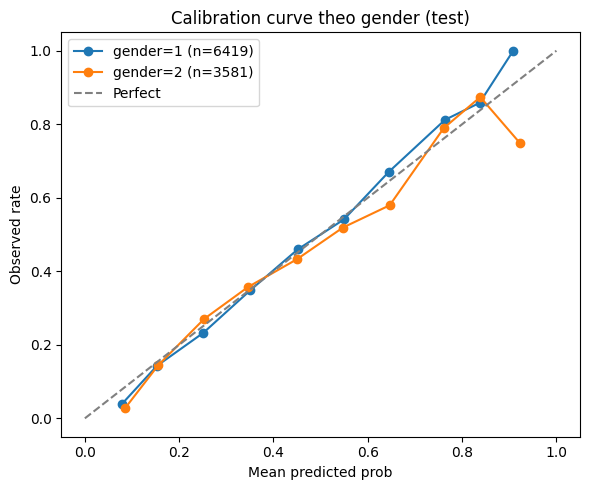

Insight: nếu các đường lệch nhau nhiều → calibration không công bằng theo subgroup.


In [54]:
# === Calibration theo subgroup ===
def subgroup_calibration(df_eval, group_col):
    rows = []
    for level, sub in df_eval.groupby(group_col, dropna=False):
        if len(sub) < 50 or sub["y_true"].nunique() < 2:
            continue
        m = probability_metrics(sub["y_true"].values, sub["y_prob"].values)
        rows.append({"group_feature": group_col, "group_level": str(level),
                     "n": len(sub), "positive_rate": float(sub["y_true"].mean()),
                     **m})
    return pd.DataFrame(rows)


subgroup_calib_rows = []
for col in ["gender", "age_group", "bmi_group", "bp_stage"]:
    if col in test_analysis.columns:
        subgroup_calib_rows.append(subgroup_calibration(test_analysis, col))
subgroup_calib = pd.concat(subgroup_calib_rows, ignore_index=True) if subgroup_calib_rows else pd.DataFrame()
save_df(subgroup_calib, TABLE_DIR / "15b_subgroup_calibration_test.csv")
display(subgroup_calib)

# Calibration curve theo gender
if "gender" in test_analysis.columns and len(test_analysis) > 100:
    plt.figure(figsize=(6, 5))
    for level, sub in test_analysis.groupby("gender"):
        if len(sub) < 100:
            continue
        ct = calibration_table(sub["y_true"].values, sub["y_prob"].values, n_bins=10)
        valid = ct[ct["n"] > 0]
        plt.plot(valid["mean_pred"], valid["observed_rate"],
                 marker="o", label=f"gender={level} (n={len(sub)})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
    plt.xlabel("Mean predicted prob"); plt.ylabel("Observed rate")
    plt.title("Calibration curve theo gender (test)")
    plt.legend(); plt.tight_layout()
    plt.savefig(FIG_DIR / "15b_calibration_by_gender.png", dpi=160)
    plt.show()
    print("Insight: nếu các đường lệch nhau nhiều → calibration không công bằng theo subgroup.")

In [55]:
# === Fairness metrics: equal opportunity + demographic parity ===
def fairness_diff(df_eval, group_col):
    """Theo Hardt 2016: Equal opportunity = Recall(group A) vs Recall(group B)."""
    rows = []
    levels = df_eval[group_col].dropna().unique()
    for lv in levels:
        sub = df_eval[df_eval[group_col] == lv]
        if len(sub) < 50 or sub["y_true"].nunique() < 2:
            continue
        m = binary_metrics_at_threshold(sub["y_true"], sub["y_prob"], BEST_THRESHOLD)
        rows.append({
            "group_feature": group_col, "group_level": str(lv), "n": len(sub),
            "selection_rate":      m["predicted_positive_rate"],  # demographic parity
            "true_positive_rate":  m["recall_sensitivity"],       # equal opportunity
            "false_positive_rate": m["fpr"],
            "precision":           m["precision_ppv"],
        })
    df = pd.DataFrame(rows)
    if len(df) >= 2:
        for metric in ["selection_rate", "true_positive_rate",
                       "false_positive_rate", "precision"]:
            df[f"{metric}_diff_max_minus_min"] = df[metric].max() - df[metric].min()
    return df


fairness_rows = []
for col in ["gender", "age_group", "bmi_group", "bp_stage"]:
    if col in test_analysis.columns:
        fairness_rows.append(fairness_diff(test_analysis, col))
fairness_table = pd.concat(fairness_rows, ignore_index=True) if fairness_rows else pd.DataFrame()
save_df(fairness_table, TABLE_DIR / "15c_fairness_metrics_test.csv")
display(fairness_table)

# Tóm tắt: gap lớn nhất (>10%) cảnh báo fairness concern
fairness_summary_rows = []
for col in ["gender", "age_group", "bmi_group", "bp_stage"]:
    sub = fairness_table[fairness_table["group_feature"] == col]
    if len(sub) < 2:
        continue
    fairness_summary_rows.append({
        "group_feature": col,
        "max_TPR_diff (equal opportunity)":
            float(sub["true_positive_rate_diff_max_minus_min"].iloc[0])
            if "true_positive_rate_diff_max_minus_min" in sub.columns else np.nan,
        "max_selection_rate_diff (dem. parity)":
            float(sub["selection_rate_diff_max_minus_min"].iloc[0])
            if "selection_rate_diff_max_minus_min" in sub.columns else np.nan,
    })
fairness_summary = pd.DataFrame(fairness_summary_rows)
save_df(fairness_summary, TABLE_DIR / "15c_fairness_summary.csv")
display(fairness_summary)
print("Quy ước: gap > 0.10 (10%) thường được xem là cảnh báo fairness.")

,group_feature,group_level,n,selection_rate,true_positive_rate,false_positive_rate,precision,selection_rate_diff_max_minus_min,true_positive_rate_diff_max_minus_min,false_positive_rate_diff_max_minus_min,precision_diff_max_minus_min
0,gender,1,6419,0.598224,0.823585,0.376968,0.682031,0.011103,0.014009,0.026093,0.007879
1,gender,2,3581,0.609327,0.809576,0.403061,0.674152,0.011103,0.014009,0.026093,0.007879
2,age_group,<40,270,0.211111,0.682540,0.067633,0.754386,0.760286,0.327534,0.865027,0.109848
3,age_group,50-59,5130,0.634698,0.805936,0.454836,0.650491,0.760286,0.327534,0.865027,0.109848
4,age_group,60-69,1818,0.971397,0.990196,0.932660,0.686297,0.760286,0.327534,0.865027,0.109848
5,age_group,40-49,2782,0.338965,0.662662,0.132941,0.760339,0.760286,0.327534,0.865027,0.109848
6,bmi_group,overweight,3552,0.621059,0.820079,0.422709,0.659112,0.619908,0.385974,0.596691,0.139484
7,bmi_group,normal,3714,0.433226,0.695825,0.253515,0.652579,0.619908,0.385974,0.596691,0.139484
8,bmi_group,obese_II_plus,821,0.897686,0.962898,0.752941,0.739484,0.619908,0.385974,0.596691,0.139484
9,bmi_group,obese_I,1810,0.793370,0.914056,0.598846,0.711003,0.619908,0.385974,0.596691,0.139484


,group_feature,max_TPR_diff (equal opportunity),max_selection_rate_diff (dem. parity)
0,gender,0.014009,0.011103
1,age_group,0.327534,0.760286
2,bmi_group,0.385974,0.619908
3,bp_stage,0.685358,0.861015


Quy ước: gap > 0.10 (10%) thường được xem là cảnh báo fairness.


## 20. Robustness studies

- **20.1 Ablation:** chứng minh feature engineering thực sự hữu ích.
- **20.2 Cleaning sensitivity:** thay 3 ngưỡng plausibility, kiểm tra metric ổn định.
- **20.3 Multi-seed robustness:** chạy CV với 3 seed khác nhau.
- **20.4 Cost-sensitive threshold:** tối ưu threshold theo cost matrix `cost(FN) = 5 × cost(FP)`.

### 20.1. Ablation study

[ABLATION] LogisticRegression_control | raw
[ABLATION] LogisticRegression_control | raw_plus_age
[ABLATION] LogisticRegression_control | raw_plus_bmi
[ABLATION] LogisticRegression_control | raw_plus_bmi_pp_map
[ABLATION] LogisticRegression_control | full
[ABLATION] FinalModel_CatBoost | raw
[ABLATION] FinalModel_CatBoost | raw_plus_age
[ABLATION] FinalModel_CatBoost | raw_plus_bmi
[ABLATION] FinalModel_CatBoost | raw_plus_bmi_pp_map
[ABLATION] FinalModel_CatBoost | full


,model_family,feature_set,cv_protocol,elapsed_sec,accuracy_mean,accuracy_std,recall_mean,recall_std,precision_mean,precision_std,...,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,delta_accuracy_vs_raw,delta_recall_vs_raw,delta_precision_vs_raw,delta_f1_vs_raw,delta_roc_auc_vs_raw,delta_pr_auc_vs_raw
8,FinalModel_CatBoost,raw_plus_bmi_pp_map,StratifiedGroupKFold,14.1,0.736305,0.005317,0.697133,0.007343,0.756103,0.005462,...,0.803343,0.003193,0.788457,0.003898,0.000422,-0.000400,0.000919,0.000206,0.000179,0.000948
5,FinalModel_CatBoost,raw,StratifiedGroupKFold,13.2,0.735882,0.005676,0.697533,0.007698,0.755183,0.005717,...,0.803164,0.003576,0.787509,0.004850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,FinalModel_CatBoost,raw_plus_age,StratifiedGroupKFold,13.2,0.735482,0.005668,0.698599,0.008312,0.753941,0.005481,...,0.803154,0.003469,0.787343,0.004427,-0.000400,0.001066,-0.001242,-0.000001,-0.000010,-0.000166
7,FinalModel_CatBoost,raw_plus_bmi,StratifiedGroupKFold,13.7,0.736283,0.004945,0.700247,0.006787,0.754349,0.005031,...,0.803269,0.003414,0.787132,0.004909,0.000400,0.002714,-0.000834,0.001078,0.000105,-0.000377
9,FinalModel_CatBoost,full,StratifiedGroupKFold,14.6,0.735193,0.005743,0.697932,0.007840,0.753840,0.005849,...,0.801564,0.003764,0.784602,0.005737,-0.000689,0.000400,-0.001343,-0.000405,-0.001600,-0.002908
4,LogisticRegression_control,full,StratifiedGroupKFold,8.7,0.728349,0.005592,0.665116,0.006662,0.761101,0.006382,...,0.794015,0.005003,0.774075,0.005615,0.006156,-0.011871,0.017085,0.000968,0.008505,0.008531
3,LogisticRegression_control,raw_plus_bmi_pp_map,StratifiedGroupKFold,8.2,0.722794,0.007223,0.677832,0.007801,0.744544,0.008781,...,0.785642,0.006558,0.765768,0.006201,0.000600,0.000845,0.000528,0.000703,0.000132,0.000224
2,LogisticRegression_control,raw_plus_bmi,StratifiedGroupKFold,8.2,0.722527,0.007223,0.677565,0.007714,0.744256,0.008913,...,0.785484,0.006560,0.765584,0.006173,0.000333,0.000578,0.000240,0.000425,-0.000026,0.000040
0,LogisticRegression_control,raw,StratifiedGroupKFold,8.3,0.722194,0.007283,0.676987,0.007867,0.744016,0.008866,...,0.785510,0.006579,0.765544,0.006214,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,LogisticRegression_control,raw_plus_age,StratifiedGroupKFold,8.4,0.722305,0.007390,0.677298,0.007899,0.744034,0.009051,...,0.785501,0.006581,0.765536,0.006209,0.000111,0.000311,0.000018,0.000178,-0.000009,-0.000008


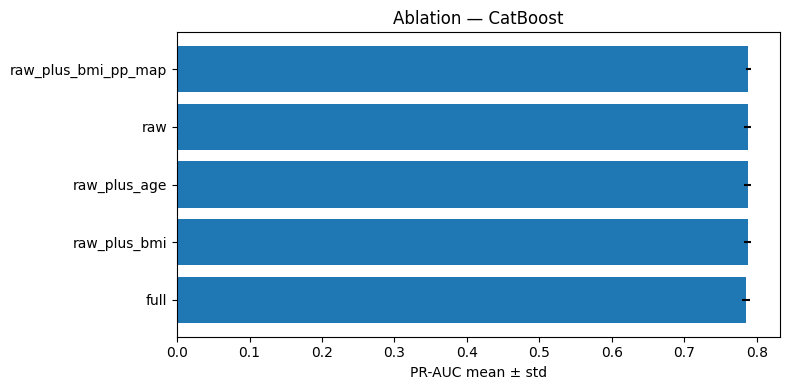

In [56]:
class AblationFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, feature_set="raw"):
        self.feature_set = feature_set

    def fit(self, X, y=None):
        if self.feature_set == "full":
            self.fe_ = make_feature_engineer_from_config(CONFIG).fit(X, y)
        else:
            self.fe_ = None
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if self.feature_set == "full":
            return self.fe_.transform(X)
        out = X[["age", "gender", "height", "weight", "ap_hi", "ap_lo",
                 "cholesterol", "gluc", "smoke", "alco", "active"]].copy()
        if self.feature_set in ["raw_plus_age", "raw_plus_bmi", "raw_plus_bmi_pp_map"]:
            out["age_years"] = pd.to_numeric(X["age"], errors="coerce") / 365.25
        if self.feature_set in ["raw_plus_bmi", "raw_plus_bmi_pp_map"]:
            h = pd.to_numeric(X["height"], errors="coerce") / 100.0
            out["bmi"] = pd.to_numeric(X["weight"], errors="coerce") / (h ** 2)
        if self.feature_set == "raw_plus_bmi_pp_map":
            ap_hi = pd.to_numeric(X["ap_hi"], errors="coerce")
            ap_lo = pd.to_numeric(X["ap_lo"], errors="coerce")
            out["pulse_pressure"] = ap_hi - ap_lo
            out["map_proxy"] = (2 * ap_lo + ap_hi) / 3.0
        return out


def ablation_columns(fs):
    base_num = ["age", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc"]
    base_bin = ["smoke", "alco", "active"]
    base_cat = ["gender"]
    return {
        "raw":                 (base_num, base_bin, base_cat),
        "raw_plus_age":        (base_num + ["age_years"], base_bin, base_cat),
        "raw_plus_bmi":        (base_num + ["age_years", "bmi"], base_bin, base_cat),
        "raw_plus_bmi_pp_map": (base_num + ["age_years", "bmi", "pulse_pressure", "map_proxy"],
                                 base_bin, base_cat),
        "full":                (NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES),
    }[fs]


def create_ablation_preprocess(fs):
    num, bin_c, cat = ablation_columns(fs)
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("bin", Pipeline([("imp", SimpleImputer(strategy="most_frequent"))]), bin_c),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", make_ohe())]), cat),
    ], remainder="drop", verbose_feature_names_out=True, sparse_threshold=0.0)


def build_ablation_pipeline(fs, model):
    return Pipeline([
        ("ablation_fe", AblationFeatureBuilder(feature_set=fs)),
        ("preprocess",  create_ablation_preprocess(fs)),
        ("model",       safe_clone_estimator(model)),
    ])


ablation_results = pd.DataFrame()
if CONFIG["run_ablation_study"]:
    feature_sets = ["raw", "raw_plus_age", "raw_plus_bmi", "raw_plus_bmi_pp_map", "full"]
    if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
        ab_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED + 808)
        ab_groups = g_train; ab_protocol = "StratifiedGroupKFold"
    else:
        ab_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + 808)
        ab_groups = None; ab_protocol = "StratifiedKFold"

    ab_models = [
        ("LogisticRegression_control",
         LogisticRegression(max_iter=3000, solver="lbfgs",
                              class_weight="balanced", random_state=SEED)),
        (f"FinalModel_{BEST_MODEL_NAME}", safe_clone_estimator(DIAGNOSTIC_ESTIMATOR.named_steps["model"])),
    ]

    ab_scoring = {"accuracy": "accuracy", "recall": "recall", "precision": "precision",
                  "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}
    rows = []
    for label, model_obj in ab_models:
        for fs in feature_sets:
            print(f"[ABLATION] {label} | {fs}")
            t0 = time.time()
            try:
                res = cross_validate(
                    build_ablation_pipeline(fs, model_obj),
                    X_train, y_train, cv=ab_cv, groups=ab_groups,
                    scoring=ab_scoring, n_jobs=N_JOBS, error_score="raise",
                )
                row = {"model_family": label, "feature_set": fs,
                       "cv_protocol": ab_protocol,
                       "elapsed_sec": round(time.time() - t0, 1)}
                for metric in ab_scoring:
                    vals = res[f"test_{metric}"]
                    row[f"{metric}_mean"] = float(np.mean(vals))
                    row[f"{metric}_std"]  = float(np.std(vals))
                rows.append(row)
            except Exception as e:
                rows.append({"model_family": label, "feature_set": fs,
                              "status": f"FAILED: {e}"})

    ablation_results = pd.DataFrame(rows)
    raw_lookup = ablation_results[ablation_results["feature_set"] == "raw"
                                    ].set_index("model_family")
    for metric in ["accuracy", "recall", "precision", "f1", "roc_auc", "pr_auc"]:
        ablation_results[f"delta_{metric}_vs_raw"] = ablation_results.apply(
            lambda r: r[f"{metric}_mean"] - raw_lookup.loc[r["model_family"], f"{metric}_mean"]
                      if (r["model_family"] in raw_lookup.index and
                          f"{metric}_mean" in r.index and pd.notna(r.get(f"{metric}_mean")))
                      else np.nan, axis=1
        )
    ablation_results = ablation_results.sort_values(["model_family", "pr_auc_mean"],
                                                       ascending=[True, False])
    save_df(ablation_results, TABLE_DIR / "16_ablation_cv.csv")
    display(ablation_results)

    final_label = f"FinalModel_{BEST_MODEL_NAME}"
    final_ab = ablation_results[ablation_results["model_family"] == final_label].copy()
    if len(final_ab):
        save_df(final_ab, TABLE_DIR / "16_ablation_final_model.csv")
        plt.figure(figsize=(8, 4))
        pl = final_ab.sort_values("pr_auc_mean", ascending=True)
        plt.barh(pl["feature_set"], pl["pr_auc_mean"], xerr=pl["pr_auc_std"])
        plt.xlabel("PR-AUC mean ± std")
        plt.title(f"Ablation — {BEST_MODEL_NAME}")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "16_ablation_pr_auc.png", dpi=160)
        plt.show()
else:
    print("[ABLATION SKIPPED]")


### 20.2. Cleaning sensitivity

[CLEANING SENSITIVITY] current
[CLEANING SENSITIVITY] loose
[CLEANING SENSITIVITY] strict


,scenario,model_family,cv_protocol,elapsed_sec,height,weight,ap_hi,ap_lo,bmi,age_invalid_flag_rate,...,balanced_accuracy_std,brier_mean,brier_std,delta_roc_auc_vs_current,delta_pr_auc_vs_current,delta_recall_vs_current,delta_precision_vs_current,delta_f1_vs_current,delta_balanced_accuracy_vs_current,delta_brier_vs_current
0,current,FinalModel_CatBoost,StratifiedGroupKFold,14.4,"(130.0, 220.0)","(30.0, 180.0)","(80.0, 250.0)","(40.0, 180.0)","(10.0, 80.0)",0.0,...,0.000994,0.180251,0.000265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,loose,FinalModel_CatBoost,StratifiedGroupKFold,14.6,"(120.0, 230.0)","(25.0, 200.0)","(70.0, 260.0)","(35.0, 190.0)","(8.0, 90.0)",0.0,...,0.000783,0.180269,0.000256,-0.000088,-0.000204,-0.000669,0.000112,-0.000309,-0.000156,0.000018
2,strict,FinalModel_CatBoost,StratifiedGroupKFold,14.3,"(140.0, 210.0)","(35.0, 160.0)","(90.0, 220.0)","(50.0, 140.0)","(12.0, 65.0)",0.0,...,0.000842,0.180299,0.000277,-0.000114,-0.000709,0.000711,-0.000571,0.000117,-0.000106,0.000048


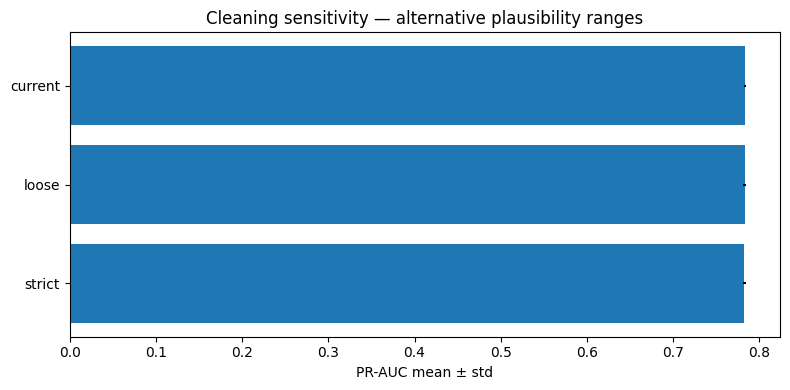

In [57]:
def build_pipeline_with_config(model, config_override):
    return Pipeline([
        ("fe",         make_feature_engineer_from_config(config_override)),
        ("preprocess", create_preprocess()),
        ("model",      safe_clone_estimator(model)),
    ])


cleaning_results = pd.DataFrame()
if CONFIG["run_cleaning_sensitivity"]:
    if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
        cl_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED + 909)
        cl_groups = g_train; cl_protocol = "StratifiedGroupKFold"
    else:
        cl_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + 909)
        cl_groups = None; cl_protocol = "StratifiedKFold"

    sens_model = safe_clone_estimator(DIAGNOSTIC_ESTIMATOR.named_steps["model"])
    sens_label = f"FinalModel_{BEST_MODEL_NAME}"
    sens_scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
                    "recall": "recall", "precision": "precision",
                    "f1": "f1", "balanced_accuracy": "balanced_accuracy",
                    "neg_brier_score": "neg_brier_score"}
    rows = []
    for sc in CONFIG["cleaning_sensitivity_scenarios"]:
        cfg = dict(CONFIG)
        cfg["height_range_cm"] = tuple(sc["height"])
        cfg["weight_range_kg"] = tuple(sc["weight"])
        cfg["ap_hi_range"]     = tuple(sc["ap_hi"])
        cfg["ap_lo_range"]     = tuple(sc["ap_lo"])
        cfg["bmi_range"]       = tuple(sc["bmi"])

        # Audit số dòng bị flag trên train với scenario này
        fe_tmp = make_feature_engineer_from_config(cfg).fit(X_train, y_train)
        X_tr_fe = fe_tmp.transform(X_train)
        flag_cols = [c for c in X_tr_fe.columns if c.endswith("_invalid_flag")]
        rule_audit = {f"{c}_rate": float(X_tr_fe[c].mean()) for c in flag_cols}

        print(f"[CLEANING SENSITIVITY] {sc['scenario']}")
        t0 = time.time()
        try:
            res = cross_validate(
                build_pipeline_with_config(sens_model, cfg),
                X_train, y_train, cv=cl_cv, groups=cl_groups,
                scoring=sens_scoring, n_jobs=N_JOBS, error_score="raise",
            )
            row = {"scenario": sc["scenario"], "model_family": sens_label,
                   "cv_protocol": cl_protocol,
                   "elapsed_sec": round(time.time() - t0, 1),
                   "height": str(sc["height"]), "weight": str(sc["weight"]),
                   "ap_hi": str(sc["ap_hi"]), "ap_lo": str(sc["ap_lo"]),
                   "bmi": str(sc["bmi"]), **rule_audit}
            for metric in sens_scoring:
                vals = res[f"test_{metric}"]
                if metric == "neg_brier_score":
                    row["brier_mean"] = float(np.mean(-vals))
                    row["brier_std"]  = float(np.std(-vals))
                else:
                    row[f"{metric}_mean"] = float(np.mean(vals))
                    row[f"{metric}_std"]  = float(np.std(vals))
            rows.append(row)
        except Exception as e:
            rows.append({"scenario": sc["scenario"], "status": f"FAILED: {e}"})

    cleaning_results = pd.DataFrame(rows).sort_values("pr_auc_mean", ascending=False,
                                                         na_position="last")
    if "current" in set(cleaning_results["scenario"]):
        base = cleaning_results[cleaning_results["scenario"] == "current"].iloc[0]
        for metric in ["roc_auc", "pr_auc", "recall", "precision", "f1",
                       "balanced_accuracy", "brier"]:
            col = f"{metric}_mean"
            if col in cleaning_results.columns:
                cleaning_results[f"delta_{metric}_vs_current"] = (
                    cleaning_results[col] - float(base[col])
                )
    save_df(cleaning_results, TABLE_DIR / "16b_cleaning_sensitivity_cv.csv")
    display(cleaning_results)

    plt.figure(figsize=(8, 4))
    pl = cleaning_results.sort_values("pr_auc_mean", ascending=True)
    plt.barh(pl["scenario"], pl["pr_auc_mean"], xerr=pl["pr_auc_std"])
    plt.xlabel("PR-AUC mean ± std")
    plt.title("Cleaning sensitivity — alternative plausibility ranges")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "16b_cleaning_sensitivity.png", dpi=160)
    plt.show()
else:
    print("[CLEANING SENSITIVITY SKIPPED]")


### 20.3. Multi-seed robustness

[MULTI-SEED] seed=42
[MULTI-SEED] seed=2024
[MULTI-SEED] seed=2026


,seed,model_family,elapsed_sec,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,42,FinalModel_CatBoost,14.5,0.733682,0.004358,0.733666,0.004301,0.696090,0.006639,0.752421,0.003246,0.723151,0.004788,0.801438,0.004582,0.783276,0.005916
1,2024,FinalModel_CatBoost,14.5,0.735661,0.004547,0.735644,0.004612,0.698699,0.007750,0.754197,0.005027,0.725373,0.005849,0.801933,0.004551,0.784025,0.007103
2,2026,FinalModel_CatBoost,14.5,0.735061,0.002820,0.735024,0.003084,0.696664,0.005270,0.754285,0.005537,0.724327,0.005206,0.801479,0.001117,0.783350,0.002587


,metric,mean_across_seeds,std_across_seeds,min,max,range
0,accuracy,0.734802,0.001015,0.733682,0.735661,0.001979
1,balanced_accuracy,0.734778,0.001012,0.733666,0.735644,0.001978
2,recall,0.697151,0.001371,0.696090,0.698699,0.002609
3,precision,0.753634,0.001051,0.752421,0.754285,0.001864
4,f1,0.724284,0.001111,0.723151,0.725373,0.002222
5,roc_auc,0.801617,0.000275,0.801438,0.801933,0.000495
6,pr_auc,0.783550,0.000412,0.783276,0.784025,0.000748


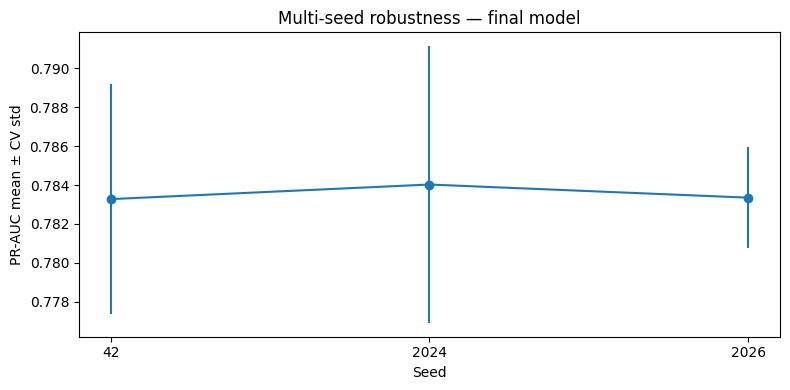

In [58]:
multi_seed_results = pd.DataFrame()
if CONFIG["run_multi_seed_robustness"]:
    seeds = CONFIG["multi_seed_values"]
    seed_model = safe_clone_estimator(DIAGNOSTIC_ESTIMATOR.named_steps["model"])
    seed_label = f"FinalModel_{BEST_MODEL_NAME}"
    seed_scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
                    "recall": "recall", "precision": "precision", "f1": "f1",
                    "roc_auc": "roc_auc", "pr_auc": "average_precision"}
    rows = []
    for seed in seeds:
        if USE_GROUP_SPLIT and HAS_STRATIFIED_GROUP_KFOLD:
            seed_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=seed)
            seed_groups = g_train
        else:
            seed_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
            seed_groups = None

        print(f"[MULTI-SEED] seed={seed}")
        t0 = time.time()
        try:
            res = cross_validate(
                build_pipeline(seed_model), X_train, y_train,
                cv=seed_cv, groups=seed_groups,
                scoring=seed_scoring, n_jobs=N_JOBS, error_score="raise",
            )
            row = {"seed": seed, "model_family": seed_label,
                   "elapsed_sec": round(time.time() - t0, 1)}
            for metric in seed_scoring:
                vals = res[f"test_{metric}"]
                row[f"{metric}_mean"] = float(np.mean(vals))
                row[f"{metric}_std"]  = float(np.std(vals))
            rows.append(row)
        except Exception as e:
            rows.append({"seed": seed, "status": f"FAILED: {e}"})

    multi_seed_results = pd.DataFrame(rows)
    save_df(multi_seed_results, TABLE_DIR / "17_multi_seed_cv.csv")

    summary_rows = []
    for metric in seed_scoring:
        col = f"{metric}_mean"
        if col not in multi_seed_results.columns:
            continue
        vals = multi_seed_results[col].dropna()
        if len(vals) == 0:
            continue
        summary_rows.append({
            "metric": metric,
            "mean_across_seeds": float(vals.mean()),
            "std_across_seeds": float(vals.std(ddof=1)) if len(vals) > 1 else 0.0,
            "min": float(vals.min()), "max": float(vals.max()),
            "range": float(vals.max() - vals.min()),
        })
    multi_seed_summary = pd.DataFrame(summary_rows)
    save_df(multi_seed_summary, TABLE_DIR / "17_multi_seed_summary.csv")
    display(multi_seed_results); display(multi_seed_summary)

    plt.figure(figsize=(8, 4))
    valid = multi_seed_results.dropna(subset=["pr_auc_mean"])
    plt.errorbar(valid["seed"].astype(str), valid["pr_auc_mean"],
                 yerr=valid["pr_auc_std"], fmt="o-")
    plt.xlabel("Seed"); plt.ylabel("PR-AUC mean ± CV std")
    plt.title("Multi-seed robustness — final model")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "17_multi_seed_pr_auc.png", dpi=160)
    plt.show()
else:
    print("[MULTI-SEED SKIPPED]")


### 20.4. Cost-sensitive threshold

Cost-sensitive: cost(FN) = 5.0 × cost(FP)
Protocol: tuning on val_threshold only; test comparison is post-hoc sensitivity analysis.


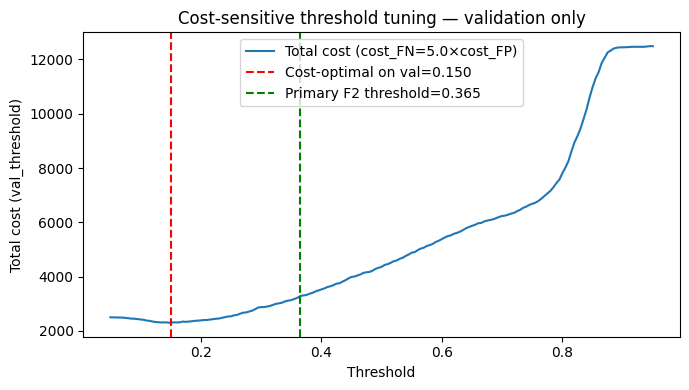

,threshold_type,threshold,recall_sensitivity,specificity,fp,fn,total_cost,analysis_role,not_for_model_selection
0,Primary F2 threshold locked before test,0.365,0.818491,0.613832,1932,907,6467.0,post_hoc_test_sensitivity_only,True
1,Cost-optimal threshold from val_threshold,0.150,0.988593,0.126724,4369,57,4654.0,post_hoc_test_sensitivity_only,True



Kết luận an toàn: cost-optimal threshold được học trên val_threshold. Bảng test chỉ là phân tích độ nhạy hậu nghiệm, không thay threshold chính, không dùng để chọn lại mô hình và không làm mất tính độc lập của test set.


In [59]:

# Tối ưu threshold theo cost matrix: cost(FN) = ratio × cost(FP)
# QUY TẮC: threshold cost-sensitive chỉ được học trên val_threshold.
# Test comparison bên dưới chỉ là post-hoc sensitivity analysis, không dùng để thay threshold chính đã khóa.
cost_threshold_table = None
if CONFIG["run_cost_sensitive_threshold"]:
    ratio = CONFIG["cost_fn_to_fp_ratio"]
    print(f"Cost-sensitive: cost(FN) = {ratio} × cost(FP)")
    print("Protocol: tuning on val_threshold only; test comparison is post-hoc sensitivity analysis.")

    thresholds = np.linspace(0.05, 0.95, 181)
    rows = []
    for t in thresholds:
        m = binary_metrics_at_threshold(y_val_threshold, p_threshold, t)
        # Total cost = FP × 1 + FN × ratio
        m["total_cost"] = m["fp"] + ratio * m["fn"]
        rows.append(m)
    cost_threshold_table = pd.DataFrame(rows)
    save_df(cost_threshold_table, TABLE_DIR / "17b_cost_sensitive_threshold_val.csv")

    best_cost_row = cost_threshold_table.sort_values("total_cost").iloc[0]
    BEST_COST_THRESHOLD = float(best_cost_row["threshold"])
    save_json({
        "analysis_role": "validation_only_threshold_sensitivity",
        "selection_data": "val_threshold",
        "not_used_to_replace_primary_f2_threshold": True,
        "test_set_usage": "post_hoc_reporting_only",
        "cost_fn_to_fp_ratio": ratio,
        "best_cost_threshold": BEST_COST_THRESHOLD,
        "primary_f2_threshold": float(BEST_THRESHOLD),
        "best_cost_row_metrics": best_cost_row.to_dict(),
    }, TABLE_DIR / "17b_cost_sensitive_threshold_summary.json")

    plt.figure(figsize=(7, 4))
    plt.plot(cost_threshold_table["threshold"], cost_threshold_table["total_cost"],
             label=f"Total cost (cost_FN={ratio}×cost_FP)")
    plt.axvline(BEST_COST_THRESHOLD, linestyle="--", color="red",
                label=f"Cost-optimal on val={BEST_COST_THRESHOLD:.3f}")
    plt.axvline(BEST_THRESHOLD, linestyle="--", color="green",
                label=f"Primary F2 threshold={BEST_THRESHOLD:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Total cost (val_threshold)")
    plt.title("Cost-sensitive threshold tuning — validation only")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "17b_cost_sensitive_threshold.png", dpi=160)
    plt.show()

    # Post-hoc sensitivity analysis trên test: không dùng để chọn lại threshold/model.
    compare_rows = []
    for label, th in [("Primary F2 threshold locked before test", BEST_THRESHOLD),
                      ("Cost-optimal threshold from val_threshold", BEST_COST_THRESHOLD)]:
        m = binary_metrics_at_threshold(y_test, p_test, th)
        m["total_cost"] = m["fp"] + ratio * m["fn"]
        m["threshold_type"] = label
        m["analysis_role"] = "post_hoc_test_sensitivity_only"
        m["not_for_model_selection"] = True
        compare_rows.append(m)
    cost_compare = pd.DataFrame(compare_rows)
    save_df(cost_compare, TABLE_DIR / "17b_cost_threshold_test_comparison.csv")
    display(cost_compare[[
        "threshold_type", "threshold", "recall_sensitivity",
        "specificity", "fp", "fn", "total_cost",
        "analysis_role", "not_for_model_selection",
    ]])
    print(
        "\nKết luận an toàn: cost-optimal threshold được học trên val_threshold. "
        "Bảng test chỉ là phân tích độ nhạy hậu nghiệm, không thay threshold chính, "
        "không dùng để chọn lại mô hình và không làm mất tính độc lập của test set."
    )
else:
    print("[COST-SENSITIVE THRESHOLD SKIPPED]")


## 21. Drift monitoring + Cleveland OOD sanity check reduced-schema

- **21.1 Drift monitoring** (PSI + KS) train vs test trong cùng dataset.
- **21.2 Cleveland OOD sanity check** (UCI Heart Disease) — reduced-schema mapping.


### 21.1. Drift monitoring (PSI + KS) train vs test

In [60]:
def psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)
    if expected.nunique() < 2 or actual.nunique() < 2:
        return np.nan
    quantiles = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(quantiles) <= 2:
        return np.nan
    e_counts = np.histogram(expected, bins=quantiles)[0] / len(expected)
    a_counts = np.histogram(actual, bins=quantiles)[0] / len(actual)
    e_counts = np.clip(e_counts, 1e-6, None)
    a_counts = np.clip(a_counts, 1e-6, None)
    return float(np.sum((a_counts - e_counts) * np.log(a_counts / e_counts)))


train_fe_final = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_train)
test_fe_final  = DIAGNOSTIC_ESTIMATOR.named_steps["fe"].transform(X_test)

drift_rows = []
for col in NUMERIC_FEATURES + BINARY_FEATURES:
    if col not in train_fe_final.columns or col not in test_fe_final.columns:
        continue
    tr_v = pd.to_numeric(train_fe_final[col], errors="coerce")
    te_v = pd.to_numeric(test_fe_final[col],  errors="coerce")
    if tr_v.notna().sum() > 0 and te_v.notna().sum() > 0:
        ks_stat, ks_p = stats.ks_2samp(tr_v.dropna(), te_v.dropna())
    else:
        ks_stat, ks_p = np.nan, np.nan
    drift_rows.append({
        "feature": col,
        "train_mean": float(tr_v.mean()), "test_mean": float(te_v.mean()),
        "train_missing_rate": float(tr_v.isna().mean()),
        "test_missing_rate":  float(te_v.isna().mean()),
        "ks_stat": float(ks_stat) if not pd.isna(ks_stat) else np.nan,
        "ks_pvalue": float(ks_p) if not pd.isna(ks_p) else np.nan,
        "psi": psi(tr_v, te_v),
    })

drift_report = pd.DataFrame(drift_rows).sort_values("psi", ascending=False, na_position="last")
save_df(drift_report, TABLE_DIR / "16_drift_monitoring.csv")
save_df(drift_report, ARTIFACT_DIR / "drift_monitoring_report.csv")
display(drift_report.head(20))
print("Quy ước PSI: <0.10 = no drift, 0.10-0.25 = minor drift, >0.25 = major drift")

,feature,train_mean,test_mean,train_missing_rate,test_missing_rate,ks_stat,ks_pvalue,psi
5,bmi,27.479873,27.382134,0.001600,0.0013,0.015662,0.035937,0.002495
7,map_proxy,96.466088,96.277630,0.018667,0.0198,0.007976,0.684103,0.001221
1,height_clean,164.414386,164.539047,0.001444,0.0012,0.011701,0.211491,0.000963
0,age_years,53.299429,53.295685,0.000000,0.0000,0.006774,0.844453,0.000905
3,ap_hi_clean,126.740732,126.476433,0.018667,0.0198,0.009768,0.425722,0.000787
2,weight_clean,74.197462,74.061692,0.000156,0.0001,0.007071,0.805252,0.000707
4,ap_lo_clean,81.328767,81.178229,0.018667,0.0198,0.008001,0.680433,0.000477
6,pulse_pressure,45.411966,45.298204,0.018667,0.0198,0.006935,0.832517,0.000271
9,gluc,1.225583,1.230900,0.000000,0.0000,0.003186,0.999996,0.000079
8,cholesterol,1.369230,1.363900,0.000000,0.0000,0.003147,0.999997,0.000025


Quy ước PSI: <0.10 = no drift, 0.10-0.25 = minor drift, >0.25 = major drift


### 21.2. Cleveland reduced-schema OOD sanity check — KHÔNG phải external validation lâm sàng của full model

Phần này được giữ như một **sanity check ngoài phân phối (out-of-distribution / OOD)**, không dùng làm bằng chứng chính cho mô hình full Sulianova.

**Vì sao không gọi là external validation lâm sàng đúng nghĩa?**

- Cleveland và Sulianova khác schema, khác thời điểm thu thập và khác cơ chế chọn mẫu.
- Cleveland thiếu `ap_lo`, `height`, `weight`, `smoke`, `alco`, `active`; các cột này chỉ có thể gán placeholder hợp lệ.
- Mô hình reduced-schema chỉ dùng 5 feature giao nhau, nên không đánh giá đầy đủ mô hình final full-feature.
- Kết quả chỉ cho biết mức độ dataset shift sơ bộ, không chứng minh mô hình dùng được trong y tế thật.

**Schema mapping có thể dùng cho sanity check:**

| Sulianova | Cleveland | Cách map |
|---|---|---|
| `age` (days) | `age` (years) | `age_days = age_years × 365.25` |
| `ap_hi` | `trestbps` | trực tiếp (mmHg) |
| `cholesterol` (1/2/3) | `chol` (mg/dL) | chuyển thành ordinal tham khảo: `<200→1`, `200–239→2`, `≥240→3` |
| `gluc` (1/2/3) | `fbs` (0/1) | `fbs=0→1`, `fbs=1→3`; không có level 2 |
| `gender` (1/2) | `sex` (0/1) | `sex+1`, tức `1=women`, `2=men` |
| `cardio` | `target` / `condition` / `num` | `target ≥ 1 → 1` |

**Protocol an toàn:**
1. Train một mô hình phụ reduced-schema trên Sulianova train.
2. Báo cáo Sulianova test như in-distribution reference.
3. Báo cáo Cleveland như OOD sanity check.
4. Không dùng kết quả Cleveland để chọn model, threshold, calibration hoặc sửa final test result.


In [61]:
CLEVELAND_PATH_CANDIDATES = [
    Path("/kaggle/input/heart-disease-cleveland-uci/heart_cleveland_upload.csv"),
    Path("/kaggle/input/heart-disease-uci/heart.csv"),
    Path("/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv"),
    Path("/mnt/data/heart_cleveland_upload.csv"),
    Path("/mnt/data/heart.csv"),
    Path("/mnt/user-data/uploads/heart_cleveland_upload.csv"),
    Path("/mnt/user-data/uploads/heart.csv"),
]
cleveland_path = next((p for p in CLEVELAND_PATH_CANDIDATES if p.exists()), None)


def map_cleveland_to_sulianova(cv_df: pd.DataFrame) -> tuple:
    """Map Cleveland schema → Sulianova-compatible feature space for OOD sanity check only."""
    # Detect target column (Cleveland sometimes uses 'condition', sometimes 'target')
    target_col = None
    for cand in ["target", "condition", "num"]:
        if cand in cv_df.columns:
            target_col = cand; break
    if target_col is None:
        raise ValueError(f"Không tìm thấy target column trong Cleveland. Cols: {list(cv_df.columns)}")

    y_cv = (pd.to_numeric(cv_df[target_col], errors="coerce") >= 1).astype(int)

    # Map cholesterol mg/dL → ordinal 1/2/3 for reduced-schema sanity check only
    chol = pd.to_numeric(cv_df["chol"], errors="coerce")
    chol_ord = pd.cut(chol, bins=[-np.inf, 200, 240, np.inf], right=False,
                      labels=[1, 2, 3]).astype("Int64").astype(float)

    # Map fbs (0/1) → gluc (1/3, không có level 2); approximate, not equivalent lab measurement
    fbs = pd.to_numeric(cv_df["fbs"], errors="coerce")
    gluc_ord = np.where(fbs == 1, 3, 1).astype(float)

    # gender: Cleveland sex 0=female, 1=male → Sulianova official mapping 1=women, 2=men
    sex = pd.to_numeric(cv_df["sex"], errors="coerce")
    gender_sul = (sex + 1).astype(float)

    # age years → days
    age_days = pd.to_numeric(cv_df["age"], errors="coerce") * 365.25
    ap_hi = pd.to_numeric(cv_df["trestbps"], errors="coerce")

    n = len(cv_df)
    X_mapped = pd.DataFrame({
        "id": np.arange(n),
        "age": age_days, "gender": gender_sul,
        "height": np.full(n, 170.0),  # placeholder median Sulianova
        "weight": np.full(n, 70.0),   # placeholder median
        "ap_hi": ap_hi,
        "ap_lo": np.full(n, 80.0),    # placeholder median
        "cholesterol": chol_ord,
        "gluc": gluc_ord,
        "smoke": np.zeros(n),
        "alco": np.zeros(n),
        "active": np.ones(n),
    })
    return X_mapped, y_cv


REAL_CV_FEATURES = ["age", "ap_hi", "cholesterol", "gluc", "gender"]
PLACEHOLDER_FEATURES = ["height", "weight", "ap_lo", "smoke", "alco", "active"]

if cleveland_path is None:
    save_json({
        "status": "skipped",
        "reason": "Cleveland dataset not found in candidate paths.",
        "candidate_paths_tried": [str(p) for p in CLEVELAND_PATH_CANDIDATES],
        "fallback_recommendation": (
            "Optional only: add Cleveland Heart Disease dataset for reduced-schema OOD sanity check, "
            "not for full clinical external validation."
        ),
    }, TABLE_DIR / "16c_external_cleveland_status.json")
    print("[OOD SANITY CHECK SKIPPED] Cleveland dataset not found.")
    print("Candidate paths tried:")
    for p in CLEVELAND_PATH_CANDIDATES:
        print(f"  - {p}")
else:
    print(f"[CLEVELAND] Loading from {cleveland_path}")
    cleveland_df = pd.read_csv(cleveland_path)
    print(f"Cleveland shape: {cleveland_df.shape}")
    print(f"Cleveland columns: {list(cleveland_df.columns)}")
    display(cleveland_df.head())

    try:
        X_cv_mapped, y_cv = map_cleveland_to_sulianova(cleveland_df)
        print(f"Mapped Cleveland: {X_cv_mapped.shape}, prevalence={y_cv.mean():.4f}")
        save_df(X_cv_mapped.head(20), TABLE_DIR / "16c_cleveland_mapped_sample.csv")
    except Exception as e:
        save_json({"status": "mapping_failed", "reason": str(e)},
                  TABLE_DIR / "16c_external_cleveland_status.json")
        print(f"[CLEVELAND MAPPING FAILED] {e}")
        cleveland_path = None

[CLEVELAND] Loading from /kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv
Cleveland shape: (297, 14)
Cleveland columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Mapped Cleveland: (297, 12), prevalence=0.4613


In [62]:

# Train reduced-schema model phụ trên Sulianova (chỉ 5 feature có chia sẻ với Cleveland)
# Đây là OOD sanity check, KHÔNG phải external validation lâm sàng của full model.
if cleveland_path is not None:
    REDUCED_NUM = ["age_years", "ap_hi_clean", "cholesterol", "gluc"]
    REDUCED_BIN = []
    REDUCED_CAT = ["gender"]


    class ReducedFeatureEngineer(BaseEstimator, TransformerMixin):
        """Chỉ dùng 5 feature: age_years, ap_hi_clean, cholesterol, gluc, gender."""
        def __init__(self):
            self.fe_full_ = make_feature_engineer_from_config(CONFIG)

        def fit(self, X, y=None):
            self.fe_full_.fit(X, y)
            return self

        def transform(self, X):
            full = self.fe_full_.transform(X)
            return full[REDUCED_NUM + REDUCED_CAT]


    def create_reduced_preprocess():
        return ColumnTransformer(
            transformers=[
                ("num", Pipeline([
                    ("imp", SimpleImputer(strategy="median")),
                    ("sc",  StandardScaler()),
                ]), REDUCED_NUM),
                ("cat", Pipeline([
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("ohe", make_ohe()),
                ]), REDUCED_CAT),
            ], remainder="drop", verbose_feature_names_out=True, sparse_threshold=0.0,
        )


    def build_reduced_pipeline(model):
        return Pipeline([
            ("fe",         ReducedFeatureEngineer()),
            ("preprocess", create_reduced_preprocess()),
            ("model",      safe_clone_estimator(model)),
        ])


    # Train reduced model trên Sulianova train (LR cho ổn định, dễ hiểu)
    reduced_lr = LogisticRegression(max_iter=4000, solver="lbfgs",
                                    class_weight="balanced", random_state=SEED)
    reduced_pipe = build_reduced_pipeline(reduced_lr)
    reduced_pipe.fit(X_train, y_train)

    # In-distribution reference: Sulianova test.
    # Đây vẫn là test set final, nhưng chỉ dùng để tham chiếu cho reduced model,
    # không dùng để thay đổi final full model.
    p_reduced_sul_test = predict_proba_positive(reduced_pipe, X_test)
    sul_in_metrics = {
        **probability_metrics(y_test, p_reduced_sul_test),
        "n_test": len(y_test),
    }

    # Out-of-distribution sanity check: Cleveland mapped
    p_reduced_cv = predict_proba_positive(reduced_pipe, X_cv_mapped)
    cv_ood_metrics = {
        **probability_metrics(y_cv, p_reduced_cv),
        "n_cleveland": len(y_cv),
    }

    auc_sul = sul_in_metrics["roc_auc"]
    auc_cv  = cv_ood_metrics["roc_auc"]
    rel_drop = (auc_sul - auc_cv) / auc_sul if auc_sul > 0 else np.nan

    if np.isnan(rel_drop):
        ood_interpretation = "Không tính được relative AUC drop."
    elif rel_drop >= 0.15:
        ood_interpretation = "AUC giảm mạnh trên Cleveland; có dấu hiệu dataset shift rõ."
    elif rel_drop >= 0:
        ood_interpretation = (
            "AUC không giảm mạnh trong sanity check, nhưng không được diễn giải là "
            "external validation lâm sàng của full model."
        )
    else:
        ood_interpretation = (
            "AUC Cleveland cao hơn reference; có thể do khác cơ chế chọn mẫu/easier classification, "
            "không chứng minh generalization lâm sàng."
        )

    external_summary = {
        "validation_type": "reduced_schema_ood_sanity_check_only",
        "is_clinical_external_validation_of_full_model": False,
        "not_used_for_model_selection": True,
        "not_used_for_threshold_tuning": True,
        "not_used_for_calibration": True,
        "reduced_features_real": REAL_CV_FEATURES,
        "reduced_features_placeholder_in_cleveland": PLACEHOLDER_FEATURES,
        "model": "LogisticRegression (reduced 5-feature)",
        "sulianova_in_distribution_reference": sul_in_metrics,
        "cleveland_out_of_distribution_sanity_check": cv_ood_metrics,
        "auc_relative_drop": float(rel_drop),
        "ood_interpretation": ood_interpretation,
        "caveats": [
            "This is not a clinical external validation of the final full-feature model.",
            "Reduced model loses ap_lo, BMI/body size and lifestyle predictors.",
            "Cleveland and Sulianova differ in collection year, population and case-mix.",
            "Cleveland may be pre-screened for coronary angiography, making discrimination non-comparable.",
            "Six Sulianova features are placeholders in Cleveland mapping.",
        ],
    }
    save_json(external_summary, TABLE_DIR / "16c_cleveland_ood_sanity_summary.json")
    # Legacy filename kept for compatibility, but content explicitly says OOD sanity check only.
    save_json(external_summary, TABLE_DIR / "16c_external_cleveland_summary.json")

    cmp_table = pd.DataFrame([
        {"setting": "Sulianova test reference for reduced model", **sul_in_metrics},
        {"setting": "Cleveland reduced-schema OOD sanity check", **cv_ood_metrics},
    ])
    cmp_table["validation_type"] = "OOD sanity check only"
    cmp_table["not_clinical_external_validation"] = True
    save_df(cmp_table, TABLE_DIR / "16c_cleveland_ood_sanity_metrics.csv")
    save_df(cmp_table, TABLE_DIR / "16c_external_cleveland_metrics.csv")
    display(cmp_table)

    print(f"\nROC-AUC relative difference: {rel_drop:.4f}")
    print(f"INTERPRETATION: {ood_interpretation}")
    print(
        "\nLƯU Ý BẮT BUỘC: Cleveland reduced-schema chỉ là OOD sanity check. "
        "Không được dùng câu này để nói mô hình full có external validation lâm sàng. "
        "Muốn kết luận clinical deployment cần external/prospective validation đúng schema."
    )


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


,setting,roc_auc,pr_auc,brier,log_loss,ece_10,n_test,n_cleveland,validation_type,not_clinical_external_validation
0,Sulianova test reference for reduced model,0.786443,0.77392,0.188848,0.563338,0.031267,10000.0,NaN,OOD sanity check only,True
1,Cleveland reduced-schema OOD sanity check,0.628901,0.58426,0.292909,0.854644,0.239033,NaN,297.0,OOD sanity check only,True



ROC-AUC relative difference: 0.2003
INTERPRETATION: AUC giảm mạnh trên Cleveland; có dấu hiệu dataset shift rõ.

LƯU Ý BẮT BUỘC: Cleveland reduced-schema chỉ là OOD sanity check. Không được dùng câu này để nói mô hình full có external validation lâm sàng. Muốn kết luận clinical deployment cần external/prospective validation đúng schema.


## 22. Save model + model card + sanity check

- Lưu model package (joblib) đầy đủ: estimator + calibrator + threshold + feature contract.
- `model_card.json` + `model_card.md` theo Mitchell et al. 2019.
- `report_artifact_binding.csv` ràng buộc bảng/hình → vị trí trong báo cáo.
- Sanity check phân biệt **must-have** (split, model, test_metrics) và **nice-to-have** (DCA, fairness, external).

In [63]:
# Lưu model package
model_package = {
    "estimator":   estimator,
    "calibrator":  calibrator,
    "threshold":   float(BEST_THRESHOLD),
    "model_name":  BEST_MODEL_NAME,
    "calibrator_name": BEST_CALIBRATOR_NAME,
    "feature_columns_input":  list(X_train.columns),
    "feature_engineered":     FE_OUTPUT_FEATURES,
    "numeric_features":       NUMERIC_FEATURES,
    "binary_features":        BINARY_FEATURES,
    "categorical_features":   CATEGORICAL_FEATURES,
    "target_column":          TARGET,
    "config":                 CONFIG,
    "library_versions":       env_info,
    "split_protocol":         "5-way group-aware (train/val_cal/val_select/val_threshold/test)",
    "test_metrics":           final_test_metrics,
    "diagnostic_estimator_note": diagnostic_estimator_note,
}
joblib.dump(model_package, MODEL_DIR / "final_model.joblib")
print(f"Saved: {MODEL_DIR / 'final_model.joblib'}")

Saved: /kaggle/working/cardio_artifacts/models/final_model.joblib


In [64]:
# Model card (Mitchell et al. 2019)
model_card = {
    "model_name": BEST_MODEL_NAME,
    "version": "full_final_defense",
    "task": "Binary classification - cardiovascular disease risk screening",
    "intended_use": {
        "primary": "Học thuật / proof-of-concept screening dựa trên thông tin khám sơ bộ.",
        "out_of_scope": [
            "Chẩn đoán y khoa chính thức.",
            "Quyết định điều trị / can thiệp lâm sàng.",
            "Sử dụng trên dân số khác Sulianova mà không re-calibrate.",
        ],
        "users": "Sinh viên, nhà nghiên cứu ML; KHÔNG dành cho bác sĩ ra quyết định lâm sàng.",
    },
    "training_data": {
        "source": "Sulianova Cardiovascular Disease Dataset (Kaggle, n=70,000)",
        "splits": {
            "train":         len(y_train),
            "val_cal":       len(y_val_cal),
            "val_select":    len(y_val_select),
            "val_threshold": len(y_val_threshold),
            "test":          len(y_test),
        },
        "class_balance_train": float(y_train.mean()),
    },
    "model_details": {
        "estimator":  BEST_MODEL_NAME,
        "calibrator": BEST_CALIBRATOR_NAME,
        "threshold":  float(BEST_THRESHOLD),
        "selection_score_default": float(best_row["selection_score"]),
    },
    "no_test_leakage_protocol": {
        "model_selection": "val_select only",
        "calibration": "val_cal only",
        "threshold_tuning": "val_threshold only",
        "test": "final reporting only",
        "pretest_selection_protocol_sha256": PRETEST_SELECTION_PROTOCOL_SHA256,
        "pretest_selection_table_sha256": PRETEST_SELECTION_TABLE_SHA256,
    },
    "evaluation": {
        "test_metrics": final_test_metrics,
        "comparison_vs_logistic": {
            "logistic_test": logistic_test,
            "paired_bootstrap_auc_diff": paired_auc,
            "mcnemar": mcnemar,
            "delong": delong_result,
        },
    },
    "ethical_considerations": [
        "Dataset Sulianova là dữ liệu thứ cấp, không có thông tin ethnicity/race.",
        "Không có thông tin LDL/HDL/HbA1c/ECG → reduced clinical fidelity.",
        "Lifestyle features (smoke/alco/active) là self-report, có thể bias.",
        "Threshold = " + f"{BEST_THRESHOLD:.3f}" + " ưu tiên recall (giảm bỏ sót).",
        "Fairness audit theo gender/age/BMI/BP đã chạy trong §19.",
    ],
    "academic_references": [
        "Whelton et al. (2017/2018), ACC/AHA Blood Pressure Guideline — dùng để gán BP stage.",
        "Lundberg & Lee (2017), SHAP — dùng cho explainability global/local.",
        "Vickers & Elkin (2006), Decision Curve Analysis — dùng để diễn giải net benefit.",
        "Mitchell et al. (2019), Model Cards — dùng cấu trúc model_card.json/md.",
        "DeLong et al. (1988), correlated ROC-AUC comparison.",
    ],
    "caveats_and_recommendations": [
        "Cần external prospective validation trên population Việt Nam trước deployment; Cleveland hiện chỉ là reduced-schema OOD sanity check.",
        "Re-calibrate lại trên dữ liệu local nếu mang ra khỏi Sulianova distribution.",
        "Monitor PSI/KS định kỳ khi deploy.",
        "Cost-sensitive threshold (§20.4) nên dùng nếu bệnh viện biết được cost ratio thực.",
    ],
}
save_json(model_card, ARTIFACT_DIR / "model_card.json")

# Markdown model card
md_lines = [
    "# Model Card", "",
    f"**Model:** {model_card['model_name']}",
    f"**Version:** {model_card['version']}",
    f"**Task:** {model_card['task']}", "",
    "## Intended Use", model_card["intended_use"]["primary"], "",
    "**Out of scope:**",
] + [f"- {x}" for x in model_card["intended_use"]["out_of_scope"]] + [
    "", "## Training Data",
    f"- Source: {model_card['training_data']['source']}",
    f"- Class balance (train): {model_card['training_data']['class_balance_train']:.4f}",
    "", "## Test Metrics (selected threshold)",
] + [f"- {k}: {v:.4f}" if isinstance(v, float) else f"- {k}: {v}"
     for k, v in final_test_metrics.items() if not isinstance(v, dict)
     ] + ["", "## Ethical Considerations"] + [f"- {x}" for x in model_card["ethical_considerations"]] + [
    "", "## Caveats"] + [f"- {x}" for x in model_card["caveats_and_recommendations"]] + [
    "", "## Academic References"] + [f"- {x}" for x in model_card["academic_references"]]
(ARTIFACT_DIR / "model_card.md").write_text("\n".join(md_lines), encoding="utf-8")
print("Model card: model_card.json + model_card.md")

Model card: model_card.json + model_card.md


In [68]:
# === [NÂNG CẤP] Sinh kết luận tự động từ artifact (không hardcode -> không overclaim) ===
def _g(name, default=None):
    return globals().get(name, default)

_ftm = _g("final_test_metrics", {})
def _f(k, nd=4):
    v = _ftm.get(k)
    return round(float(v), nd) if isinstance(v, (int, float)) else None

_boot = _g("bootstrap_ci")
def _ci(metric):
    try:
        r = _boot[_boot["metric"] == metric].iloc[0]
        return [round(float(r["ci_low_2.5%"]), 4), round(float(r["ci_high_97.5%"]), 4)]
    except Exception:
        return None

_delong = _g("delong_result", {})
_mcn = _g("mcnemar", {})
_pair = _g("paired_auc", {})
_ext = _g("external_summary", {})
_thr_stab = None
try:
    import json as _json
    _p = TABLE_DIR / "09d_threshold_stability_summary.json"
    if _p.exists():
        _thr_stab = _json.loads(_p.read_text(encoding="utf-8"))
except Exception:
    _thr_stab = None

final_conclusion = {
    "model": _g("BEST_MODEL_NAME"),
    "calibrator": _g("BEST_CALIBRATOR_NAME"),
    "threshold": round(float(_g("BEST_THRESHOLD", float("nan"))), 4),
    "test_n": int(len(_g("y_test", []))),
    "headline_test_metrics": {
        "roc_auc": _f("roc_auc"), "pr_auc": _f("pr_auc"), "brier": _f("brier"),
        "recall_sensitivity": _f("recall_sensitivity"), "specificity": _f("specificity"),
        "precision": _f("precision_ppv"), "f2": _f("f2"), "accuracy": _f("accuracy"),
    },
    "test_95ci": {m: _ci(m) for m in
                  ["roc_auc", "pr_auc", "recall_sensitivity", "specificity", "f2"]},
    "vs_logistic": {
        "delong_p_value": _delong.get("p_value_two_sided"),
        "mcnemar_p_value": _mcn.get("mcnemar_exact_pvalue"),
        "paired_bootstrap_auc_diff_mean": _pair.get("auc_diff_final_minus_logistic_mean"),
    },
    "threshold_stability": _thr_stab,
    "ood_sanity_check": {
        "is_clinical_external_validation": False,
        "auc_relative_drop_vs_reference": _ext.get("auc_relative_drop"),
        "note": "Cleveland reduced-schema OOD sanity check only.",
    },
    "scope_statement": (
        "Proof-of-concept học thuật. KHÔNG dùng cho chẩn đoán / quyết định y tế thật. "
        "Thiếu biến lâm sàng cốt lõi, dữ liệu có lỗi, chưa external/prospective validation, "
        "chưa kiểm định lâm sàng, chưa có chứng nhận FDA/CE."
    ),
    "model_selection_caveat": (
        "Chênh lệch giữa các ứng viên top nằm trong sai số lấy mẫu (xem 08d). "
        "Model được chọn theo quy tắc selection đăng ký TRƯỚC khi xem test."
    ),
}
save_json(final_conclusion, ARTIFACT_DIR / "final_conclusion.json")

_md = ["# Kết luận tự động (sinh từ artifact lần chạy hiện tại)", "",
       f"**Model cuối:** {final_conclusion['model']} + calibrator "
       f"{final_conclusion['calibrator']} | threshold = {final_conclusion['threshold']} "
       f"| n_test = {final_conclusion['test_n']}", "",
       "## Hiệu năng trên test độc lập (đã khóa, chạy 1 lần)"]
for k, v in final_conclusion["headline_test_metrics"].items():
    ci = final_conclusion["test_95ci"].get(k)
    _md.append(f"- **{k}**: {v}" + (f"  (95% CI {ci[0]}–{ci[1]})" if ci else ""))
_md += ["", "## So sánh thống kê với Logistic Regression",
        f"- DeLong p = {final_conclusion['vs_logistic']['delong_p_value']}",
        f"- McNemar exact p = {final_conclusion['vs_logistic']['mcnemar_p_value']}",
        f"- Paired bootstrap ΔAUC (final − logistic) mean = "
        f"{final_conclusion['vs_logistic']['paired_bootstrap_auc_diff_mean']}", "",
        "## Tuyên bố phạm vi", final_conclusion["scope_statement"], "",
        "## Lưu ý lựa chọn mô hình", final_conclusion["model_selection_caveat"], "",
        "## OOD sanity check (KHÔNG phải external validation lâm sàng)",
        f"- AUC relative drop vs reference: "
        f"{final_conclusion['ood_sanity_check']['auc_relative_drop_vs_reference']}",
        f"- {final_conclusion['ood_sanity_check']['note']}"]
(ARTIFACT_DIR / "final_conclusion.md").write_text("\n".join(_md), encoding="utf-8")

print("Saved: final_conclusion.json + final_conclusion.md")
print(json.dumps(final_conclusion, ensure_ascii=False, indent=2, default=str))


Saved: final_conclusion.json + final_conclusion.md
{
  "model": "CatBoost",
  "calibrator": "sigmoid",
  "threshold": 0.365,
  "test_n": 10000,
  "headline_test_metrics": {
    "roc_auc": 0.8083,
    "pr_auc": 0.7995,
    "brier": 0.1774,
    "recall_sensitivity": 0.8185,
    "specificity": 0.6138,
    "precision": 0.6792,
    "f2": 0.7862,
    "accuracy": 0.7161
  },
  "test_95ci": {
    "roc_auc": [
      0.7997,
      0.8163
    ],
    "pr_auc": [
      0.787,
      0.8116
    ],
    "recall_sensitivity": [
      0.8075,
      0.8285
    ],
    "specificity": [
      0.5989,
      0.6278
    ],
    "f2": [
      0.7767,
      0.7946
    ]
  },
  "vs_logistic": {
    "delong_p_value": 2.1340194951991855e-17,
    "mcnemar_p_value": 6.699476372701028e-05,
    "paired_bootstrap_auc_diff_mean": 0.010718895959903997
  },
  "threshold_stability": {
    "locked_threshold": 0.36499999999999994,
    "bootstrap_threshold_mean": 0.36634999999999995,
    "bootstrap_threshold_median": 0.364999999

In [ ]:

MUST_HAVE = [
    TABLE_DIR / "03_split_summary.csv",
    TABLE_DIR / "03_group_overlap_report.csv",
    TABLE_DIR / "06_cv_results.csv",
    TABLE_DIR / "08_calibration_selection.csv",
    TABLE_DIR / "09c_test_lock.json",
    TABLE_DIR / "10_final_test_metrics.csv",
    MODEL_DIR / "final_model.joblib",
    ARTIFACT_DIR / "model_card.json",
    ARTIFACT_DIR / "library_versions.json",
]
NICE_TO_HAVE = [
    TABLE_DIR / "05_eda_train_only_audit.json",
    FIG_DIR / "05_scatter_age_vs_aphi_by_cardio.png",
    TABLE_DIR / "18_shap_quality_gate.json",
    TABLE_DIR / "16c_cleveland_ood_sanity_summary.json",
    TABLE_DIR / "13e_eda_model_explanation_alignment.csv",
    TABLE_DIR / "13a_permutation_importance_stability_summary.csv",
    TABLE_DIR / "05_train_pearson_correlation.csv",
    TABLE_DIR / "05b_raw_vs_clean_bp_summary.csv",
    TABLE_DIR / "07b_nested_cv_summary.csv",
    TABLE_DIR / "07b_early_stopping_audit.csv",
    TABLE_DIR / "08b_ensemble_selection.csv",
    TABLE_DIR / "08_calibration_selection_with_ensemble.csv",
    TABLE_DIR / "08_selection_weight_robustness.csv",
    TABLE_DIR / "11_bootstrap_ci_test.csv",
    TABLE_DIR / "11b_decision_curve_test.csv",
    TABLE_DIR / "12b_delong.json",
    TABLE_DIR / "13_permutation_importance.csv",
    TABLE_DIR / "15_subgroup_analysis_test.csv",
    TABLE_DIR / "15c_fairness_summary.csv",
    TABLE_DIR / "16_ablation_cv.csv",
    TABLE_DIR / "16b_cleaning_sensitivity_cv.csv",
    TABLE_DIR / "17_multi_seed_cv.csv",
    TABLE_DIR / "17b_cost_threshold_test_comparison.csv",
    # legacy name from older versions; optional if not generated
    TABLE_DIR / "16c_external_cleveland_summary.json",
]

missing_must = [str(p.relative_to(ARTIFACT_DIR)) for p in MUST_HAVE if not p.exists()]
missing_nice = [str(p.relative_to(ARTIFACT_DIR)) for p in NICE_TO_HAVE if not p.exists()]

# Manifest
manifest_rows = []
for path in ARTIFACT_DIR.rglob("*"):
    if path.is_file():
        manifest_rows.append({
            "relative_path": str(path.relative_to(ARTIFACT_DIR)),
            "size_bytes": path.stat().st_size,
            "kind": "must_have" if path in MUST_HAVE
                   else ("nice_to_have" if path in NICE_TO_HAVE else "supporting"),
        })
manifest = pd.DataFrame(manifest_rows).sort_values("relative_path")
save_df(manifest, ARTIFACT_DIR / "artifact_manifest.csv")
print(f"Total artifact files: {len(manifest)}")

# Total runtime
total_runtime = time.time() - NOTEBOOK_T0
print(f"\n{'='*60}")
print(f"TOTAL NOTEBOOK RUNTIME: {total_runtime:.1f}s ({total_runtime/60:.2f} min)")
print(f"{'='*60}\n")

if missing_must:
    msg = "MUST-HAVE artifacts thiếu:\n  - " + "\n  - ".join(missing_must)
    if missing_nice:
        msg += "\n\nNICE-TO-HAVE artifacts thiếu (không nghiêm trọng):\n  - " + "\n  - ".join(missing_nice)
    raise FileNotFoundError(msg)
else:
    if missing_nice:
        print("Một số NICE-TO-HAVE artifacts thiếu (chỉ giảm điểm chứ không fail):")
        for p in missing_nice:
            print(f"  - {p}")
    print(f"\nSANITY CHECK: PASS — toàn bộ MUST-HAVE artifact đã có ({len(MUST_HAVE)} files).")

print(f"\nArtifact root: {ARTIFACT_DIR.resolve()}")

Total artifact files: 143

TOTAL NOTEBOOK RUNTIME: 10245.3s (170.76 min)

Một số NICE-TO-HAVE artifacts thiếu (chỉ giảm điểm chứ không fail):
  - tables/05_eda_train_only_audit.json
  - figures/05_scatter_age_vs_aphi_by_cardio.png
  - tables/05b_raw_vs_clean_bp_summary.csv
  - tables/07b_early_stopping_audit.csv

SANITY CHECK: PASS — toàn bộ MUST-HAVE artifact đã có (9 files).

Artifact root: /kaggle/working/cardio_artifacts
